# Transit Anomaly Detection for Airport and Border Control Data

**Machine Learning Project — Academic Year 2025/26**
**Company brief:** Whitehall Reply — Project 2 *(Classical vs Multi-Agent anomaly detection)*

**Team members**    - Giulio D'Amico    - Georges-Alexis Mitracos
---

## Project scope

Border-control authorities and airport operators handle large volumes of passenger transits daily, with rich metadata attached to each event (timestamp, gate, route, nationality, document type, control outcome, alert flags). Today, anomaly detection on such data is mostly reactive. The goal of this project is to implement the same anomaly-detection system twice — once as a **classical pipeline** and once as a **multi-agent architecture** — and to produce a comparative analysis identifying the operational conditions under which each approach is preferable.

## Notebook Index

1. Setup and data loading
2. Data-quality audit
3. Univariate analysis
4. Bivariate analysis
5. Multivariate analysis
6. Outlier analysis
7. Cross-dataset coverage
8. Feature engineering
9. Engineered features
10. Feature selection
11. Isolation Forest detector
12. Local Outlier Factor detector
13. Z-score detector and three-way consensus
14. Rule-based post-processing layer
15. Conclusions and next steps


## 1. Setup and data loading

### 1.1 Imports and plotting defaults

We load the scientific stack (`numpy`, `pandas`, `matplotlib`, `seaborn`), `missingno` for missing-value diagnostics, `pycountry` for ISO country-code normalisation, and `re` for the regex-based date parsing used in the cleaning block. Plotting defaults are set globally so that every figure in the notebook shares the same style.


In [932]:
import warnings, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno
import pycountry

from IPython.display import display

# Global plotting defaults
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.05, palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.2f}".format)

# Project palette
NAVY, STEEL, CORAL, GREEN = "#1A3764", "#4682B4", "#E8735A", "#27AE60"
PALETTE = [NAVY, STEEL, CORAL, GREEN, "#F4A261", "#2A9D8F", "#E76F51"]

# Reproducibility
RANDOM_STATE = 42

### 1.2 Reference mappings

The raw CSVs come in Italian, with inconsistent casing, typographic errors (e.g. `AREOPORTO`), and a mixture of Italianised and English spellings for countries, cities and airports. To feed the downstream pipeline with a clean English `snake_case` schema we rely on four curated dictionaries:

- `manual_mapping` — IT to EN column-name mapping; disambiguates duplicated columns (e.g. `Tipo_Documento` and `TIPO_DOCUMENTO` become `document_type` and `document_type2`) that are reconciled in section 2.3.
- `it_to_en` — Italian to English country names; consumed by `pycountry` to emit the ISO alpha-3 code of every departure country. Kosovo, which has no official ISO code, is hand-coded as `RKS`.
- `city_mapping` — Italianised city names mapped to their canonical English spelling.
- `iata_mapping` — a curated `IATA -> {city, airport}` lookup, used to back-fill missing city and airport descriptions in the Alarms dataset when the IATA column is populated but the free-text fields are not.
- `occurrences_map` — a mapping of the `OCCURRENCES` column in the Alarms dataset, which contains a mixture of numeric values and categorical labels (e.g. `>5`), to a clean numeric format that can be fed to the anomaly detectors.

All four dictionaries are embedded in the notebook (rather than imported from a configuration module) so that the notebook is fully self-contained, as required by the submission guidelines.


In [ ]:
it_to_en = {
    'Albania':'Albania','Algeria':'Algeria','Antigua e barbuda':'Antigua and Barbuda',
    'Arabia saudita':'Saudi Arabia','Argentina':'Argentina','Armenia':'Armenia',
    'Azerbaigian':'Azerbaijan','Bahrain':'Bahrain','Brasile':'Brazil','Canada':'Canada',
    'Capo verde':'Cabo Verde','Cina':'China','Corea del sud':'Korea, Republic of',
    'Cossovo':'Kosovo','Egitto':'Egypt','Emirati arabi uniti':'United Arab Emirates',
    'Etiopia':'Ethiopia','Georgia':'Georgia','Giamaica':'Jamaica','Giappone':'Japan',
    'Giordania':'Jordan','Hong kong':'Hong Kong','India':'India',
    'Iran':'Iran, Islamic Republic of','Israele':'Israel','Kazakistan':'Kazakhstan',
    'Kenya':'Kenya','Kuwait':'Kuwait','Libano':'Lebanon','Libia':'Libya',
    'Macedonia':'North Macedonia','Maldive':'Maldives','Marocco':'Morocco',
    'Mauritius':'Mauritius','Messico':'Mexico','Moldavia':'Moldova, Republic of',
    'Montenegro':'Montenegro','Oman':'Oman','Qatar':'Qatar','Regno unito':'United Kingdom',
    'Repubblica dominicana':'Dominican Republic','Senegal':'Senegal','Serbia':'Serbia',
    'Singapore':'Singapore','Stati uniti':'United States',
    'Taiwan':'Taiwan, Province of China','Tanzania':'Tanzania, United Republic of',
    'Tunisia':'Tunisia','Turchia':'Turkey','Uzbekistan':'Uzbekistan'
}
city_mapping = {
    'Algeri':'Algiers','Belgrado':'Belgrade','Citta Del Messico':'Mexico City',
    'Filadelfia':'Philadelphia','Londra':'London','Nuova Delhi':'New Delhi',
    'Pechino':'Beijing','San Paolo':'Sao Paulo','Skopie':'Skopje','Smirne':'Izmir',
    'Tel Aviv Yafo':'Tel Aviv',"St. John'S":"St. John's",
    'Buenos Aires':'Buenos Aires','Rio De Janeiro':'Rio de Janeiro',
    'Abu Dhabi':'Abu Dhabi','Addis Ababa':'Addis Ababa','Hong Kong':'Hong Kong',
    'Kuwait City':'Kuwait City','Los Angeles':'Los Angeles','New York':'New York'
}
iata_mapping = {
    'AUH': {'city': 'Abu Dhabi', 'airport': 'Abu Dhabi International'},
    'ADD': {'city': 'Addis Ababa', 'airport': 'Bole International'},
    'AGA': {'city': 'Agadir', 'airport': 'Agadir Al Massira'},
    'ALG': {'city': 'Algiers', 'airport': 'Houari Boumediene'},
    'ALA': {'city': 'Almaty', 'airport': 'Almaty International'},
    'AMM': {'city': 'Amman', 'airport': 'Queen Alia International'},
    'ANU': {'city': "St. John's", 'airport': 'V.C. Bird International'},
    'ATL': {'city': 'Atlanta', 'airport': 'Hartsfield-Jackson Atlanta International'},
    'ATQ': {'city': 'Amritsar', 'airport': 'Sri Guru Ram Dass Jee International'},
    'BAH': {'city': 'Manama', 'airport': 'Bahrain International'},
    'BEG': {'city': 'Belgrade', 'airport': 'Nikola Tesla'},
    'BEY': {'city': 'Beirut', 'airport': 'Beirut-Rafic Hariri International'},
    'BFS': {'city': 'Belfast', 'airport': 'Belfast International'},
    'BHX': {'city': 'Birmingham', 'airport': 'Birmingham International'},
    'BOS': {'city': 'Boston', 'airport': 'Logan International'},
    'BRS': {'city': 'Bristol', 'airport': 'Bristol Airport'},
    'CAI': {'city': 'Cairo', 'airport': 'Cairo International'},
    'CAN': {'city': 'Guangzhou', 'airport': 'Guangzhou Baiyun International'},
    'CGO': {'city': 'Zhengzhou', 'airport': 'Zhengzhou Xinzheng International'},
    'CKG': {'city': 'Chongqing', 'airport': 'Chongqing Jiangbei International'},
    'CMN': {'city': 'Casablanca', 'airport': 'Mohammed V International'},
    'CUN': {'city': 'Cancun', 'airport': 'Cancun International'},
    'DEL': {'city': 'New Delhi', 'airport': 'Indira Gandhi International'},
    'DFW': {'city': 'Dallas-Fort Worth', 'airport': 'Dallas/Fort Worth International'},
    'DMM': {'city': 'Dammam', 'airport': 'King Fahd International'},
    'DOH': {'city': 'Doha', 'airport': 'Hamad International'},
    'DSS': {'city': 'Dakar', 'airport': 'Blaise Diagne International'},
    'DWC': {'city': 'Dubai', 'airport': 'Al Maktoum International'},
    'DXB': {'city': 'Dubai', 'airport': 'Dubai International'},
    'EDI': {'city': 'Edinburgh', 'airport': 'Edinburgh Airport'},
    'EVN': {'city': 'Yerevan', 'airport': 'Zvartnots International'},
    'EWR': {'city': 'Newark', 'airport': 'Newark Liberty International'},
    'EZE': {'city': 'Buenos Aires', 'airport': 'Ezeiza Ministro Pistarini'},
    'FAB': {'city': 'Farnborough', 'airport': 'Farnborough Airport'},
    'FEZ': {'city': 'Fes', 'airport': 'Fes-Saiss'},
    'GIG': {'city': 'Rio de Janeiro', 'airport': 'Galeao-Antonio Carlos Jobim International'},
    'GLA': {'city': 'Glasgow', 'airport': 'Glasgow International'},
    'GRU': {'city': 'Sao Paulo', 'airport': 'Sao Paulo/Guarulhos International'},
    'GYD': {'city': 'Baku', 'airport': 'Heydar Aliyev International'},
    'HGH': {'city': 'Hangzhou', 'airport': 'Hangzhou Xiaoshan International'},
    'HKG': {'city': 'Hong Kong', 'airport': 'Hong Kong International'},
    'HND': {'city': 'Tokyo', 'airport': 'Tokyo Haneda International'},
    'HRG': {'city': 'Hurghada', 'airport': 'Hurghada International'},
    'IAD': {'city': 'Washington', 'airport': 'Washington Dulles International'},
    'ICN': {'city': 'Seoul', 'airport': 'Incheon International'},
    'IKA': {'city': 'Tehran', 'airport': 'Imam Khomeini International'},
    'IST': {'city': 'Istanbul', 'airport': 'Istanbul Airport'},
    'JED': {'city': 'Jeddah', 'airport': 'King Abdulaziz International'},
    'JFK': {'city': 'New York', 'airport': 'John F. Kennedy International'},
    'KIV': {'city': 'Chisinau', 'airport': 'Chisinau International'},
    'KUT': {'city': 'Kutaisi', 'airport': 'Kutaisi International'},
    'KWI': {'city': 'Kuwait City', 'airport': 'Kuwait International'},
    'LAX': {'city': 'Los Angeles', 'airport': 'Los Angeles International'},
    'LBA': {'city': 'Leeds', 'airport': 'Leeds Bradford'},
    'LCY': {'city': 'London', 'airport': 'London City'},
    'LGW': {'city': 'London', 'airport': 'London Gatwick'},
    'LHR': {'city': 'London', 'airport': 'London Heathrow'},
    'LPL': {'city': 'Liverpool', 'airport': 'Liverpool John Lennon'},
    'LRM': {'city': 'La Romana', 'airport': 'La Romana International'},
    'LTN': {'city': 'London', 'airport': 'London Luton'},
    'LXR': {'city': 'Luxor', 'airport': 'Luxor International'},
    'MAN': {'city': 'Manchester', 'airport': 'Manchester Airport'},
    'MBA': {'city': 'Mombasa', 'airport': 'Moi International'},
    'MBJ': {'city': 'Montego Bay', 'airport': 'Sangster International'},
    'MCT': {'city': 'Muscat', 'airport': 'Muscat International'},
    'MEX': {'city': 'Mexico City', 'airport': 'Benito Juarez International'},
    'MIA': {'city': 'Miami', 'airport': 'Miami International'},
    'MLE': {'city': 'Male', 'airport': 'Velana International'},
    'MRU': {'city': 'Plaisance', 'airport': 'Sir Seewoosagur Ramgoolam International'},
    'NCL': {'city': 'Newcastle', 'airport': 'Newcastle Airport'},
    'NKG': {'city': 'Nanjing', 'airport': 'Nanjing Lukou International'},
    'OAK': {'city': 'Oakland', 'airport': 'Oakland International'},
    'OXF': {'city': 'Oxford', 'airport': 'London Oxford'},
    'PEK': {'city': 'Beijing', 'airport': 'Beijing Capital International'},
    'PHL': {'city': 'Philadelphia', 'airport': 'Philadelphia International'},
    'PRN': {'city': 'Pristina', 'airport': 'Prishtina International'},
    'PVG': {'city': 'Shanghai', 'airport': 'Shanghai Pudong International'},
    'RAK': {'city': 'Marrakech', 'airport': 'Menara'},
    'RBA': {'city': 'Rabat', 'airport': 'Rabat-Sale'},
    'RMO': {'city': 'Chisinau', 'airport': 'Chisinau International'},
    'RUH': {'city': 'Riyadh', 'airport': 'King Khaled International'},
    'SAW': {'city': 'Istanbul', 'airport': 'Sabiha Gokcen'},
    'SHJ': {'city': 'Sharjah', 'airport': 'Sharjah International'},
    'SID': {'city': 'Sal', 'airport': 'Amilcar Cabral International'},
    'SIN': {'city': 'Singapore', 'airport': 'Changi'},
    'SKP': {'city': 'Skopje', 'airport': 'Skopje International'},
    'SLL': {'city': 'Salalah', 'airport': 'Salalah Airport'},
    'SSH': {'city': 'Sharm El Sheikh', 'airport': 'Sharm El-Sheikh International'},
    'STN': {'city': 'London', 'airport': 'London Stansted'},
    'SZX': {'city': 'Shenzhen', 'airport': 'Shenzhen Baoan International'},
    'TAS': {'city': 'Tashkent', 'airport': 'Tashkent International'},
    'TBS': {'city': 'Tbilisi', 'airport': 'Tbilisi International'},
    'TGD': {'city': 'Podgorica', 'airport': 'Podgorica Airport'},
    'TIA': {'city': 'Tirana', 'airport': 'Rinas Mother Teresa'},
    'TLV': {'city': 'Tel Aviv', 'airport': 'Ben Gurion International'},
    'TNG': {'city': 'Tangier', 'airport': 'Ibn Battouta'},
    'TPE': {'city': 'Taipei', 'airport': 'Taiwan Taoyuan International'},
    'TUN': {'city': 'Tunis', 'airport': 'Tunis-Carthage'},
    'WNZ': {'city': 'Wenzhou', 'airport': 'Wenzhou Longwan International'},
    'YUL': {'city': 'Montreal', 'airport': 'Montreal-Trudeau International'},
    'YYZ': {'city': 'Toronto', 'airport': 'Toronto Pearson International'},
    'ZNZ': {'city': 'Zanzibar', 'airport': 'Abeid Amani Karume International'},
}
manual_mapping = {
    "OCCORRENZE":"OCCURRENCES","AREOPORTO_ARRIVO":"ARRIVAL_AIRPORT_IATA",
    "AREOPORTO_PARTENZA":"DEPARTURE_AIRPORT_IATA","ANNO_PARTENZA":"DEPARTURE_YEAR",
    "MESE_PARTENZA":"DEPARTURE_MONTH","DATA_PARTENZA":"DEPARTURE_DATE",
    "DESCR_AEREOPORTO_ARR":"ARRIVAL_AIRPORT_DESCRIPTION",
    "DESCR_AEREOPORTO_PART":"DEPARTURE_AIRPORT_DESCRIPTION",
    "CITTA_ARR":"ARRIVAL_CITY","CITTA_PARTENZA":"DEPARTURE_CITY",
    "CODICE_PAESE_ARR":"ARRIVAL_COUNTRY_CODE","CODICE_PAESE_PART":"DEPARTURE_COUNTRY_CODE",
    "PAESE_ARR":"ARRIVAL_COUNTRY","PAESE_PART":"DEPARTURE_COUNTRY",
    "ZONA":"ZONE","TOT":"TOTAL","MOTIVO_ALLARME":"ALARM_REASON",
    "note_operatore":"OPERATOR_NOTES","flag_rischio":"RISK_FLAG",
    "Paese Partenza":"DEPARTURE_COUNTRY_FULL",
    "CODICE PAESE ARR":"ARRIVAL_COUNTRY_CODE_FULL",
    "3zona":"ZONE_3","paese%arr":"ARRIVAL_COUNTRY_PERCENTAGE",
    "tot voli":"TOTAL_FLIGHTS","NAZIONALITA":"NATIONALITY",
    "GIORNO_PARTENZA":"DEPARTURE_DAY","ENTRATI":"ENTRIES",
    "INVESTIGATI":"INVESTIGATED","ALLARMATI":"ALARMS",
    "TIPO_DOCUMENTO":"DOCUMENT_TYPE","GENERE":"GENDER",
    "FASCIA_ETA":"AGE_GROUP","FLAG_TRANSITO":"TRANSIT_FLAG",
    "COMPAGNIA_AEREA":"AIRLINE","NUMERO_VOLO":"FLIGHT_NUMBER",
    "ESITO_CONTROLLO":"CONTROL_OUTCOME","codice_rischio":"RISK_CODE",
    "Tipo_Documento":"DOCUMENT_TYPE2","Tipo Documento":"DOCUMENT_TYPE2",
    "FASCIA_ETA2":"AGE_GROUP2","FASCIA ETA":"AGE_GROUP2",
    "3nazionalita":"NATIONALITY_3","compagnia%aerea":"AIRLINE%",
    "num volo":"FLIGHT NUMBER",
}
occurrences_map = {
    'viaggiatori entrati nel sistema':'entries',
    'voli disponibili in ingresso al sistema':'available_inbound_flights',
    'voli solo visualizzati, ma non investigati':'viewed_not_investigated_flights',
    'voli investigati (sdi/nsis - interpol - tsc)':'investigated_flights',
    'viaggiatori investigati':'investigated_entries',
    'voli con allarmi':'flights_with_alerts',
    'viaggiatori con allarmi':'entries_with_alerts',
    'allarmi generati da sdi/nsis':'generated_alerts',
    'allarmi generati da bcs':'generated_alerts',
    'allarmi generati da interpol':'generated_alerts',
    'allarmi generati':'generated_alerts',
    'allarmi chiusi':'closed_alerts',
    'allarmi chiusi con azione (cc.xx)':'closed_alerts',
    'allarmi rilevanti':'relevant_alerts',
    'allarmi non chiusi':'open_alerts',
    'nulla a procedere sdi':'negative_outcome',
    'nulla a procedere nsis':'negative_outcome',
    'nulla a procedere int':'negative_outcome',
    'errata segnalazione sdi':'negative_outcome',
    'errata segnalazione nsis':'negative_outcome',
    'errata segnalazione bcs':'negative_outcome',
    'respinto/a':'negative_outcome',
    'mancato aggiornamento sdi':'missing_update',
    'mancato aggiornamento schengen nsis':'missing_update',
    'notifica atti/provv':'other',
    'inammissibilita schengen - art.24':'other',
    'altro':'other',
    '???':np.nan,
    'n/c':np.nan,
    'ali armatt':np.nan,
}
it_to_alpha3 = {
    "Albania": "ALB",
    "Algeria": "DZA",
    "Antigua e Barbuda": "ATG",
    "Arabia Saudita": "SAU",
    "Argentina": "ARG",
    "Armenia": "ARM",
    "Azerbaigian": "AZE",
    "Bahrain": "BHR",
    "Brasile": "BRA",
    "Canada": "CAN",
    "Capo Verde": "CPV",
    "Cina": "CHN",
    "Corea del Sud": "KOR",
    "Cossovo": "RKS",
    "Egitto": "EGY",
    "Emirati Arabi Uniti": "ARE",
    "Etiopia": "ETH",
    "Georgia": "GEO",
    "Giamaica": "JAM",
    "Giappone": "JPN",
    "Giordania": "JOR",
    "Hong Kong": "HKG",
    "India": "IND",
    "Iran": "IRN",
    "Israele": "ISR",
    "Kazakistan": "KAZ",
    "Kenya": "KEN",
    "Kuwait": "KWT",
    "Libano": "LBN",
    "Libia": "LBY",
    "Macedonia": "MKD",
    "Maldive": "MDV",
    "Marocco": "MAR",
    "Mauritius": "MUS",
    "Messico": "MEX",
    "Moldavia": "MDA",
    "Montenegro": "MNE",
    "Oman": "OMN",
    "Qatar": "QAT",
    "Regno Unito": "GBR",
    "Repubblica Dominicana": "DOM",
    "Senegal": "SEN",
    "Serbia": "SRB",
    "Singapore": "SGP",
    "Stati Uniti": "USA",
    "Taiwan": "TWN",
    "Tanzania": "TZA",
    "Tunisia": "TUN",
    "Turchia": "TUR",
    "Uzbekistan": "UZB",
}

### 1.3 Load raw CSVs

We read both CSVs and apply the IT-to-EN column rename in a single step. We keep two separate DataFrames (`df_alarms`, `df_travelers`) because they describe two different observation units — alarm events vs. traveler-category daily aggregates — and share only a subset of columns.


In [934]:
df_alarms    = pd.read_csv("io/ALLARMI.csv")
df_travelers = pd.read_csv("io/TIPOLOGIA_VIAGGIATORE.csv")

df_alarms    = df_alarms.rename(columns=manual_mapping)
df_travelers = df_travelers.rename(columns=manual_mapping)

print(f"Loaded Alarms    : {df_alarms.shape[0]:,} rows x {df_alarms.shape[1]} columns")
print(f"Loaded Travelers : {df_travelers.shape[0]:,} rows x {df_travelers.shape[1]} columns")

Loaded Alarms    : 5,080 rows x 24 columns
Loaded Travelers : 5,095 rows x 33 columns


## 2. Data-quality audit

### 2.1 Raw dataset inspection

Before any cleaning we profile both datasets: shape, column dtypes, per-column missingness (count and percentage), and cardinality. A snapshot of the raw missing counts and of the raw column set is stored in memory so that section 2.8 can produce a rigorous before/after comparison.


In [935]:
def inspect_dataset(df, dataset_name):
    """Print shape, dtype, missing count, missing %, and cardinality for each column."""
    print(f"\n{'='*60}\n  {dataset_name}\n{'='*60}")
    print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
    overview = pd.DataFrame({
        "Dtype":       df.dtypes,
        "Missing":     df.isnull().sum(),
        "Missing %":   (df.isnull().sum() / len(df) * 100).round(2),
        "Cardinality": df.nunique(),
    })
    print("Column-level overview:")
    display(overview)

inspect_dataset(df_alarms,    "ALARMS (ALLARMI)")
inspect_dataset(df_travelers, "TRAVELERS (TIPOLOGIA_VIAGGIATORE)")


  ALARMS (ALLARMI)
Shape: 5,080 rows x 24 columns

Column-level overview:


,Dtype,Missing,Missing %,Cardinality
OCCURRENCES,object,0,0.00,30
ARRIVAL_AIRPORT_IATA,object,0,0.00,77
DEPARTURE_AIRPORT_IATA,object,0,0.00,208
DEPARTURE_YEAR,object,0,0.00,5
DEPARTURE_MONTH,object,0,0.00,14
DEPARTURE_DATE,object,0,0.00,3810
ARRIVAL_AIRPORT_DESCRIPTION,object,0,0.00,31
DEPARTURE_AIRPORT_DESCRIPTION,object,109,2.15,136
ARRIVAL_CITY,object,0,0.00,29
DEPARTURE_CITY,object,101,1.99,110



  TRAVELERS (TIPOLOGIA_VIAGGIATORE)
Shape: 5,095 rows x 33 columns

Column-level overview:


,Dtype,Missing,Missing %,Cardinality
NATIONALITY,object,116,2.28,19
ARRIVAL_AIRPORT_IATA,object,0,0.00,79
DEPARTURE_AIRPORT_IATA,object,0,0.00,242
DEPARTURE_YEAR,object,0,0.00,4
DEPARTURE_MONTH,object,0,0.00,5
DEPARTURE_DAY,int64,0,0.00,31
DEPARTURE_DATE,object,0,0.00,3977
ARRIVAL_AIRPORT_DESCRIPTION,object,0,0.00,29
DEPARTURE_AIRPORT_DESCRIPTION,object,0,0.00,176
ARRIVAL_CITY,object,0,0.00,27


The two missingness bar-charts below provide a visual snapshot of data completeness *before* cleaning. Longer bars indicate more complete columns; short ones flag fields that will require imputation or domain-specific treatment downstream.


Missingness bar-chart (BEFORE cleaning) — Alarms


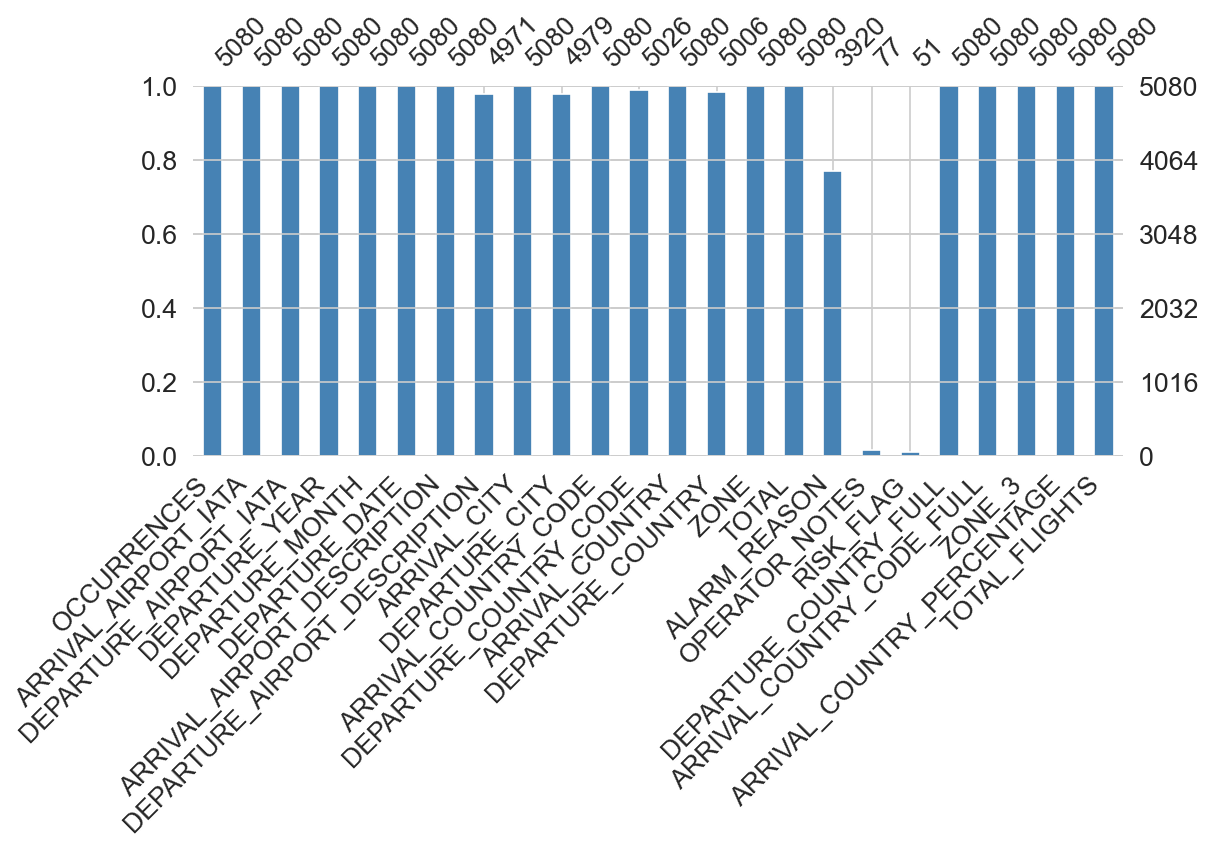

Missingness bar-chart (BEFORE cleaning) — Travelers


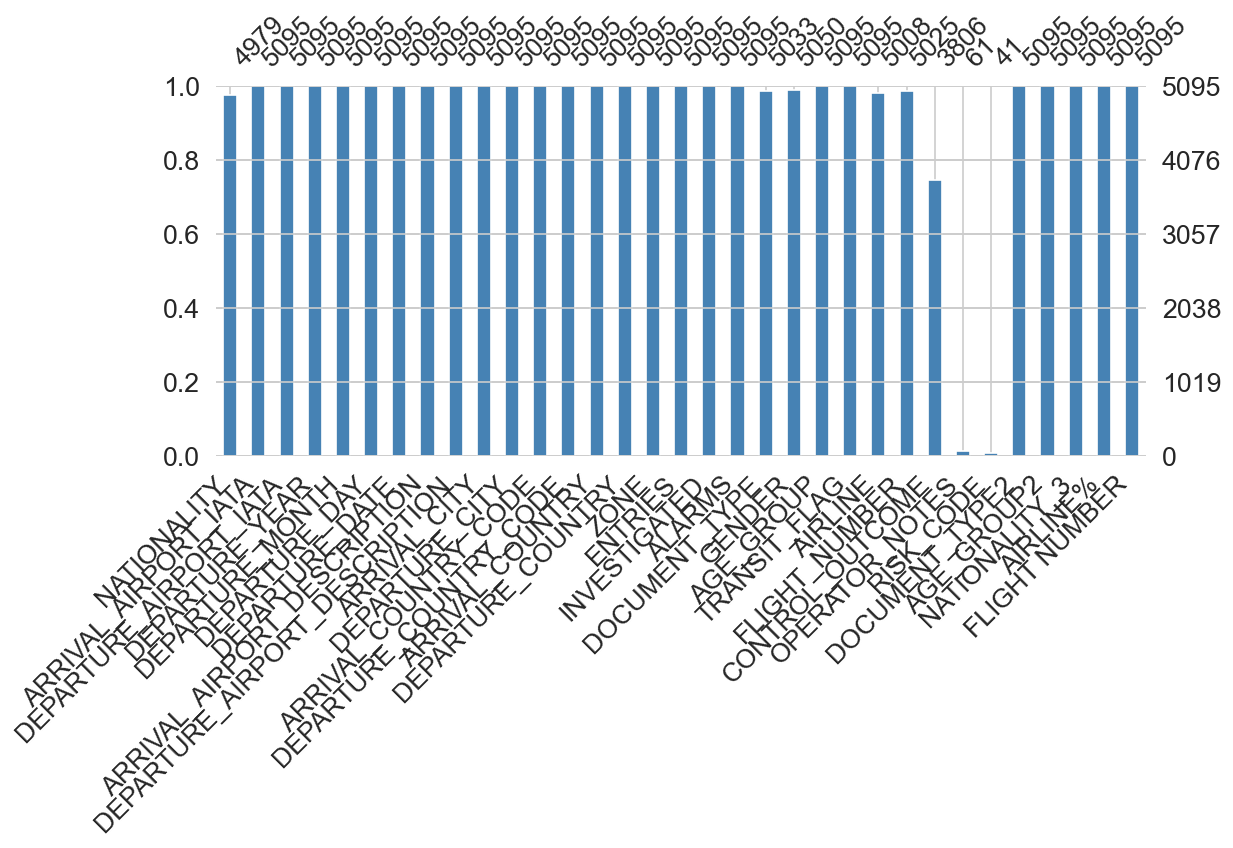

In [936]:
print("Missingness bar-chart (BEFORE cleaning) — Alarms")
msno.bar(df_alarms, figsize=(10, 4), color=STEEL)
plt.show()

print("Missingness bar-chart (BEFORE cleaning) — Travelers")
msno.bar(df_travelers, figsize=(10, 4), color=STEEL)
plt.show()

# Snapshot raw state so section 2.8 can produce a before/after audit.
raw_missing_alarms    = df_alarms.isnull().sum().copy()
raw_missing_travelers = df_travelers.isnull().sum().copy()
raw_shape_alarms      = df_alarms.shape
raw_shape_travelers   = df_travelers.shape

### 2.1 Missing Value Analysis

The audit reveals that both datasets are largely complete, with missing values concentrated in a small number of columns.

In **TIPOLOGIA_VIAGGIATORE**, the columns with missing values are: NATIONALITY (2.28%), DOCUMENT_TYPE (1.22%), GENDER (0.88%), AIRLINE (1.71%), FLIGHT_NUMBER (1.37%), CONTROL_OUTCOME (25.3%), OPERATOR_NOTES (98.8%), and RISK_CODE (99.2%).

In **ALLARMI**, the columns with missing values are: DEPARTURE_AIRPORT_DESCRIPTION (2.15%), DEPARTURE_CITY (1.99%), DEPARTURE_COUNTRY (1.46%), DEPARTURE_COUNTRY_CODE (1.06%), ALARM_REASON (22.8%), OPERATOR_NOTES (98.5%), and RISK_FLAG (99.0%).

The handling strategy for each of these columns is addressed in the cleaning section that follows.

### 2.2 Categorical-cardinality inspection

We split categorical columns into two buckets: *low-cardinality* (≤ 400 unique values, amenable to visual inspection and rule-based cleanup) and *high-cardinality* (> 400, which will require grouping or encoding). We plot only the first group so the chart stays readable, and print the high-cardinality columns as an early warning. Cardinality > 15 is also flagged in coral as a soft threshold for downstream one-hot encoding.

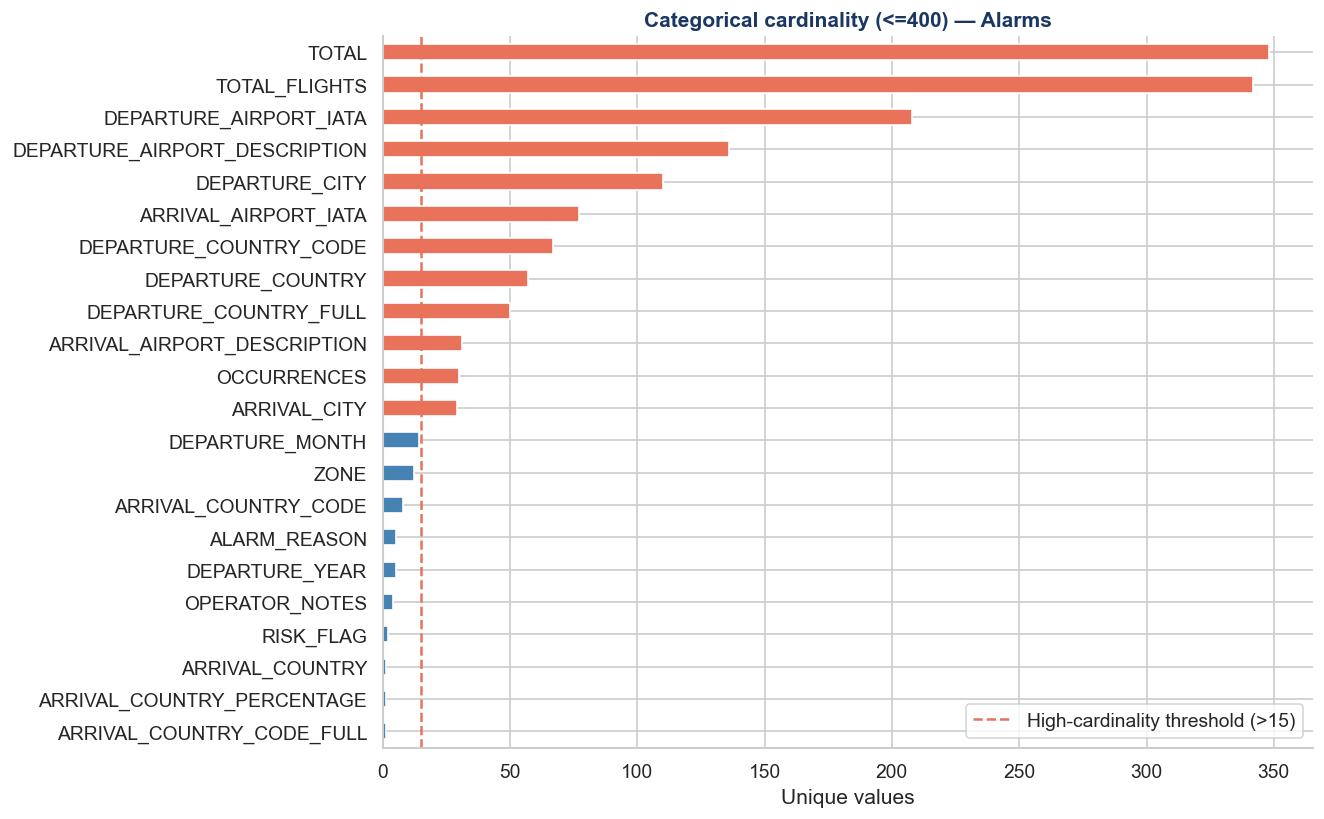

HIGH-CARDINALITY features (excluded from chart):
    'DEPARTURE_DATE': 3810 unique values — needs grouping/target encoding

  Reviewing unique values (Alarms):
  'ARRIVAL_COUNTRY_CODE_FULL' (1 values): ['ITA']

  'ARRIVAL_COUNTRY_PERCENTAGE' (1 values): ['Italia']

  'ARRIVAL_COUNTRY' (1 values): ['Italia']

  'RISK_FLAG' (2 values): ['ALTO', 'MEDIO']

  'OPERATOR_NOTES' (4 values): ['Alert manuale', 'Doppio controllo', 'Passeggero noto', 'Verifica richiesta']

  'DEPARTURE_YEAR' (5 values): ['2023', '2024', '2024.', '24', 'anno 2024']

  'ALARM_REASON' (5 values): ['INTERPOL', 'Manuale', 'NSIS', 'SDI', 'TSC']

  'ARRIVAL_COUNTRY_CODE' (8 values): ['DEU', 'ESP', 'FRA', 'GB', 'GBR', 'IT', 'ITA', 'TUR']

  'ZONE' (12 values): ['-1', '1', '10', '2', '4', '5', '6', '7', '8', '9', '99', '??']

  'DEPARTURE_MONTH' (14 values): ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', 'FEB', 'GEN']

  'ARRIVAL_CITY' (29 values): ['Ancona', 'Bari', 'Bergamo', 'Bologna', 'Bolzano

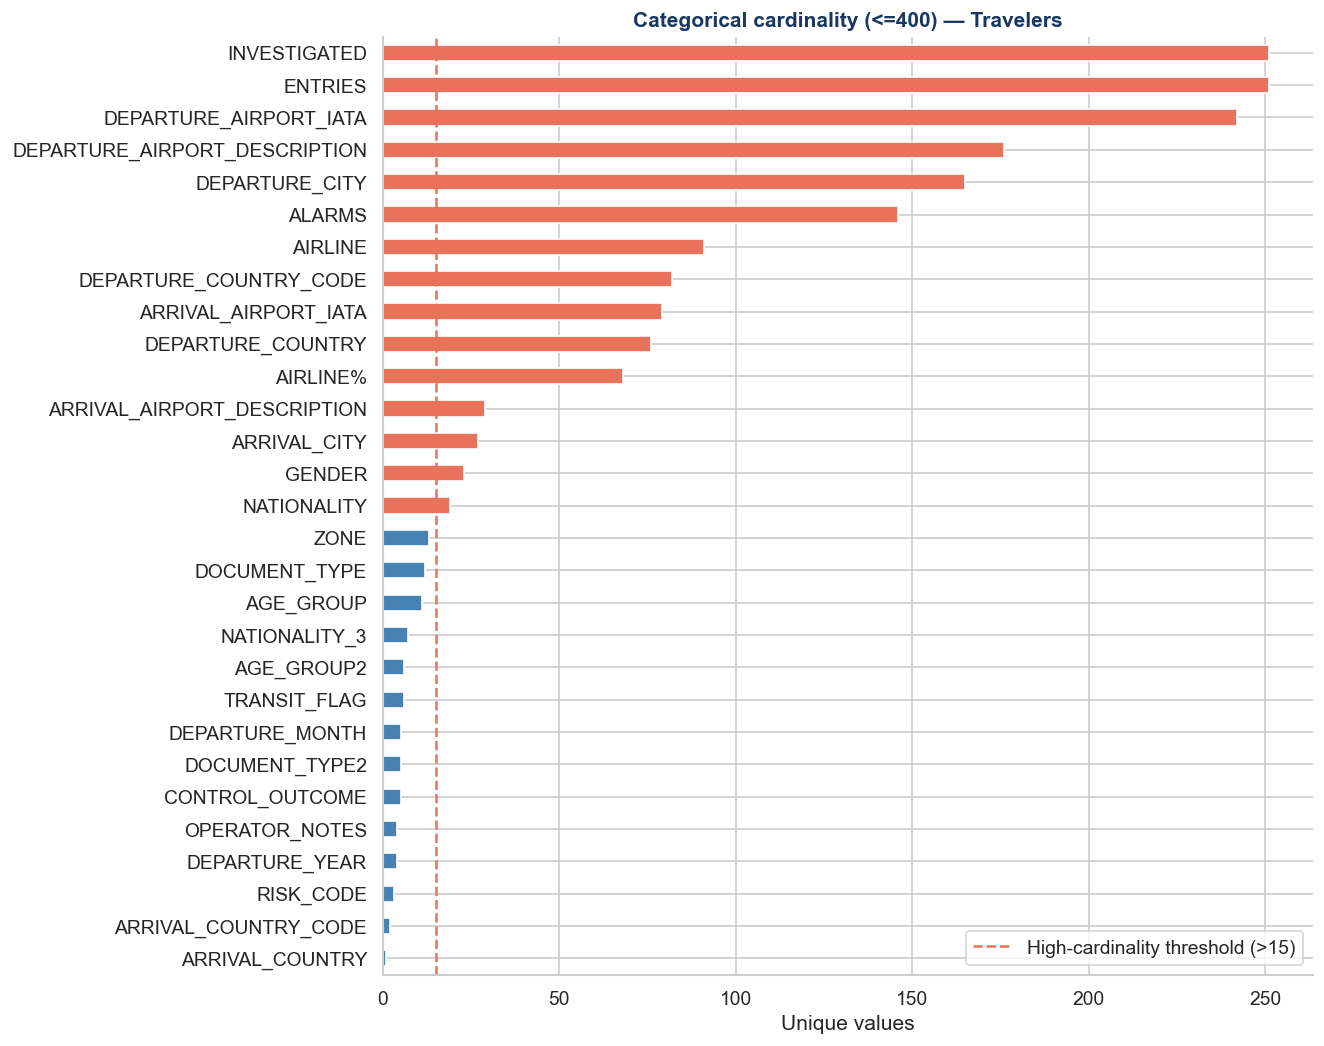

HIGH-CARDINALITY features (excluded from chart):
    'FLIGHT_NUMBER': 701 unique values — needs grouping/target encoding
    'FLIGHT NUMBER': 706 unique values — needs grouping/target encoding
    'DEPARTURE_DATE': 3977 unique values — needs grouping/target encoding

  Reviewing unique values (Travelers):
  'ARRIVAL_COUNTRY' (1 values): ['Italia']

  'ARRIVAL_COUNTRY_CODE' (2 values): ['IT', 'ITA']

  'RISK_CODE' (3 values): ['R1', 'R2', 'R3']

  'DEPARTURE_YEAR' (4 values): ['2023', '2024', '24', 'anno 2024']

  'OPERATOR_NOTES' (4 values): ['Alert manuale', 'Passeggero noto', 'Segnalazione esterna', 'Verifica richiesta']

  'CONTROL_OUTCOME' (5 values): ['FERMATO', 'IN ATTESA', 'OK', 'RESPINTO', 'SEGNALATO']

  'DOCUMENT_TYPE2' (5 values): ["Carta d'identità", 'N.D.', 'Passaporto', 'Permesso di soggiorno', 'Visto']

  'DEPARTURE_MONTH' (5 values): ['01', '02', '12', 'FEB', 'GEN']

  'TRANSIT_FLAG' (6 values): ['Multitratta', 'N/C', 'Singola Tratta', 'TRANSITO', 'Tripla Tratta', 'sing

In [937]:
def inspect_categorical(df, dataset_name):
    """Separate low- and high-cardinality categoricals, plot the former, list the latter."""
    cat_cols = df.select_dtypes(include=["object"]).columns
    if len(cat_cols) == 0:
        print(f"  No categorical columns in {dataset_name}.")
        return

    card = df[cat_cols].nunique().sort_values(ascending=True)
    card_low, card_high = card[card <= 400], card[card > 400]

    if not card_low.empty:
        plt.figure(figsize=(10, max(4, len(card_low) * 0.35)))
        colors = [CORAL if v > 15 else STEEL for v in card_low]
        card_low.plot(kind="barh", color=colors, edgecolor="white")
        plt.axvline(15, color=CORAL, ls="--", lw=1.5,
                    label="High-cardinality threshold (>15)")
        plt.title(f"Categorical cardinality (<=400) — {dataset_name}",
                  fontweight="bold", color=NAVY)
        plt.xlabel("Unique values"); plt.legend(); sns.despine()
        plt.show()

    if not card_high.empty:
        print("HIGH-CARDINALITY features (excluded from chart):")
        for col, val in card_high.items():
            print(f"    '{col}': {val} unique values — needs grouping/target encoding")
        print()

    print(f"  Reviewing unique values ({dataset_name}):")
    for col in card_low.index:
        uv = sorted(df[col].dropna().astype(str).unique())
        print(f"  '{col}' ({len(uv)} values): {uv}\n")

inspect_categorical(df_alarms,    "Alarms")
inspect_categorical(df_travelers, "Travelers")

### 2.2 Cardinality and Data Quality Analysis Result

Reviewing the unique values across both datasets reveals data quality issues well beyond what the missing value analysis alone captured. Columns officially showing 0% missing are in fact dirty: numeric fields like `ENTRIES`, `ALARMS`, and `TOTAL` contain strings such as `"1 pax"`, `"~5"`, `"N.D."`, `"-500"`, and `"0,0"`, making them unusable as-is. Categorical fields like `GENDER`, `NATIONALITY`, `DEPARTURE_AIRPORT_IATA`, and `AIRLINE` suffer from severe inconsistency — mixed case (`"TIA"`, `"Tia"`, `"tia"`), trailing spaces, and multiple representations of unknown values (`"-"`, `"//"`, `"?"`, `"ND"`, `"N.D."`, `"unknown"`). These issues require targeted cleaning before any analytical step, which is addressed in the following section.

### 2.3 Redundant-column resolution (Travelers)

The Travelers dataset ships with duplicated columns that encode the same logical field under different formats (e.g. `document_type` vs `document_type2`, `flight_number` vs `flight number`, `nationality` vs `nationality_3`). For each pair we:

1. quantify how many rows conflict (both non-null but different after normalisation);
2. use the more complete/normalised source column as the primary value, falling back to the legacy column only when the source is missing;
3. drop the redundant source column once merged into the canonical column name.

The canonical column name is kept for downstream compatibility, but conflicting values are resolved in favour of the complete source field rather than accidentally discarding it.

In [938]:
redundant_pairs = [
    ("document_type2",  "document_type"),
    ("age_group2",      "age_group"),
    ("nationality_3",    "nationality"),
    ("airline%",        "airline"),
    ("flight number",  "flight_number"),
]
def _norm(s): return s.astype(str).str.strip().str.upper()

for canonical_col, source_col in redundant_pairs:
    if canonical_col not in df_travelers.columns or source_col not in df_travelers.columns:
        print(f"Column pair missing: '{canonical_col}' & '{source_col}' — skipped")
        continue
    s_canonical, s_source = df_travelers[canonical_col], df_travelers[source_col]
    mask_conflict = (s_canonical.notna() & s_source.notna()
                     & (_norm(s_canonical) != _norm(s_source)))
    n_conflicts   = mask_conflict.sum()
    n_overwritten = (s_source.notna() & (s_canonical.isna() | mask_conflict)).sum()
    conflict_preview = df_travelers.loc[mask_conflict, [canonical_col, source_col]].head(3).copy()
    df_travelers[canonical_col] = s_source.combine_first(s_canonical)
    print(f"'{canonical_col}' <- primary values from '{source_col}'  "
          f"| {n_overwritten} values sourced | {n_conflicts} conflicts resolved from source")
    if n_conflicts > 0:
        display(conflict_preview)

cols_to_drop = [c for _, c in redundant_pairs if c in df_travelers.columns]
df_travelers.drop(columns=cols_to_drop, inplace=True)
print(f"\nDropped redundant columns: {cols_to_drop}")
print(f"Travelers now has {df_travelers.shape[1]} columns (was {raw_shape_travelers[1]}).")

Column pair missing: 'document_type2' & 'document_type' — skipped
Column pair missing: 'age_group2' & 'age_group' — skipped
Column pair missing: 'nationality_3' & 'nationality' — skipped
Column pair missing: 'airline%' & 'airline' — skipped
Column pair missing: 'flight number' & 'flight_number' — skipped

Dropped redundant columns: []
Travelers now has 33 columns (was 33).


### 2.4 Text standardisation & unknown-value unification (Travelers)

We perform three passes over every text column:

1. `strip + UPPERCASE` to collapse trivial casing/whitespace variants;
2. map all unknown tokens (`ND`, `UNKNOWN`, `N/A`, …) to the canonical `'N.D.'` so that they remain *informative categoricals* rather than fake NaNs;
3. convert *junk* tokens (`-`, `//`, `?`, `XX`, …) into proper `NaN` so that downstream imputation logic can see them.

In [939]:
text_cols = df_travelers.select_dtypes(include=["object"]).columns

for col in text_cols:
    df_travelers[col] = df_travelers[col].astype(str).str.strip().str.upper()

unknown_variants = ["ND", "UNKNOWN", "UNKN", "N/A", "N/C"]
df_travelers[text_cols] = df_travelers[text_cols].replace(unknown_variants, "N.D.")

junk_values = ["-", "//", "?", "???", "XX", "ZZ", "NAN", ""]
df_travelers[text_cols] = df_travelers[text_cols].replace(junk_values, np.nan)

print("Text standardised: UPPERCASE, unknown variants -> 'N.D.', junk tokens -> NaN.")
for col in ["departure_airport_iata", "arrival_airport_iata", "gender"]:
    if col in df_travelers.columns:
        print(f"  '{col}' unique: {sorted(df_travelers[col].dropna().unique())}")

Text standardised: UPPERCASE, unknown variants -> 'N.D.', junk tokens -> NaN.


### 2.5 Numeric & domain-specific standardisation (Travelers)

Numeric columns in Travelers arrive mixed with unit suffixes (`PAX`), Italian decimal commas, and illegal sentinels. We handle them in four sub-steps.

**2.5.a** — Recode Italian 2-digit years and month abbreviations; align country codes (`IT` → `ITA`).  
**2.5.b** — `entries`, `investigated`, `alarms`: comma → dot, strip non-numeric, clip to plausible bounds `[0, 1000]`, cast to pandas nullable `Int64` (you cannot have 1.5 passengers).  
**2.5.c** — `zone`: clean to integer in `[0, 10]`.  
**2.5.d** — `gender`: collapse numeric codes (`1`/`2`), Italian (`MASCHIO`/`FEMMINA`), and English variants to canonical `M/F/X`.

In [940]:
# 2.5a — logical mapping
if "arrival_country_code" in df_travelers.columns:
    df_travelers["arrival_country_code"] = (
        df_travelers["arrival_country_code"].replace({"IT": "ITA"})
    )
if "departure_year" in df_travelers.columns:
    df_travelers["departure_year"] = df_travelers["departure_year"].replace(
        {"24": "2024", "ANNO 2024": "2024", "anno 2024": "2024"})

if "departure_month" in df_travelers.columns:
    df_travelers["departure_month"] = df_travelers["departure_month"].replace(
        {"GEN": "01", "FEB": "02"})

# 2.5b — numeric cleaning
quant_cols = ["entries", "investigated", "alarms"]
for col in quant_cols:
    if col not in df_travelers.columns: continue
    before_dtype, before_nulls = df_travelers[col].dtype, df_travelers[col].isna().sum()
    df_travelers[col] = df_travelers[col].astype(str).str.replace(" pax", "")
    df_travelers[col] = df_travelers[col].astype(str).str.replace(",", ".")
    df_travelers[col] = df_travelers[col].str.replace(r"[^\d.\-]", "", regex=True)
    df_travelers[col] = pd.to_numeric(df_travelers[col], errors="coerce")
    df_travelers.loc[(df_travelers[col] < 0) | (df_travelers[col] > 1000), col] = np.nan
    df_travelers[col] = df_travelers[col].astype("Int64")
    print(f"    {col}: dtype {before_dtype}→{df_travelers[col].dtype}"
          f"  |  NaN {before_nulls}→{df_travelers[col].isna().sum()}")

# 2.5c — zone
if "zone" in df_travelers.columns:
    df_travelers["zone"] = df_travelers["zone"].astype(str).str.strip()
    df_travelers["zone"] = df_travelers["zone"].replace(["??", "?", "-"], np.nan)
    df_travelers["zone"] = pd.to_numeric(df_travelers["zone"], errors="coerce")
    df_travelers.loc[(df_travelers["zone"] < 0) | (df_travelers["zone"] > 10), "zone"] = np.nan
    df_travelers["zone"] = df_travelers["zone"].astype("Int64")

# 2.5d — gender
if "gender" in df_travelers.columns:
    gender_map = {"1": "M", "MALE": "M", "MASCHIO": "M", "M": "M",
                  "2": "F", "FEMALE": "F", "FEMMINA": "F", "F": "F",
                  "N/B": "X", "X": "X","N.D.": "X"}
    df_travelers["gender"] = df_travelers["gender"].replace(gender_map)
    print(f"    gender normalised: {sorted(df_travelers['gender'].dropna().unique())}")

### 2.6 ALLARMI — Cleaning Steps

**Redundant columns.** `TOTAL` merged into `TOTAL_FLIGHTS` and dropped. `ZONE_3` merged into `ZONE` and dropped.

**Derived columns removed.** `DEPARTURE_MONTH` and `DEPARTURE_YEAR` dropped — derivable from `DEPARTURE_DATE`.

**Text standardisation.** UPPERCASE for codes and identifiers, Title Case for city/country descriptors. Unknown tokens (`ND`, `?`, `-`, `//`, `unknown`) replaced with NaN. Free-text columns (`ALARM_REASON`, `OPERATOR_NOTES`) filled with explicit placeholders instead of NaN.

**RISK_FLAG.** Italian labels translated to English (`ALTO` → `HIGH RISK`, `MEDIO` → `MEDIUM RISK`). NaN filled with `LOW RISK`.

**Country enrichment.** `DEPARTURE_COUNTRY_FULL` (0 nulls) used to derive missing `DEPARTURE_COUNTRY_CODE` via `pycountry` ISO alpha-3 mapping — nulls reduced from 102 to 3.

**City and airport.** Remaining gaps filled from IATA mapping dictionary — 4 city nulls and 1 airport null remaining.

**Date parsing.** Six mixed formats detected and normalised to ISO 8601. Italian month abbreviations (`GEN`, `FEB`) translated before parsing.

Cleaned dataset saved to `io/ALARMS_CLEANED.csv`.

In [ ]:
# Dropping departure month and year as they can be derived from departure date
df_alarms.drop(columns=["DEPARTURE_MONTH", "DEPARTURE_YEAR"], inplace=True, errors="ignore")

# Occurrences cleaning
df_alarms['OCCURRENCES'] = df_alarms['OCCURRENCES'].str.lower().str.strip().map(occurrences_map)
print(f"\nDistribution:")
print(df_alarms["OCCURRENCES"].value_counts(dropna=False).to_string())

# Remapping Arrival/Departure Airport IATA codes to uppercase and stripping whitespace
df_alarms['ARRIVAL_AIRPORT_IATA'] = df_alarms['ARRIVAL_AIRPORT_IATA'].astype(str).str.strip().str.upper()
df_alarms['DEPARTURE_AIRPORT_IATA'] = df_alarms['DEPARTURE_AIRPORT_IATA'].astype(str).str.strip().str.upper()

# Since all the flights arrive in Italy, we can safely drop redundant country columns and standardise the rest to uppercase.
df_alarms.drop(columns=["ARRIVAL_COUNTRY_CODE", "ARRIVAL_COUNTRY_CODE_PERCENTAGE"], inplace=True, errors="ignore")

# Fix the Zone column by putting -1 99 and ?? to NaN, and converting to numeric. Then combine with ZONE_3 to fill any remaining missing values, before dropping ZONE_3.
if "ZONE" in df_alarms.columns:
    df_alarms["ZONE"] = df_alarms["ZONE"].replace(["-1", "99", "??"], np.nan)
    df_alarms["ZONE"] = pd.to_numeric(df_alarms["ZONE"], errors="coerce")
    df_alarms.loc[(df_alarms["ZONE"] < 0) | (df_alarms["ZONE"] > 10), "ZONE"] = np.nan
    df_alarms["ZONE"] = df_alarms["ZONE"].astype("Int64")
    df_alarms["ZONE"] = df_alarms["ZONE"].combine_first(df_alarms["ZONE_3"])    
    df_alarms.drop(columns=["ZONE_3"], inplace=True, errors="ignore")
if "ZONE" in df_alarms.columns:
    print(f"\nZONE distribution after cleaning:")
    print(df_alarms["ZONE"].value_counts(dropna=False).to_string())

# Alarm reason and operator notes standardisation: uppercase and stripping whitespace. Then fillna with placeholder and print unique values to check for consistency.
if "ALARM_REASON" in df_alarms.columns and "OPERATOR_NOTES" in df_alarms.columns:
    df_alarms["ALARM_REASON"].replace(np.nan, "NO REASON PROVIDED", inplace=True)
    df_alarms["OPERATOR_NOTES"].replace(np.nan, "NO MANUAL NOTES", inplace=True)
    df_alarms["ALARM_REASON"] = df_alarms["ALARM_REASON"].astype(str).str.strip().str.upper()
    df_alarms["OPERATOR_NOTES"] = df_alarms["OPERATOR_NOTES"].astype(str).str.strip().str.upper()
    print(f"\nALARM_REASON unique values after standardisation: {sorted(df_alarms['ALARM_REASON'].unique())}")
    print(f"\nOPERATOR_NOTES unique values after standardisation: {sorted(df_alarms['OPERATOR_NOTES'].unique())}")

# Risk flag translating and fill low values with 'LOW RISK'
if "RISK_FLAG" in df_alarms.columns:
    risk_map = {"ALTO": "HIGH RISK", "MEDIO": "MEDIUM RISK"}
    df_alarms["RISK_FLAG"] = df_alarms["RISK_FLAG"].replace(risk_map)
    df_alarms["RISK_FLAG"] = df_alarms["RISK_FLAG"].fillna("LOW RISK")
    print(f"\nRISK_FLAG distribution after remapping and filling:\n{df_alarms['RISK_FLAG'].value_counts(dropna=False).to_string()}")

# Cleaning Departure Columns using IATA mapping and pycountry for country codes, then dropping redundant columns after imputation.
departure_country_cols = ["DEPARTURE_COUNTRY_CODE", "DEPARTURE_COUNTRY", "DEPARTURE_COUNTRY_FULL"]
dep_city_airport_cols = ["DEPARTURE_CITY", "DEPARTURE_AIRPORT_DESCRIPTION"]
departure_cols = departure_country_cols + dep_city_airport_cols

PLACEHOLDER_NULL = {'n.d.', '?', '', '//', '-', 'unknown', 'nd', 'n/a', 'null', 'anu', 'none'}
# replace known placeholders with NaN
for col in departure_cols:
    if col in df_alarms.columns:
        s = df_alarms[col].astype(str).str.strip()
        df_alarms[col] = s.where(~s.str.lower().isin(PLACEHOLDER_NULL), np.nan)

# Title case solo su city/airport
for col in dep_city_airport_cols:
    if col in df_alarms.columns:
        df_alarms[col] = df_alarms[col].str.title()

# check how many non-null values we have in each departure column to decide which one(s) to use for imputation
print("\nNull counts in departure-related columns:")
for col in departure_cols:
    if col in df_alarms.columns:
        print(f"  {col}: {df_alarms[col].isna().sum()} nulls out of {len(df_alarms)} rows")

# we fill the country code nan with the country name mapped to alpha-3, and then use the most complete country column to fill the others.
if "DEPARTURE_COUNTRY_FULL" in df_alarms.columns and "DEPARTURE_COUNTRY_CODE" in df_alarms.columns:
    derived_codes = (df_alarms["DEPARTURE_COUNTRY_FULL"].astype("string").str.strip().map(it_to_alpha3))
    before = df_alarms["DEPARTURE_COUNTRY_CODE"].isna().sum()
    df_alarms["DEPARTURE_COUNTRY_CODE"] = df_alarms["DEPARTURE_COUNTRY_CODE"].fillna(derived_codes)
    after = df_alarms["DEPARTURE_COUNTRY_CODE"].isna().sum()
    print(f"\nDEPARTURE_COUNTRY_CODE: NaN {before}→{after} (derived from DEPARTURE_COUNTRY_FULL)")

# We keep the most complete column as the primary source for imputation, and drop the others after.
primary_departure_col = max(departure_country_cols, key=lambda c: df_alarms[c].notna().sum() if c in df_alarms.columns else -1)
print(f"Using '{primary_departure_col}' as primary source for departure country imputation.")
# Drop the other departure country column
df_alarms.drop(columns=["DEPARTURE_COUNTRY"], inplace=True)

# Cleaning City and Airport using IATA mapping
iata = df_alarms['DEPARTURE_AIRPORT_IATA'].astype(str).str.upper().str.strip()

df_alarms['DEPARTURE_CITY'] = (
    df_alarms['DEPARTURE_CITY']
    .replace(city_mapping)
    .fillna(iata.map({k: v['city'] for k, v in iata_mapping.items()}))
)
df_alarms['DEPARTURE_AIRPORT_DESCRIPTION'] = (
    df_alarms['DEPARTURE_AIRPORT_DESCRIPTION']
    .replace({v['airport']: v['city'] for v in iata_mapping.values()})
    .fillna(iata.map({k: v['airport'] for k, v in iata_mapping.items()}))
)
print(f"\nCity null:     {df_alarms['DEPARTURE_CITY'].isna().sum()}")
print(f"Airport null: {df_alarms['DEPARTURE_AIRPORT_DESCRIPTION'].isna().sum()}\n")

# Total and Total_flights: since Total has a lot of junk values and Total_Flights is cleaner, we will keep Total_Flights as the main column and drop Total.
def clean_count(series, max_valid=1000):
    s = (series.astype(str)
                .str.strip()
                .str.replace(r'\s*voli\s*$', '', regex=True)  
                .str.lstrip('~'))                             
    s = pd.to_numeric(s, errors='coerce')                      
    s = s.where((s >= 0) & (s <= max_valid))                  
    return s.fillna(0).round().astype(int)

df_alarms['TOTAL_FLIGHTS'] = clean_count(df_alarms['TOTAL_FLIGHTS'])
df_alarms['TOTAL']         = clean_count(df_alarms['TOTAL'])
print(df_alarms[['TOTAL_FLIGHTS', 'TOTAL']].describe())
df_alarms.drop(columns=['TOTAL'], inplace=True, errors='ignore')

# Save the cleaned datasets
df_alarms.to_csv("io/ALARMS_CLEANED.csv", index=False)


Distribution:
OCCURRENCES
entries                            626
available_inbound_flights          588
viewed_not_investigated_flights    572
generated_alerts                   547
investigated_flights               543
investigated_entries               528
flights_with_alerts                507
entries_with_alerts                468
negative_outcome                   296
closed_alerts                      259
relevant_alerts                    112
other                               16
missing_update                       8
open_alerts                          7
NaN                                  3

ZONE distribution after cleaning:
ZONE
2     1841
5     1474
8      580
4      568
6      213
1      180
7      144
9       79
10       1

ALARM_REASON unique values after standardisation: ['INTERPOL', 'MANUALE', 'NO REASON PROVIDED', 'NSIS', 'SDI', 'TSC']

OPERATOR_NOTES unique values after standardisation: ['ALERT MANUALE', 'DOPPIO CONTROLLO', 'NO MANUAL NOTES', 'PASSEGGERO NOTO', '

### 2.10 Post-cleaning missing-value audit

A side-by-side table compares *per column* the number of missing values before and after section 2.3 – section 2.7. We only show rows where the count actually changed — the rest is untouched. The follow-up `missingno` bar-charts in green confirm visually that the key fields are now dense.


ALARMS  (shape: (5080, 24) -> (5080, 18))


,Missing BEFORE,Missing AFTER
Column,,
ALARM_REASON,1160,0
ARRIVAL_AIRPORT_DESCRIPTION,0,0
ARRIVAL_AIRPORT_IATA,0,0
ARRIVAL_CITY,0,0
ARRIVAL_COUNTRY,0,0
ARRIVAL_COUNTRY_CODE,0,dropped
ARRIVAL_COUNTRY_CODE_FULL,0,0
ARRIVAL_COUNTRY_PERCENTAGE,0,0
DEPARTURE_AIRPORT_DESCRIPTION,109,1



TRAVELERS  (shape: (5095, 33) -> (5095, 33))


,Missing BEFORE,Missing AFTER
Column,,
AGE_GROUP,0,0
AGE_GROUP2,0,0
AIRLINE,87,192
AIRLINE%,0,0
ALARMS,0,33
ARRIVAL_AIRPORT_DESCRIPTION,0,0
ARRIVAL_AIRPORT_IATA,0,0
ARRIVAL_CITY,0,0
ARRIVAL_COUNTRY,0,0


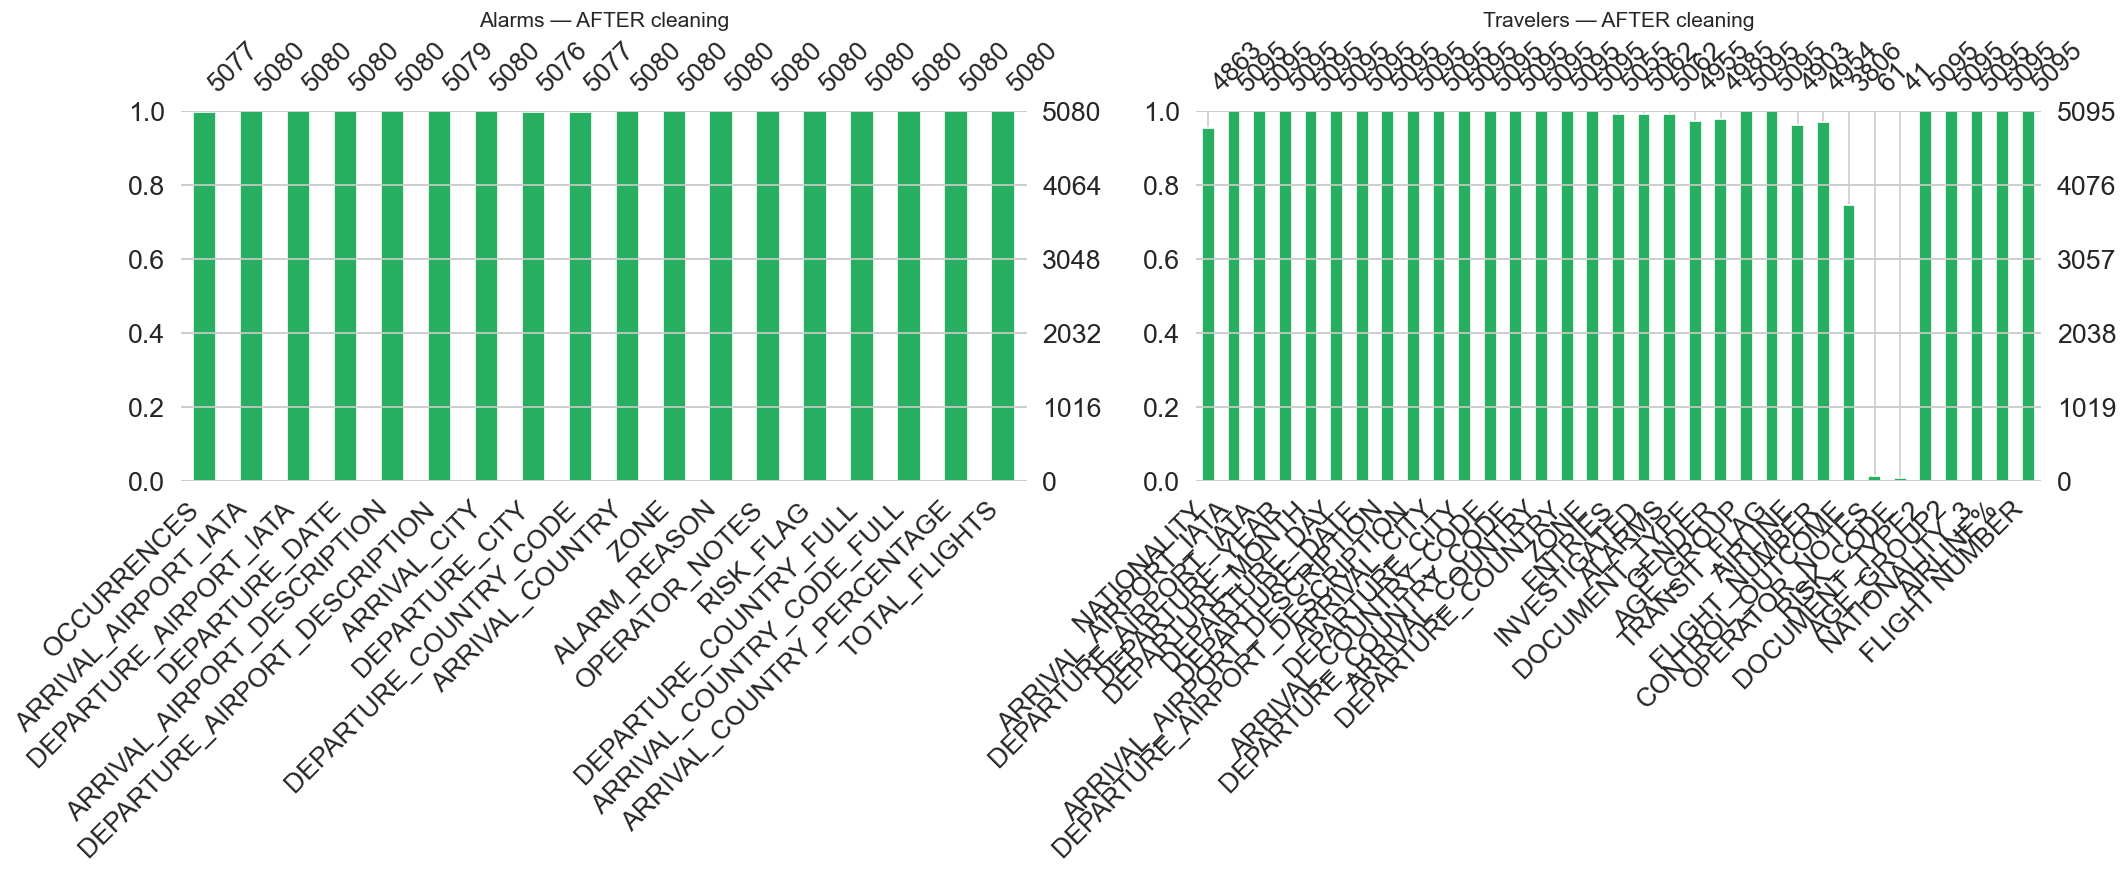

In [942]:
def missing_comparison(df_now, raw_missing, dataset_name, raw_shape):
    """Compare per-column missing-value counts before and after the cleaning pipeline."""
    now = df_now.isnull().sum()
    col_map = {c.upper(): c for c in df_now.columns}
    raw_missing = raw_missing.copy()
    raw_missing.index = [col_map.get(c.upper(), c) for c in raw_missing.index]
    all_cols = sorted(set(raw_missing.index) | set(now.index))
    rows = [{"Column": c,
             "Missing BEFORE": raw_missing.get(c, "—"),
             "Missing AFTER":  now.get(c, "dropped")} for c in all_cols]
    report = pd.DataFrame(rows).set_index("Column")
    print(f"\n{dataset_name}  (shape: {raw_shape} -> {df_now.shape})")
    display(report)

missing_comparison(df_alarms,    raw_missing_alarms,    "ALARMS",    raw_shape_alarms)
missing_comparison(df_travelers, raw_missing_travelers, "TRAVELERS", raw_shape_travelers)

# Missingness bar-charts side by side (AFTER cleaning)
fig, axes = plt.subplots(1, 2, figsize=(20, 4))
msno.bar(df_alarms,    ax=axes[0], color=GREEN)
axes[0].set_title("Alarms — AFTER cleaning")
msno.bar(df_travelers, ax=axes[1], color=GREEN)
axes[1].set_title("Travelers — AFTER cleaning")
plt.tight_layout()
plt.show()

### 2.11 Final schema verification

We print the final shape, column list, and dtype counts for both datasets — the schema contract on which the feature-engineering block will depend. The cleaned DataFrames remain in memory (`df_alarms`, `df_travelers`); no disk persistence is required since the notebook runs end-to-end in a single session.


In [943]:
print(f"ALARMS    — {df_alarms.shape[0]:,} rows x {df_alarms.shape[1]} cols")
print(f"Columns: {list(df_alarms.columns)}")
print(f"Dtypes:\n{df_alarms.dtypes.value_counts().to_string()}\n")

print(f"TRAVELERS — {df_travelers.shape[0]:,} rows x {df_travelers.shape[1]} cols")
print(f"Columns: {list(df_travelers.columns)}")
print(f"Dtypes:\n{df_travelers.dtypes.value_counts().to_string()}")


ALARMS    — 5,080 rows x 18 cols
Columns: ['OCCURRENCES', 'ARRIVAL_AIRPORT_IATA', 'DEPARTURE_AIRPORT_IATA', 'DEPARTURE_DATE', 'ARRIVAL_AIRPORT_DESCRIPTION', 'DEPARTURE_AIRPORT_DESCRIPTION', 'ARRIVAL_CITY', 'DEPARTURE_CITY', 'DEPARTURE_COUNTRY_CODE', 'ARRIVAL_COUNTRY', 'ZONE', 'ALARM_REASON', 'OPERATOR_NOTES', 'RISK_FLAG', 'DEPARTURE_COUNTRY_FULL', 'ARRIVAL_COUNTRY_CODE_FULL', 'ARRIVAL_COUNTRY_PERCENTAGE', 'TOTAL_FLIGHTS']
Dtypes:
object    16
Int64      1
int64      1

TRAVELERS — 5,095 rows x 33 cols
Columns: ['NATIONALITY', 'ARRIVAL_AIRPORT_IATA', 'DEPARTURE_AIRPORT_IATA', 'DEPARTURE_YEAR', 'DEPARTURE_MONTH', 'DEPARTURE_DAY', 'DEPARTURE_DATE', 'ARRIVAL_AIRPORT_DESCRIPTION', 'DEPARTURE_AIRPORT_DESCRIPTION', 'ARRIVAL_CITY', 'DEPARTURE_CITY', 'ARRIVAL_COUNTRY_CODE', 'DEPARTURE_COUNTRY_CODE', 'ARRIVAL_COUNTRY', 'DEPARTURE_COUNTRY', 'ZONE', 'ENTRIES', 'INVESTIGATED', 'ALARMS', 'DOCUMENT_TYPE', 'GENDER', 'AGE_GROUP', 'TRANSIT_FLAG', 'AIRLINE', 'FLIGHT_NUMBER', 'CONTROL_OUTCOME', 'OPERATOR_

## 3. Univariate Analysis

### 3.1 Numerical distributions

For every numeric column we print the descriptive statistics (mean, std, quantiles) and draw a histogram. We use this to detect skewness (common for count data), bounded ranges (e.g. `zone`) and suspicious spikes at the extremes that may indicate residual data-quality issues.


  Descriptive statistics — Alarms:


,count,mean,std,min,25%,50%,75%,max
ZONE,5080.00,4.16,2.16,1.00,2.00,4.00,5.00,10.00
TOTAL_FLIGHTS,5080.00,40.11,74.75,0.00,1.00,1.00,27.00,544.00


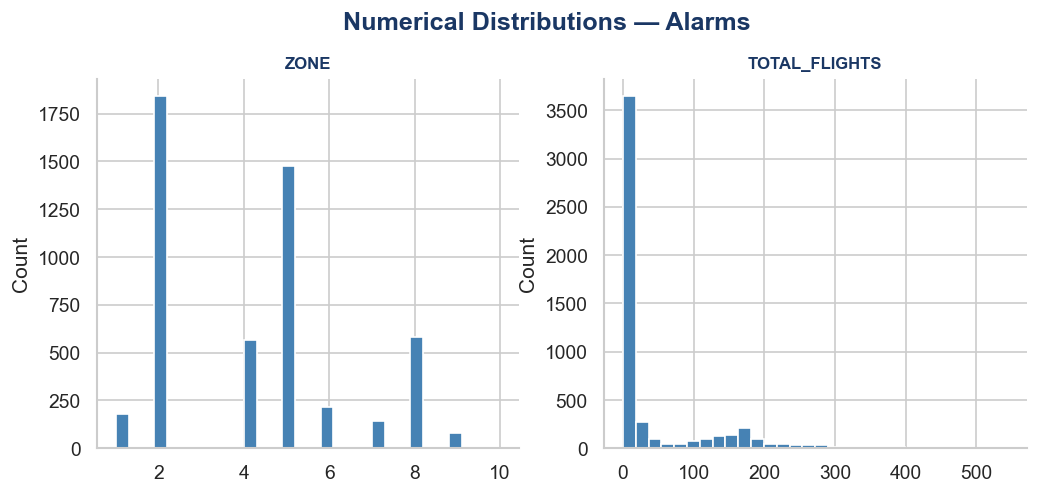


  Descriptive statistics — Travelers:


,count,mean,std,min,25%,50%,75%,max
DEPARTURE_DAY,5095.00,15.09,8.63,1.00,8.00,15.00,23.00,31.00


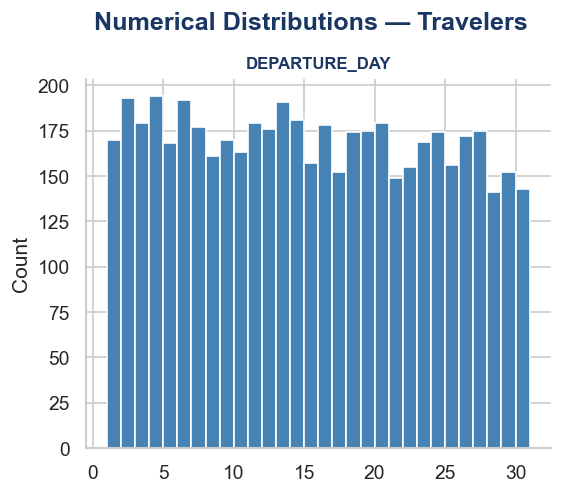

In [944]:
def plot_numeric_distributions(df, dataset_name):
    """Plot histograms and descriptive statistics for every numeric column."""
    num_cols = df.select_dtypes(include="number").columns.tolist()
    if not num_cols:
        print(f"  No numeric columns in {dataset_name}."); return
    print(f"\n  Descriptive statistics — {dataset_name}:")
    display(df[num_cols].describe().T)
    n = len(num_cols); ncols = min(3, n); nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).flatten() if n > 1 else [axes]
    for i, col in enumerate(num_cols):
        ax = axes[i]
        df[col].dropna().hist(bins=30, ax=ax, color=STEEL, edgecolor="white")
        ax.set_title(col, fontsize=10, color=NAVY, fontweight="bold")
        ax.set_ylabel("Count"); sns.despine(ax=ax)
    for j in range(i + 1, len(axes)): axes[j].set_visible(False)
    plt.suptitle(f"Numerical Distributions — {dataset_name}",
                 fontweight="bold", color=NAVY, y=1.02)
    plt.show()

plot_numeric_distributions(df_alarms,    "Alarms")
plot_numeric_distributions(df_travelers, "Travelers")


### 3.2 Categorical frequency analysis

Bar charts of the top-10 values for the business-relevant categoricals. For Alarms these are `ALARM_REASON`, `RISK_FLAG`, `ARRIVAL_COUNTRY_CODE`; for Travelers they are `gender`, `document_type`, `transit_flag`, `age_group`, `control_outcome`. We use `top_n=10` to avoid drawing uninformative long tails.

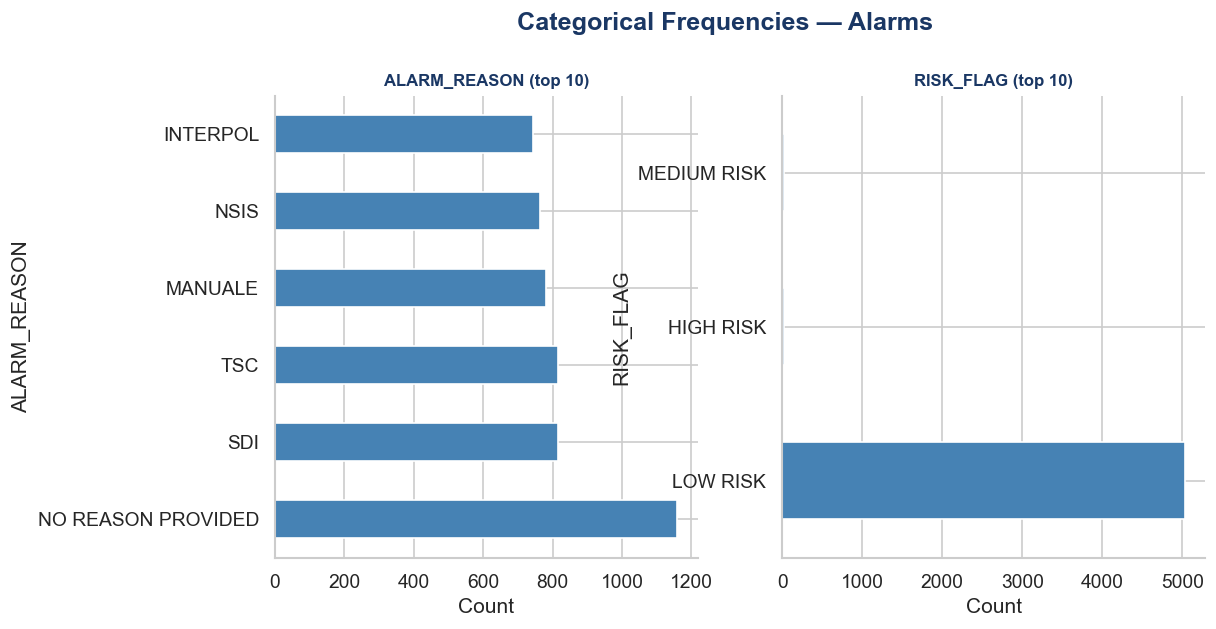

In [945]:
def plot_categorical_freq(df, cols, dataset_name, top_n=10):
    """Plot horizontal bar charts of the top-N values for each requested categorical column."""
    cols = [c for c in cols if c in df.columns]
    if not cols: return
    n = len(cols); fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1: axes = [axes]
    for ax, col in zip(axes, cols):
        df[col].value_counts().head(top_n).plot(kind="barh", ax=ax, color=STEEL, edgecolor="white")
        ax.set_title(f"{col} (top {top_n})", fontsize=10, fontweight="bold", color=NAVY)
        ax.set_xlabel("Count"); sns.despine(ax=ax)
    plt.suptitle(f"Categorical Frequencies — {dataset_name}", fontweight="bold", color=NAVY, y=1.02)
    plt.show()

plot_categorical_freq(df_alarms,    ["ALARM_REASON", "RISK_FLAG", "ARRIVAL_COUNTRY_CODE"], "Alarms")
plot_categorical_freq(df_travelers, ["gender", "document_type", "transit_flag",
                                     "age_group", "control_outcome"], "Travelers")

### 3.3 Temporal distribution

We aggregate records at the *month* granularity and plot them as bar charts. The shape of these two time-series tells us (a) whether the coverage period of the two datasets aligns and (b) whether there are any obvious reporting gaps that could bias time-series feature engineering later on.

AttributeError: Can only use .dt accessor with datetimelike values

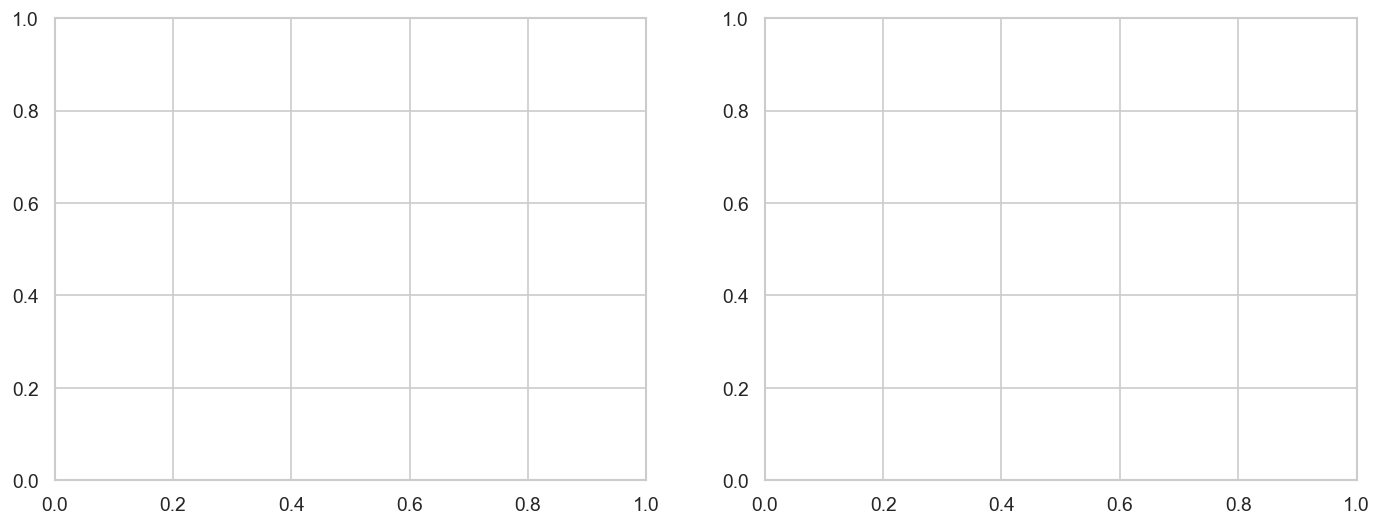

In [946]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (df_tmp, name) in zip(axes, [(df_alarms, "Alarms"), (df_travelers, "Travelers")]):
    date_col = "DEPARTURE_DATE" if "DEPARTURE_DATE" in df_tmp.columns else "departure_date"
    if date_col not in df_tmp.columns: continue
    monthly = df_tmp[date_col].dropna().dt.to_period("M").value_counts().sort_index()
    monthly.plot(kind="bar", ax=ax, color=STEEL, edgecolor="white")
    ax.set_title(f"Records per Month — {name}", fontweight="bold", color=NAVY)
    ax.set_xlabel("Month"); ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45); sns.despine(ax=ax)


## 4. Bivariate Analysis

### 4.1 Entries vs Alarms

The Pearson correlation between passenger `entries` and `alarms` quantifies whether alarm volume simply tracks traffic (a high correlation would mean "bigger airports trigger more alarms just because they have more flow") or whether some routes/days show *excess* alarms given traffic. The latter is exactly the signal we will want to isolate during anomaly detection.

  Pearson r(entries, alarms) = 0.580


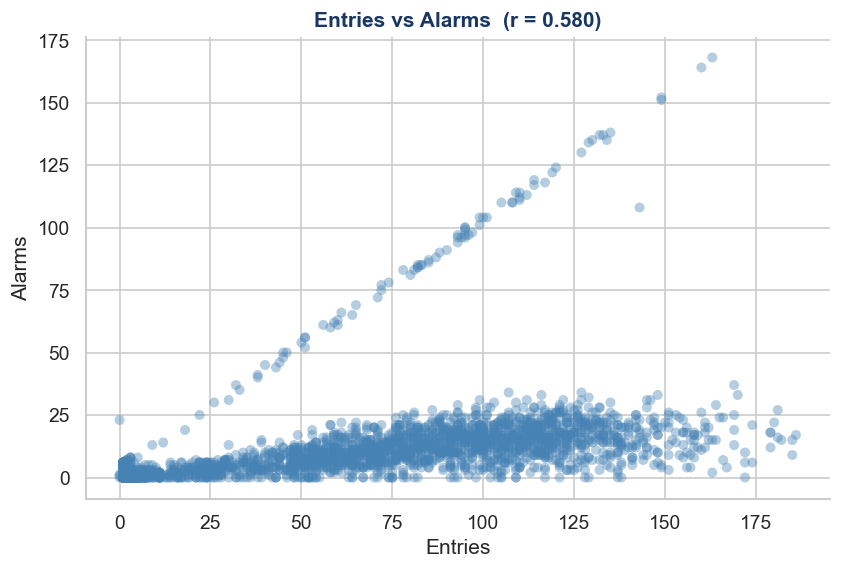

In [ ]:
if {"entries", "alarms"}.issubset(df_travelers.columns):
    corr = df_travelers[["entries", "alarms"]].corr().iloc[0, 1]
    print(f"  Pearson r(entries, alarms) = {corr:.3f}")
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df_travelers, x="entries", y="alarms", alpha=0.4, color=STEEL, edgecolor="none")
    plt.title(f"Entries vs Alarms  (r = {corr:.3f})", fontweight="bold", color=NAVY)
    plt.xlabel("Entries"); plt.ylabel("Alarms"); sns.despine()
else:
    print("'entries' or 'alarms' column not found — skipping.")

### 4.2 Alarm Reason × Zone heatmap

A crosstab of `ALARM_REASON` against `ZONE_3` tells us which types of alarms concentrate in which geographic risk zones. Reading the heatmap row-wise highlights alarm categories that cluster in a single zone (narrow operational footprint); column-wise, it shows zones that receive a disproportionate share of a particular alarm type — both patterns are candidate priors for the anomaly detector.

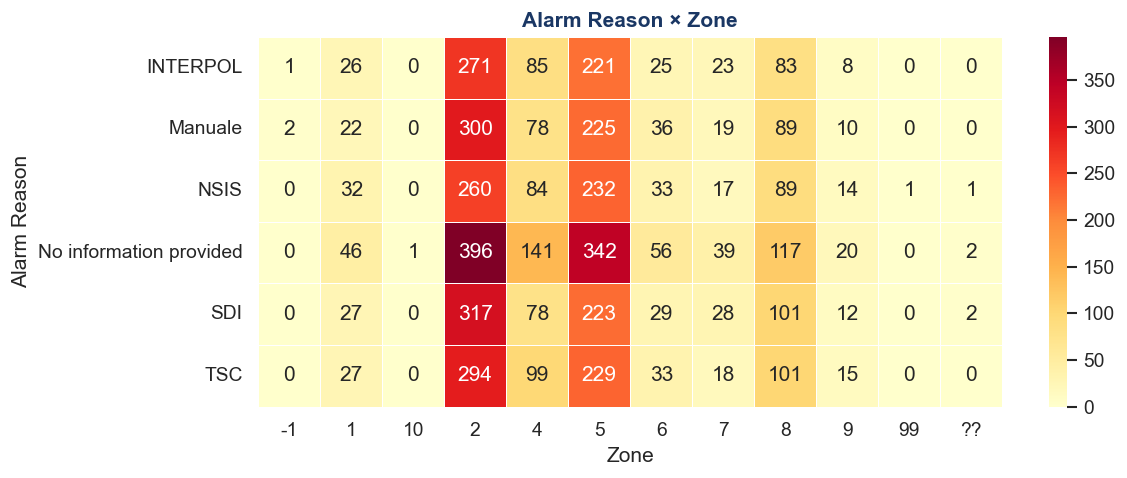

In [ ]:
zone_col   = "ZONE_3" if "ZONE_3" in df_alarms.columns else "ZONE"
reason_col = "ALARM_REASON" if "ALARM_REASON" in df_alarms.columns else None

if reason_col and zone_col in df_alarms.columns:
    ct = pd.crosstab(df_alarms[reason_col], df_alarms[zone_col])
    plt.figure(figsize=(10, max(4, len(ct) * 0.5)))
    sns.heatmap(ct, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5)
    plt.title("Alarm Reason × Zone", fontweight="bold", color=NAVY)
    plt.ylabel("Alarm Reason"); plt.xlabel("Zone")
else:
    print("Required columns not available — skipping.")

### 4.3 Top routes by volume

We rank all (departure IATA → arrival IATA) pairs by alarm count and visualise the top 15. These are the routes where the data density is highest, so baseline statistics computed over them will be the most reliable; smaller routes will need regularisation or pooling.

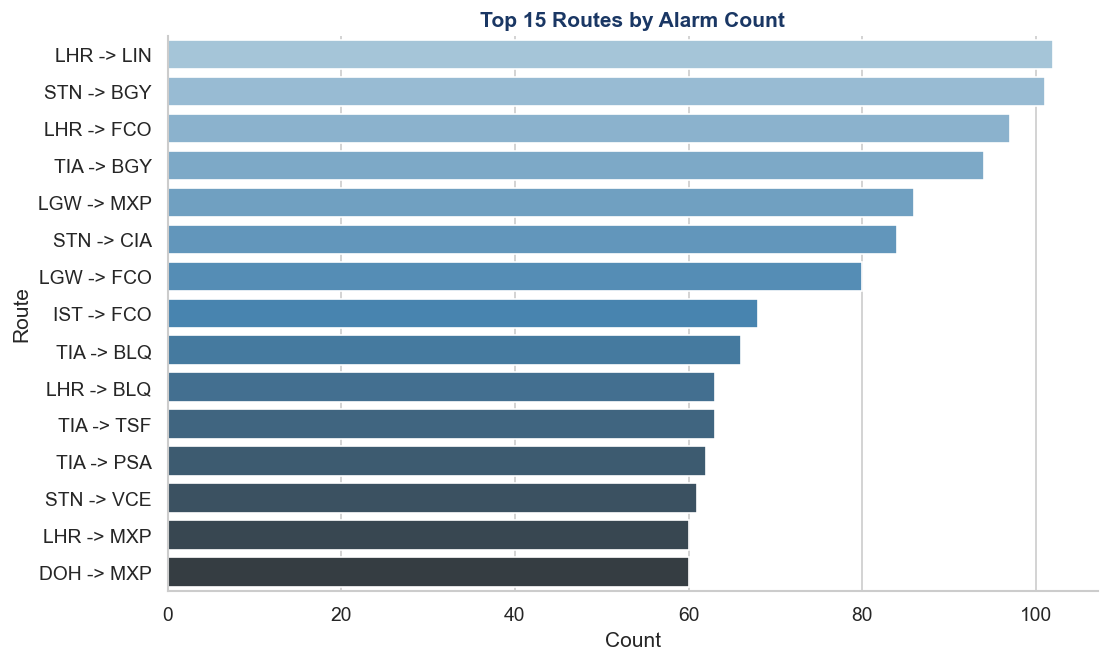

,route,count
183,LHR -> LIN,102
294,STN -> BGY,101
182,LHR -> FCO,97
324,TIA -> BGY,94
175,LGW -> MXP,86
298,STN -> CIA,84
172,LGW -> FCO,80
142,IST -> FCO,68
325,TIA -> BLQ,66
181,LHR -> BLQ,63


In [ ]:
dep_col = "DEPARTURE_AIRPORT_IATA" if "DEPARTURE_AIRPORT_IATA" in df_alarms.columns else None
arr_col = "ARRIVAL_AIRPORT_IATA"   if "ARRIVAL_AIRPORT_IATA"   in df_alarms.columns else None

if dep_col and arr_col:
    routes = (df_alarms.groupby([dep_col, arr_col]).size()
              .reset_index(name="count")
              .sort_values("count", ascending=False)
              .head(15))
    routes["route"] = routes[dep_col] + " -> " + routes[arr_col]
    plt.figure(figsize=(10, 6))
    # Pass `hue` to use a palette safely across seaborn versions (>=0.14).
    sns.barplot(data=routes, y="route", x="count",
                hue="route", palette="Blues_d", legend=False)
    plt.title("Top 15 Routes by Alarm Count", fontweight="bold", color=NAVY)
    plt.xlabel("Count"); plt.ylabel("Route"); sns.despine()
    plt.show()
    display(routes[["route", "count"]])
else:
    print("Airport IATA columns not available — skipping.")


## 5. Multivariate Analysis

### 5.1 Numeric correlation matrix

We plot the lower-triangular Pearson correlation matrix for each dataset. This flags *multi-collinearity* (features that move together and will dominate distance-based methods like LOF if left unscaled) and tells us which raw numerics carry redundant information before we start crafting engineered features.

  Not enough numeric columns in Alarms.


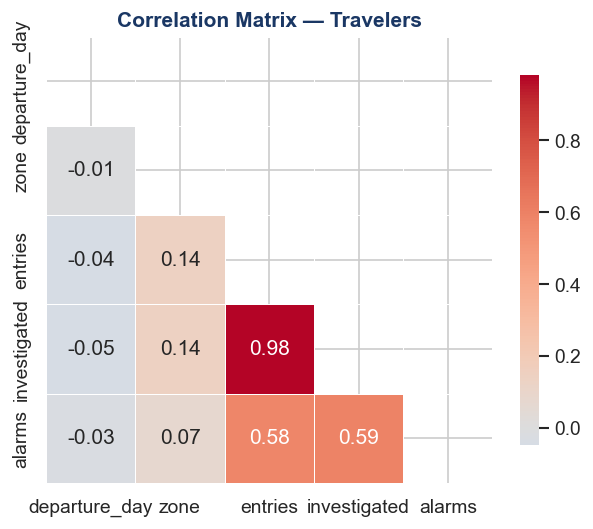

In [ ]:
def plot_corr_matrix(df, dataset_name):
    """Plot the lower-triangular Pearson correlation matrix of the numeric columns."""
    num_cols = df.select_dtypes(include="number").columns.tolist()
    if len(num_cols) < 2:
        print(f"  Not enough numeric columns in {dataset_name}."); return
    corr = df[num_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    plt.figure(figsize=(max(6, len(num_cols)), max(5, len(num_cols) * 0.8)))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
                cmap="coolwarm", center=0, linewidths=0.5, square=True,
                cbar_kws={"shrink": 0.8})
    plt.title(f"Correlation Matrix — {dataset_name}", fontweight="bold", color=NAVY)
    plt.show()

plot_corr_matrix(df_alarms,    "Alarms")
plot_corr_matrix(df_travelers, "Travelers")


### 5.2 Pair plot — Travelers

Pair plot over `entries`, `investigated`, `alarms`, `zone` (sampled to 2 000 points for responsiveness). The off-diagonal panels let us see *joint* structure (e.g. whether alarms grow linearly or sub-linearly with entries), while the KDE diagonals confirm the marginal distributions already seen in section 3.1.

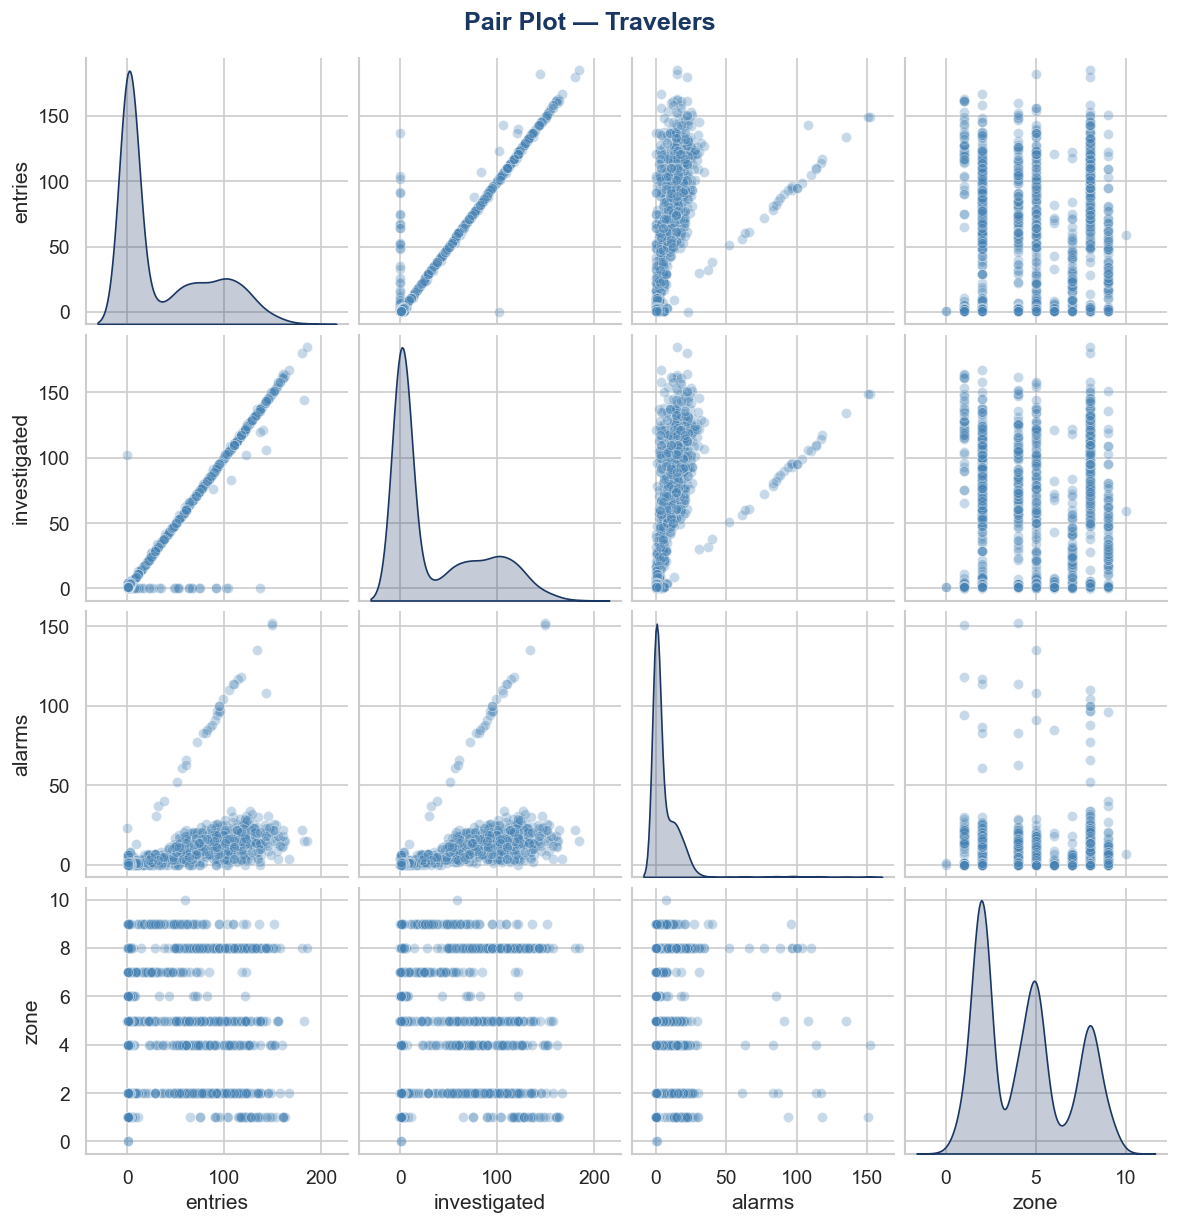

In [ ]:
pair_cols = [c for c in ["entries", "investigated", "alarms", "zone"]
             if c in df_travelers.columns]
if len(pair_cols) >= 2:
    sample = df_travelers[pair_cols].dropna()
    if len(sample) > 2000: sample = sample.sample(2000, random_state=42)
    g = sns.pairplot(sample, diag_kind="kde",
                     plot_kws={"alpha": 0.3, "color": STEEL},
                     diag_kws={"color": NAVY})
    g.figure.suptitle("Pair Plot — Travelers", y=1.02, fontweight="bold", color=NAVY)
else:
    print("Not enough numeric columns for pair plot.")

## 6. Outlier Analysis

### 6.1 IQR-based outlier detection

We apply the standard 1.5·IQR rule to every numeric column and tabulate: quartiles, IQR, lower/upper bounds, number of outliers and their share of the column. The result is *descriptive*, not prescriptive — for right-skewed count distributions like `entries` and `total_flights` a large tail is expected, and we won't remove those observations; instead, the tail itself becomes one of the signals the anomaly detector consumes.

In [ ]:
def iqr_outlier_report(df, dataset_name):
    num_cols = df.select_dtypes(include="number").columns.tolist()
    rows = []
    for col in num_cols:
        s = df[col].dropna()
        if len(s) == 0: continue
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1; lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((s < lower) | (s > upper)).sum()
        rows.append({"Column": col, "Q1": q1, "Q3": q3, "IQR": iqr,
                     "Lower": lower, "Upper": upper, "Outliers": n_out,
                     "Outlier %": round(n_out / len(s) * 100, 2)})
    if not rows:
        print(f"{dataset_name} — IQR Outlier Report: no numeric columns found.")
        return pd.DataFrame()
    report = pd.DataFrame(rows).set_index("Column")
    print(f"{dataset_name} — IQR Outlier Report:")
    display(report); return report

iqr_alarms    = iqr_outlier_report(df_alarms,    "Alarms")
iqr_travelers = iqr_outlier_report(df_travelers, "Travelers")

Alarms — IQR Outlier Report: no numeric columns found.
Travelers — IQR Outlier Report:


,Q1,Q3,IQR,Lower,Upper,Outliers,Outlier %
Column,,,,,,,
departure_day,8.00,23.00,15.00,-14.50,45.50,0,0.00
zone,2.00,7.00,5.00,-5.50,14.50,0,0.00
entries,1.00,76.00,75.00,-111.50,188.50,0,0.00
investigated,1.00,75.00,74.00,-110.00,186.00,0,0.00
alarms,0.00,10.00,10.00,-15.00,25.00,142,2.83


### 6.2 Box plots — key metrics

Visual companion to the IQR table. For each key quantitative column we draw the box plot and highlight fliers in coral. The box summarises the bulk of the distribution; the whiskers show the natural spread; the coral dots are the rows the anomaly detector will later have to classify as *expected-extreme* vs *genuinely-anomalous*.

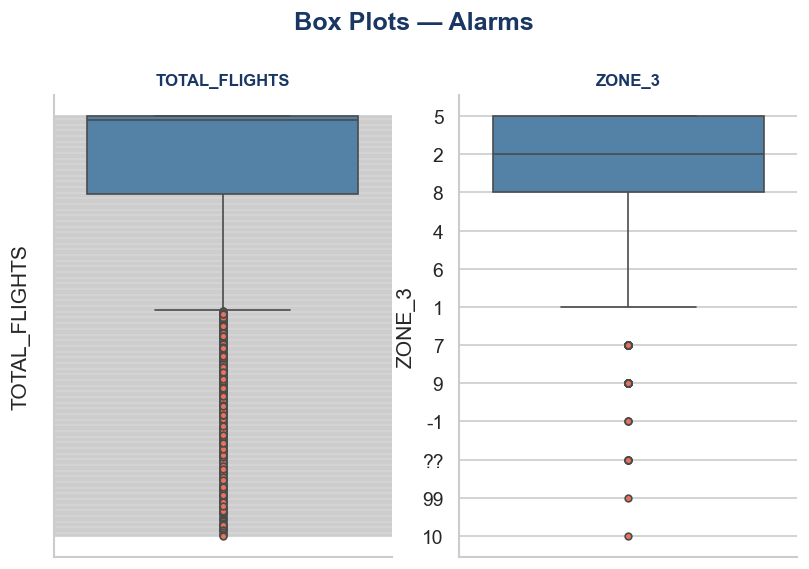

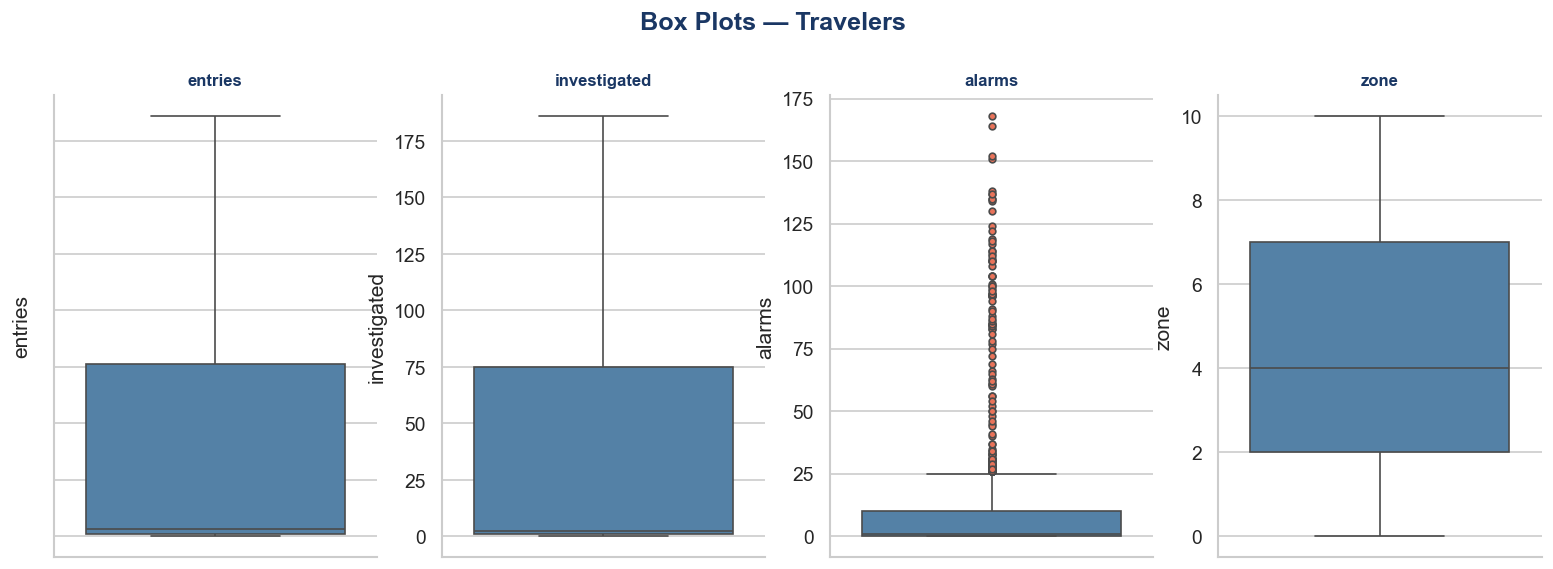

In [ ]:
def plot_boxplots(df, cols, dataset_name):
    """Plot a box plot for each requested column, with fliers highlighted in coral."""
    cols = [c for c in cols if c in df.columns]
    if not cols: return
    n = len(cols); fig, axes = plt.subplots(1, n, figsize=(4 * n, 5))
    if n == 1: axes = [axes]
    for i, (ax, col) in enumerate(zip(axes, cols)):
        sns.boxplot(y=df[col].dropna(), ax=ax, color=STEEL,
                    flierprops={"marker": "o", "markerfacecolor": CORAL, "markersize": 4})
        ax.set_title(col, fontsize=10, fontweight="bold", color=NAVY); sns.despine(ax=ax)
        if i == 0:
            ax.yaxis.set_ticklabels([])
    plt.suptitle(f"Box Plots — {dataset_name}", fontweight="bold", color=NAVY, y=1.02)
    plt.show()

plot_boxplots(df_alarms,    ["TOTAL_FLIGHTS", "ZONE_3"], "Alarms")
plot_boxplots(df_travelers, ["entries", "investigated", "alarms", "zone"], "Travelers")

## 7. Cross-Dataset Coverage

### 7.1 Temporal overlap

To be able to join the two datasets on date, we compute the min/max of `departure_date` in each and report the intersection. If the overlap is empty we must rescope; if it is short, the Feature-Engineering block will need to be careful about time-series windows.

In [ ]:
date_al = "DEPARTURE_DATE" if "DEPARTURE_DATE" in df_alarms.columns else "departure_date"
date_tr = "departure_date"

if date_al in df_alarms.columns and date_tr in df_travelers.columns:
    al_min, al_max = df_alarms[date_al].min(),   df_alarms[date_al].max()
    tr_min, tr_max = df_travelers[date_tr].min(), df_travelers[date_tr].max()
    print(f"  Alarms    : {al_min} → {al_max}")
    print(f"  Travelers : {tr_min} → {tr_max}")
    overlap_start = max(al_min, tr_min); overlap_end = min(al_max, tr_max)
    if overlap_start <= overlap_end:
        print(f"  Overlap : {overlap_start} → {overlap_end}")
    else:
        print("   No temporal overlap between datasets!")

  Alarms    : 2023-12-31 00:00:00 → 2024-02-29 22:20:00
  Travelers : 2023-12-31 19:35:00 → 2024-02-29 21:55:00
  Overlap : 2023-12-31 19:35:00 → 2024-02-29 21:55:00


### 7.2 Airport & route coverage (Jaccard)

Even when the dates overlap, the two datasets may cover different airports. We compute the Jaccard index between the IATA sets so that we know, before joining, how much of the Travelers signal can actually be enriched with alarm details.

In [ ]:
def coverage_report(col_alarms, col_travelers, label):
    al_col = col_alarms.upper() if col_alarms.upper() in df_alarms.columns else col_alarms
    tr_col = col_travelers
    if al_col not in df_alarms.columns or tr_col not in df_travelers.columns:
        print(f"  ⚠ '{label}' columns not found — skipping."); return
    set_al = set(df_alarms[al_col].dropna().astype(str).str.upper().unique())
    set_tr = set(df_travelers[tr_col].dropna().astype(str).str.upper().unique())
    inter = set_al & set_tr; union = set_al | set_tr
    jaccard = len(inter) / len(union) if union else 0
    print(f"  {label}:")
    print(f"    Alarms only   : {len(set_al - set_tr)}")
    print(f"    Travelers only: {len(set_tr - set_al)}")
    print(f"    Shared        : {len(inter)}")
    print(f"    Jaccard index : {jaccard:.2%}")

coverage_report("DEPARTURE_AIRPORT_IATA", "departure_airport_iata", "Departure Airport (IATA)")
coverage_report("ARRIVAL_AIRPORT_IATA",   "arrival_airport_iata",   "Arrival Airport (IATA)")

  Departure Airport (IATA):
    Alarms only   : 21
    Travelers only: 86
    Shared        : 91
    Jaccard index : 45.96%
  Arrival Airport (IATA):
    Alarms only   : 3
    Travelers only: 1
    Shared        : 28
    Jaccard index : 87.50%


### 7.3 Final EDA summary

Six take-aways that drive the Feature-Engineering choices in section 8:

1. **Quality** — dates normalised; redundant columns merged and dropped; missing-token variants unified.
2. **Missingness** — residual NaNs concentrate on truly optional fields (operator notes, risk codes, airline details).
3. **Cardinality** — `flight_number`, `airline` are high-cardinality and will need grouping/target encoding downstream.
4. **Distributions** — `entries` and `alarms` are right-skewed; log-scale or ratio-based features will help distance-based detectors.
5. **Outliers** — IQR flags extreme values in `entries` and `total_flights`; we keep them (they *are* the signal).
6. **Cross-dataset** — temporal overlap confirmed; partial airport overlap implies a `left` join on Travelers as the base table.

In [ ]:
print(f"""
  ALARMS dataset  : {df_alarms.shape[0]:,} rows × {df_alarms.shape[1]} columns
  TRAVELERS dataset: {df_travelers.shape[0]:,} rows × {df_travelers.shape[1]} columns
""")


  ALARMS dataset  : 5,080 rows × 20 columns
  TRAVELERS dataset: 5,095 rows × 28 columns



## 8. Feature engineering

The next four subsections transform the two cleaned tables into a single model-ready feature panel. The data-cleaning block has already normalised dtypes and free-text categoricals; here we focus on semantic alignment (shared temporal grain) and on the join that produces a master observation unit.

### 8.1 In-memory handover

The cleaned datasets produced in section 2 are already in memory as `df_alarms` and `df_travelers`. We alias them to shorter names for the feature-engineering block.


In [ ]:
# In-memory handover from section 2; no disk persistence needed.
df_trav = df_travelers.copy()
df_alar = df_alarms.copy()

print(f"Travelers: {df_trav.shape}")
print(f"Alarms:    {df_alar.shape}")

Travelers: (5095, 28)
Alarms:    (5080, 20)


### 8.2 Post-handover reconciliation

Any row whose `departure_date` failed to parse (and is now `NaT`) cannot be aligned on time and would be silently dropped by any date-keyed join — so we drop it explicitly here, with a printed count. Because the cleaning block already produced well-typed outputs, no additional imputation is performed at this stage.


In [ ]:
before = len(df_trav)
df_trav = df_trav.dropna(subset=["departure_date"])
print(f"Travelers: dropped {before - len(df_trav)} rows with NaT departure_date")

before = len(df_alar)
df_alar = df_alar.dropna(subset=["DEPARTURE_DATE"])
print(f"Alarms:    dropped {before - len(df_alar)} rows with NaT DEPARTURE_DATE")


Travelers: dropped 108 rows with NaT departure_date
Alarms:    dropped 94 rows with NaT DEPARTURE_DATE


### 8.3 Temporal alignment & rich alarm-reason aggregation

We bring both tables to the same temporal grain (daily, normalised via `dt.normalize()`) and produce a pivot of the Alarms dataset:

- one-hot encode `ALARM_REASON` and `RISK_FLAG`;
- sum each dummy per (day, departure-IATA) so that every row becomes a vector "how many alarms of each type happened at this airport on this day";
- add a `total_alarms_day` scalar.

This is the *rich aggregation* that turns the raw event log into a daily, airport-keyed feature panel.

In [ ]:
df_trav["merge_date"] = pd.to_datetime(df_trav["departure_date"]).dt.normalize()
df_alar["merge_date"] = pd.to_datetime(df_alar["DEPARTURE_DATE"]).dt.normalize()

# One-hot encode alarm categoricals and aggregate by (day, airport)
alarms_dummies = pd.get_dummies(df_alar[["ALARM_REASON", "RISK_FLAG"]],
                                prefix=["ALARM_REASON", "RISK_FLAG"])
df_alar_rich   = pd.concat([df_alar[["merge_date", "DEPARTURE_AIRPORT_IATA"]],
                            alarms_dummies], axis=1)

alarms_grouped = (df_alar_rich
                  .groupby(["merge_date", "DEPARTURE_AIRPORT_IATA"]).sum()
                  .reset_index())

total_counts   = (df_alar.groupby(["merge_date", "DEPARTURE_AIRPORT_IATA"])
                  .size().reset_index(name="total_alarms_day"))

alarms_grouped = alarms_grouped.merge(total_counts,
                                      on=["merge_date", "DEPARTURE_AIRPORT_IATA"])

print(f"  Aggregated alarms panel: {alarms_grouped.shape}")
display(alarms_grouped.head(3))

  Aggregated alarms panel: (2013, 12)


,merge_date,DEPARTURE_AIRPORT_IATA,ALARM_REASON_INTERPOL,ALARM_REASON_Manuale,ALARM_REASON_NSIS,ALARM_REASON_No information provided,ALARM_REASON_SDI,ALARM_REASON_TSC,RISK_FLAG_HIGH,RISK_FLAG_LOW,RISK_FLAG_MEDIUM,total_alarms_day
0,2023-12-31,EWR,0,0,0,1,0,0,0,1,0,1
1,2023-12-31,EZE,0,0,0,0,0,1,0,1,0,1
2,2023-12-31,GRU,1,0,0,0,0,0,0,1,0,1


### 8.4 Master dataset (the merge)

We left-join the Travelers table (our base observation unit) against the aggregated Alarms panel on `(merge_date, departure_airport_iata)`. Travelers rows with no matching alarms get `0`s in every one-hot column — they genuinely had zero alarms that day at that airport, so `0` is the correct semantic fill.

In [ ]:
df_master = df_trav.merge(alarms_grouped,
                          left_on =["merge_date", "departure_airport_iata"],
                          right_on=["merge_date", "DEPARTURE_AIRPORT_IATA"],
                          how="left")

# Left-join semantics: a Travelers row with no matching Alarms row genuinely
# had zero alarms that day at that airport, so 0 is the correct fill for the
# alarm one-hot columns and for total_alarms_day.
alarm_cols = [c for c in df_master.columns if c.startswith(("ALARM_REASON_", "RISK_FLAG_"))]
df_master[alarm_cols + ["total_alarms_day"]] = (
    df_master[alarm_cols + ["total_alarms_day"]].fillna(0))

df_master = df_master.drop(columns=["DEPARTURE_AIRPORT_IATA", "merge_date"],
                           errors="ignore")

print(f"MASTER DATASET: {df_master.shape[0]:,} rows, {df_master.shape[1]} columns")
display(df_master.head(3))

MASTER DATASET: 4,987 rows, 38 columns


,arrival_airport_iata,departure_airport_iata,departure_year,departure_month,departure_day,departure_date,arrival_airport_description,departure_airport_description,arrival_city,departure_city,arrival_country_code,departure_country_code,arrival_country,departure_country,zone,entries,investigated,alarms,gender,transit_flag,control_outcome,operator_notes,risk_code,document_type2,age_group2,nationality_3,airline%,flight number,ALARM_REASON_INTERPOL,ALARM_REASON_Manuale,ALARM_REASON_NSIS,ALARM_REASON_No information provided,ALARM_REASON_SDI,ALARM_REASON_TSC,RISK_FLAG_HIGH,RISK_FLAG_LOW,RISK_FLAG_MEDIUM,total_alarms_day
0,NAP,DUR,2024,02,13,2024-02-13 07:30:00,NAPOLI CAPODICHINO,KING SHAKA INTERNATIONAL,NAPOLI,DURBAN,ITA,ZAF,ITALIA,SUDAFRICA,6,1,1,0,F,SINGOLA TRATTA,RESPINTO,NaN,NaN,PASSAPORTO,N.D.,ALB,FLY DUBAI,FZ1681,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,FCO,JFK,2024,01,22,2024-01-22 16:35:00,FIUMICINO,JOHN F KENNEDY INTERNATIONAL,ROMA,NEW YORK,ITA,USA,ITALIA,STATI UNITI,5,1,0,1,F,SINGOLA TRATTA,NaN,NaN,NaN,CARTA D'IDENTITÀ,18-30,ALB,ITA AIRWAYS,AZ0609,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00
2,TSF,TIA,2024,02,4,2024-02-04 20:10:00,TREVISO-SANT'ANGELO,RINAS MOTHER TERESA,TREVISO,TIRANA,ITA,ALB,ITALIA,ALBANIA,4,58,58,13,F,SINGOLA TRATTA,SEGNALATO,NaN,NaN,N.D.,31-45,ALB,RYANAIR DAC,FR8400,0.00,1.00,2.00,5.00,2.00,2.00,0.00,12.00,0.00,12.00


## 9. Engineered features

We now construct the signal features that the anomaly detector will consume. Each feature answers a business-level question:

- `is_weekend` — does calendar day-of-week carry risk?
- `month` — monthly seasonality.
- `alarm_rate` — how alarm-dense is today's traffic?
- `investigation_rate` — fraction of entries that were investigated.
- `airport_historical_avg_rate` — what does "normal" look like at this airport?
- `rate_deviation` — signed deviation from the baseline alarm rate.
- `alarm_rate_yesterday`, `rolling_7d_avg_rate` — short-term momentum.
- `airport_historical_avg_entries`, `traffic_multiplier` — is today's volume itself abnormal?
- `zone_risk_weight` — geographic risk weight derived from the `zone` column.

### 9.1 Rates and per-airport baselines

The per-airport historical baseline `airport_historical_avg_rate` is computed over the full observation window. In a production scoring setting this should be fitted on a strictly earlier training window to avoid look-ahead bias; in the present unsupervised offline exercise the entire window is the reference set, and the sample mean is the natural estimator. We acknowledge this limitation in section 15.2.


In [ ]:
# Temporal context features
df_master["day_of_week"] = pd.to_datetime(df_master["departure_date"]).dt.dayofweek
df_master["is_weekend"]  = np.where(df_master["day_of_week"] >= 5, 1, 0)
df_master["month"]       = pd.to_datetime(df_master["departure_date"]).dt.month

# Core rate feature: fraction of entries that triggered an alarm
entries = df_master["entries"].fillna(0).astype(float)
df_master["alarm_rate"] = np.where(entries > 0,
                                   df_master["total_alarms_day"].fillna(0).astype(float) / entries,
                                   0)

# Scrutiny-intensity feature: fraction of entries investigated
df_master["investigation_rate"] = np.where(entries > 0,
                                           df_master["investigated"].fillna(0).astype(float) / entries,
                                           0)

# Per-airport historical alarm-rate baseline (whole-period mean)
airport_baseline = (df_master.groupby("departure_airport_iata")["alarm_rate"]
                    .mean().reset_index()
                    .rename(columns={"alarm_rate": "airport_historical_avg_rate"}))
df_master = df_master.merge(airport_baseline, on="departure_airport_iata", how="left")

# Deviation from baseline (signed)
df_master["rate_deviation"] = df_master["alarm_rate"] - df_master["airport_historical_avg_rate"]

print("Features built: alarm_rate, investigation_rate, "
      "airport_historical_avg_rate, rate_deviation")

Features built: alarm_rate, investigation_rate, airport_historical_avg_rate, rate_deviation


### 9.2 Time-series lag and rolling features

Two strictly-historical features are computed per airport:

- `alarm_rate_yesterday` — the previous day's value, obtained with `shift(1)`.
- `rolling_7d_avg_rate` — the mean of the **previous** seven days. Since the current row is itself the score target, the rolling window must exclude it; a plain `rolling(7).mean()` would include the current day and produce a trivial self-match at inference time, a textbook look-ahead bias. The correct pattern is therefore `.shift(1).rolling(7)`, which produces a strictly-past window.

The first observation per airport has no past to look back at; we fall back to the per-airport historical baseline, which is a neutral prior.


In [ ]:
# Sort chronologically within each airport group
df_master = df_master.sort_values(by=["departure_airport_iata", "departure_date"])

# Lag(1) — yesterday's alarm rate
df_master["alarm_rate_yesterday"] = (
    df_master.groupby("departure_airport_iata")["alarm_rate"].shift(1)
)

# Strictly-past 7-day rolling mean (shift(1) then rolling prevents look-ahead)
df_master["rolling_7d_avg_rate"] = (
    df_master.groupby("departure_airport_iata")["alarm_rate"]
             .transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).mean())
)

# Fallback for the very first observation per airport: use the baseline
df_master["alarm_rate_yesterday"] = df_master["alarm_rate_yesterday"].fillna(
    df_master["airport_historical_avg_rate"])
df_master["rolling_7d_avg_rate"]  = df_master["rolling_7d_avg_rate"].fillna(
    df_master["airport_historical_avg_rate"])

print("Time-series features built (leak-free): alarm_rate_yesterday, rolling_7d_avg_rate")


Time-series features built (leak-free): alarm_rate_yesterday, rolling_7d_avg_rate


### 9.3 Engineered-feature correlation check

Quick sanity check: we want the engineered features to capture *distinct* signals. Any pair with |r| > 0.9 is a candidate for removal in the feature-selection step section 10.

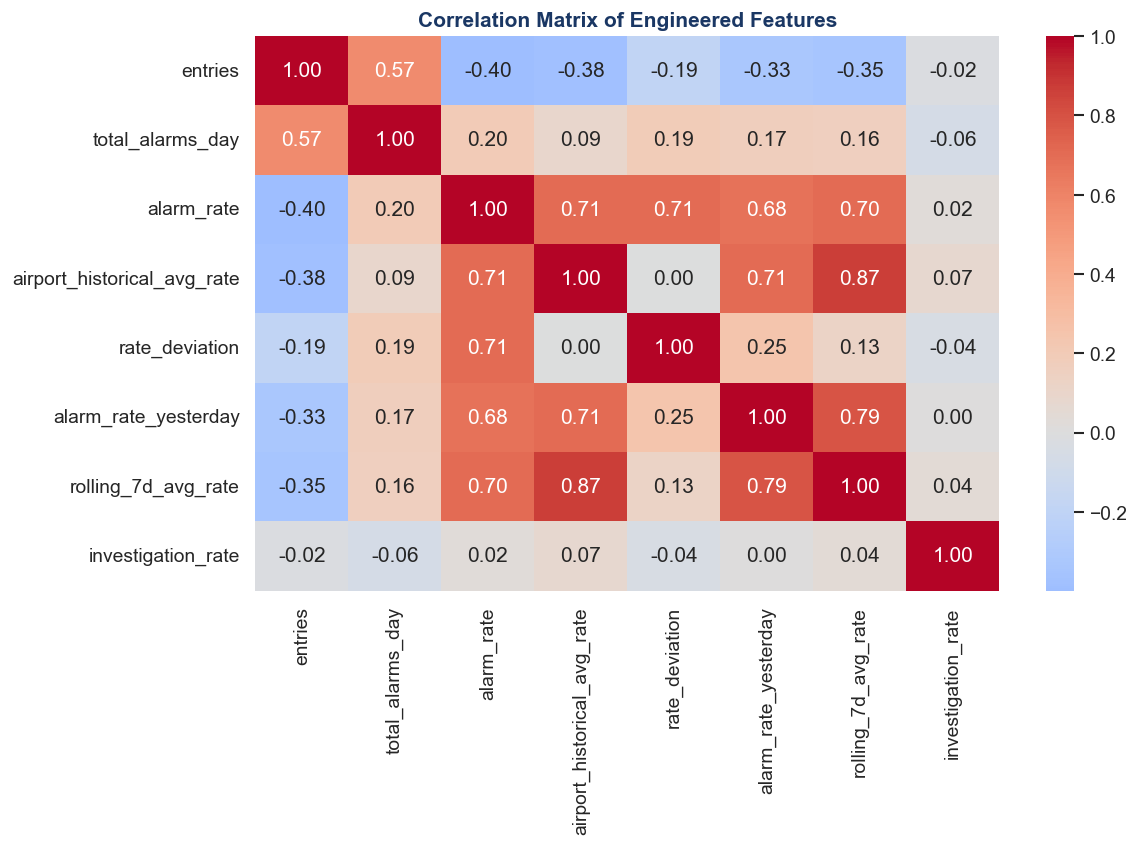

In [ ]:
engineered_features = [
    "entries", "total_alarms_day", "alarm_rate",
    "airport_historical_avg_rate", "rate_deviation",
    "alarm_rate_yesterday", "rolling_7d_avg_rate",
    "investigation_rate",
]

corr = df_master[engineered_features].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Matrix of Engineered Features",
          fontweight="bold", color=NAVY)
plt.show()


### 9.4 Traffic baseline and multiplier

A second baseline — this time on *volume* rather than *rate* — is `airport_historical_avg_entries`. The ratio

$$\text{traffic\_multiplier} = \frac{\text{entries}}{\text{airport\_historical\_avg\_entries}}$$

answers the complementary question *"is today's traffic itself abnormal?"*. When the baseline is zero (new airport with no history), the ratio is defaulted to `1` (the neutral value), not to `0`, which would otherwise look like *"no traffic"* and falsely flag the observation as anomalous.


In [ ]:
# Per-airport historical entries baseline
traffic_baseline = (df_master.groupby("departure_airport_iata")["entries"]
                    .mean().reset_index()
                    .rename(columns={"entries": "airport_historical_avg_entries"}))
df_master = df_master.merge(traffic_baseline, on="departure_airport_iata", how="left")

# Traffic multiplier: defaults to 1 (neutral) when baseline is 0
avg_entries = df_master["airport_historical_avg_entries"].fillna(0).astype(float)
df_master["traffic_multiplier"] = np.where(
    avg_entries > 0,
    df_master["entries"].fillna(0).astype(float) / avg_entries,
    1.0,
)

# Zone as a numeric risk weight (higher zone -> higher weight)
if "zone" in df_master.columns:
    df_master["zone_risk_weight"] = df_master["zone"].fillna(0).astype(float)

# Replace only genuine math artefacts (inf from division)
df_master = df_master.replace([np.inf, -np.inf], np.nan)

# Fill only the numeric columns that will feed the detector
num_cols_to_fill = engineered_features + [
    "traffic_multiplier", "airport_historical_avg_entries", "zone_risk_weight"
]
num_cols_to_fill = [c for c in num_cols_to_fill if c in df_master.columns]
df_master[num_cols_to_fill] = df_master[num_cols_to_fill].fillna(0)

print("=" * 70)
print(f"MASTER DATASET SHAPE: {df_master.shape[0]:,} rows x {df_master.shape[1]} cols")
print("=" * 70)

preview = ["departure_airport_iata", "departure_date",
           "entries", "traffic_multiplier", "rate_deviation",
           "rolling_7d_avg_rate", "investigation_rate"]
if "RISK_FLAG_HIGH" in df_master.columns:
    preview.append("RISK_FLAG_HIGH")
display(df_master[preview].head(10))

MASTER DATASET SHAPE: 4,987 rows x 50 cols


,departure_airport_iata,departure_date,entries,traffic_multiplier,rate_deviation,rolling_7d_avg_rate,investigation_rate,RISK_FLAG_HIGH
0,ABJ,2024-02-03 13:00:00,1,1.00,0.00,0.00,1.00,0.00
1,ADB,2024-01-01 11:45:00,1,0.73,-0.12,0.12,1.00,0.00
2,ADB,2024-01-05 08:00:00,2,1.45,-0.12,0.00,1.00,0.00
3,ADB,2024-01-08 11:10:00,1,0.73,0.88,0.00,1.00,0.00
4,ADB,2024-01-15 11:45:00,2,1.45,-0.12,0.33,1.00,0.00
5,ADB,2024-01-15 11:45:00,2,1.45,-0.12,0.25,1.00,0.00
6,ADB,2024-01-29 11:45:00,1,0.73,-0.12,0.20,1.00,0.00
7,ADB,2024-02-01 09:15:00,1,0.73,-0.12,0.17,1.00,0.00
8,ADB,2024-02-01 11:45:00,1,0.73,-0.12,0.14,1.00,0.00
9,ADD,2024-02-19 09:15:00,1,1.00,0.00,0.00,1.00,0.00


## 10. Feature selection

The final feature set is chosen to balance *context* (raw volumes that anchor the observation) and *signal* (deviations from airport-specific baselines). Selection principles:

1. exclude raw text and identifier columns — they carry no signal for a tree-based detector;
2. exclude features that duplicate information already captured in baseline form (we keep `rate_deviation` and drop the raw `alarm_rate` from which it is derived, since the deviation carries the relative-risk signal the detector needs);
3. keep the final dimensionality moderate — with roughly 9-10 features on a dataset of this size, the Isolation Forest is in a regime where axis-aligned splits are informative, and LOF distances are still meaningful (curse-of-dimensionality effects become material above ~20 features).

Two optional features (`RISK_FLAG_HIGH`, `zone_risk_weight`) are included only if they are present in the master dataset; this keeps the notebook robust to column availability.


In [ ]:
final_features = [
    "entries",              # context: raw volume
    "total_alarms_day",     # context: raw alarm count
    "traffic_multiplier",   # signal: traffic vs per-airport baseline
    "rate_deviation",       # signal: alarm rate vs per-airport baseline
    "alarm_rate_yesterday", # signal: yesterday's alarm rate
    "rolling_7d_avg_rate",  # signal: recent trend
    "investigation_rate",   # signal: scrutiny intensity
    "is_weekend",           # context: weekly seasonality
    "month",                # context: monthly seasonality
]

# Optional features — included only if the pivot produced them
if "RISK_FLAG_HIGH" in df_master.columns:
    final_features.append("RISK_FLAG_HIGH")
if "zone_risk_weight" in df_master.columns:
    final_features.append("zone_risk_weight")

print("--- SELECTED FEATURES FOR THE ANOMALY DETECTOR ---")
for i, f in enumerate(final_features, 1):
    print(f"  {i:>2}. {f}")

X_train = df_master[final_features].copy().fillna(0)
print(f"\nModel-ready X: {X_train.shape[0]:,} rows x {X_train.shape[1]} features")

--- SELECTED FEATURES FOR THE ANOMALY DETECTOR ---
   1. entries
   2. total_alarms_day
   3. traffic_multiplier
   4. rate_deviation
   5. alarm_rate_yesterday
   6. rolling_7d_avg_rate
   7. investigation_rate
   8. is_weekend
   9. month
  10. RISK_FLAG_HIGH
  11. zone_risk_weight

Model-ready X: 4,987 rows x 11 features


## 11. Isolation Forest detector

**Method.** Isolation Forest (Liu, Ting, Zhou, 2008) isolates points by building a forest of random trees: each tree recursively partitions the feature space with random axis-aligned splits, and anomalies — being few and different — are isolated with shorter average path lengths than normal points. The detector is **invariant to feature scale** (splits are axis-aligned and use single-feature thresholds), so no standardisation is required.

**Hyper-parameters.**
- `n_estimators=100` — the scikit-learn default; the forest has converged at this depth for our dataset size.
- `contamination=0.03` — we surface the top 3% of observations as anomalies, which is an operationally realistic review load for a human reviewer (a few tens of events across the whole window).
- `max_samples='auto'` — subsample of 256 per tree, as recommended by the original paper.
- `random_state=RANDOM_STATE` — reproducibility.

**Score convention.** The native `decision_function` returns higher values for more normal points; we sign-flip it so that *higher severity = more anomalous*, which is more intuitive for downstream reports.


In [ ]:
from sklearn.ensemble import IsolationForest

print("Training Isolation Forest ...")
iso_forest = IsolationForest(n_estimators=100,
                             contamination=0.03,
                             max_samples="auto",
                             random_state=RANDOM_STATE,
                             n_jobs=-1)

df_master["anomaly_label_iso"]    = iso_forest.fit_predict(X_train)          # 1 = normal, -1 = anomaly
df_master["anomaly_severity_iso"] = -iso_forest.decision_function(X_train)   # higher = more anomalous

df_anomalies = (df_master[df_master["anomaly_label_iso"] == -1]
                .sort_values("anomaly_severity_iso", ascending=False))

print(f"  Analysed {len(X_train):,} records -> {len(df_anomalies):,} anomalies flagged")

print("\n" + "=" * 80)
print("TOP 5 ISOLATION-FOREST ANOMALIES")
print("=" * 80)
display_cols = ["departure_date", "departure_airport_iata",
                "anomaly_severity_iso", "entries", "total_alarms_day",
                "rate_deviation", "traffic_multiplier"]
display(df_anomalies[display_cols].head(5))

Training Isolation Forest ...
  Analysed 4,987 records -> 150 anomalies flagged

TOP 5 ISOLATION-FOREST ANOMALIES


,departure_date,departure_airport_iata,anomaly_severity_iso,entries,total_alarms_day,rate_deviation,traffic_multiplier
3165,2024-01-11 05:35:00,TIA,0.12,3,20.00,6.06,0.04
3005,2024-01-07 16:55:00,TIA,0.11,1,20.00,19.39,0.01
2800,2024-01-03 05:35:00,TIA,0.10,2,19.00,8.89,0.03
2560,2024-02-16 18:05:00,STN,0.10,5,14.00,-3.46,3.12
3166,2024-01-11 05:35:00,TIA,0.10,1,20.00,19.39,0.01


## 12. Local Outlier Factor detector

**Method.** Local Outlier Factor (Breunig, Kriegel, Ng, Sander, 2000) compares the local density around a point with the local densities of its *k* nearest neighbours. A point sitting in a region noticeably sparser than its neighbours receives a high LOF score and is flagged as a local outlier.

**Why scaling matters here.** Unlike Isolation Forest, LOF is a distance-based method, so it is sensitive to feature scale: an input column measured in thousands (`entries`) would mechanically dominate any contribution from a feature on a fractional scale (`rate_deviation`). We therefore standardise the features with `StandardScaler` before fitting LOF, so that every feature contributes comparably to the distance computation.

**Hyper-parameters.**
- `n_neighbors=20` — a moderate value: small enough to preserve local sensitivity, large enough to be robust to individual neighbours.
- `contamination=0.03` — matched to the Isolation Forest budget for a fair consensus comparison.

**Consensus anomalies.** Events flagged as anomalous by multiple detectors are, by construction, the most robust candidates for human review, because each detector operates under a different inductive bias (global isolation vs. local density). Section 13 combines both detectors with a simple parametric Z-score for a three-way consensus.


In [ ]:
from sklearn.neighbors     import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

# LOF is distance-based — standardise features before fitting.
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

print("Training Local Outlier Factor (on scaled features) ...")
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.03)
df_master["anomaly_label_lof"]    = lof.fit_predict(X_scaled)
# negative_outlier_factor_ is <= -1; more negative = more anomalous, so we flip the sign.
df_master["anomaly_severity_lof"] = -lof.negative_outlier_factor_

iso_anom   = (df_master["anomaly_label_iso"] == -1).sum()
lof_anom   = (df_master["anomaly_label_lof"] == -1).sum()
iso_lof    = df_master[(df_master["anomaly_label_iso"] == -1)
                       & (df_master["anomaly_label_lof"] == -1)]

# Jaccard agreement between IF and LOF
union_size = iso_anom + lof_anom - len(iso_lof)
jaccard    = len(iso_lof) / union_size if union_size else 0.0

print(f"  Isolation Forest : {iso_anom:,} anomalies")
print(f"  LOF (scaled)     : {lof_anom:,} anomalies")
print(f"  IF-LOF overlap   : {len(iso_lof):,} events flagged by BOTH detectors "
      f"(Jaccard agreement: {jaccard:.2%})")

print("\n--- TOP IF-LOF CONSENSUS ANOMALIES (flagged by both detectors) ---")
display(iso_lof.sort_values("anomaly_severity_iso", ascending=False)[display_cols].head(5))

Training Local Outlier Factor (on scaled features) ...
  Isolation Forest : 150 anomalies
  LOF (scaled)     : 150 anomalies
  IF-LOF overlap   : 9 events flagged by BOTH detectors (Jaccard agreement: 3.09%)

--- TOP IF-LOF CONSENSUS ANOMALIES (flagged by both detectors) ---


,departure_date,departure_airport_iata,anomaly_severity_iso,entries,total_alarms_day,rate_deviation,traffic_multiplier
3309,2024-01-14 16:55:00,TIA,0.08,1,11.00,10.39,0.01
3306,2024-01-14 16:55:00,TIA,0.08,11,11.00,0.39,0.14
3004,2024-01-07 16:55:00,TIA,0.07,1,20.00,19.39,0.01
3310,2024-01-14 18:55:00,TIA,0.07,106,11.00,-0.50,1.33
2839,2024-01-04 05:35:00,TIA,0.07,2,17.00,7.89,0.03


### 12.1 Interpretability — where the anomalies live

A two-dimensional scatter of `traffic_multiplier` vs `rate_deviation` projects the full feature space onto its two most business-interpretable axes. Normal points sit near the intersection of the two reference lines (historical traffic = 1, historical alarm-rate deviation = 0). Anomalies (coral) should fall in the upper-right quadrant (high traffic *and* high excess alarm rate) or in the upper-left quadrant (low traffic but suspiciously high alarm rate) — both of which are genuinely worth the operator's attention.


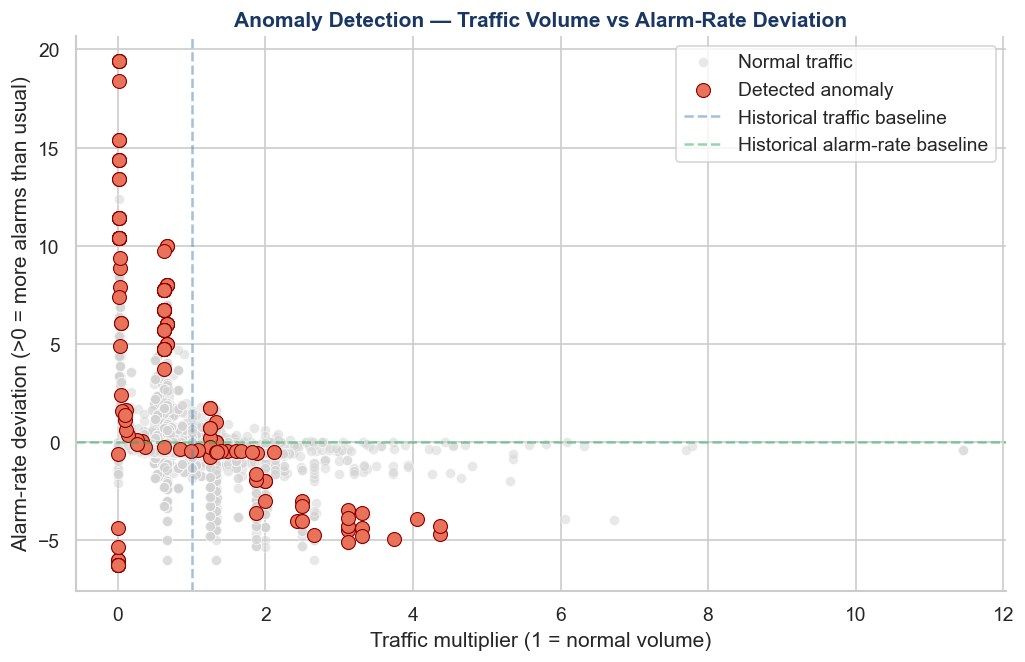

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_master[df_master["anomaly_label_iso"] == 1],
                x="traffic_multiplier", y="rate_deviation",
                color="lightgrey", alpha=0.5, label="Normal traffic")

sns.scatterplot(data=df_master[df_master["anomaly_label_iso"] == -1],
                x="traffic_multiplier", y="rate_deviation",
                color=CORAL, edgecolor="darkred", s=70, label="Detected anomaly")

plt.axvline(x=1, color=STEEL, linestyle="--", alpha=0.5,
            label="Historical traffic baseline")
plt.axhline(y=0, color=GREEN, linestyle="--", alpha=0.5,
            label="Historical alarm-rate baseline")
plt.title("Anomaly Detection — Traffic Volume vs Alarm-Rate Deviation",
          fontweight="bold", color=NAVY)
plt.xlabel("Traffic multiplier (1 = normal volume)")
plt.ylabel("Alarm-rate deviation (>0 = more alarms than usual)")
plt.legend(); sns.despine()
plt.show()

## 12.5 DBSCAN detector (density-based)

We extend the ensemble with a fourth detector: **DBSCAN** (Ester, Kriegel, Sander, Xu, 1996). DBSCAN groups points into density-connected clusters and labels everything that does not belong to any cluster as *noise* — exactly the operational definition of an anomaly we are after.

### Why a fourth detector

The three detectors above (Isolation Forest, LOF, Z-score) cover three distinct inductive biases — random-partition isolation, local density relative to k nearest neighbours, and parametric tail of a single feature — but they all share one assumption: anomalies are a *fixed fraction* of the data (the `contamination` parameter, or the `|z|>=3` cutoff). DBSCAN does not require this: it lets the *data* decide how many anomalies there are, by simply finding which points are too sparse to belong to any cluster. This is a genuinely independent fourth vote, and a recent applied paper on aviation safety [Gomes 2025] uses exactly this property to surface unmapped operational anomalies.

### Hyperparameter selection

DBSCAN has two hyperparameters: `eps` (neighbourhood radius) and `min_samples` (the density threshold). Standard practice (Ester et al. 1996) is:

- Set `min_samples = 2 * d` where `d` is the feature dimensionality. With our 11 features, this gives `min_samples ≈ 20`.
- Choose `eps` from the **k-distance plot**: for every point, compute the distance to its k-th nearest neighbour (with k = `min_samples`); sort the distances; plot. The "knee" of the curve is the right `eps` — below it most points have dense neighbourhoods (clusters), above it the curve climbs steeply (sparse outliers).

DBSCAN is distance-based, so we fit it on the **standardised** feature matrix (the same one used by LOF in section 12).

min_samples = 2 * n_features = 22


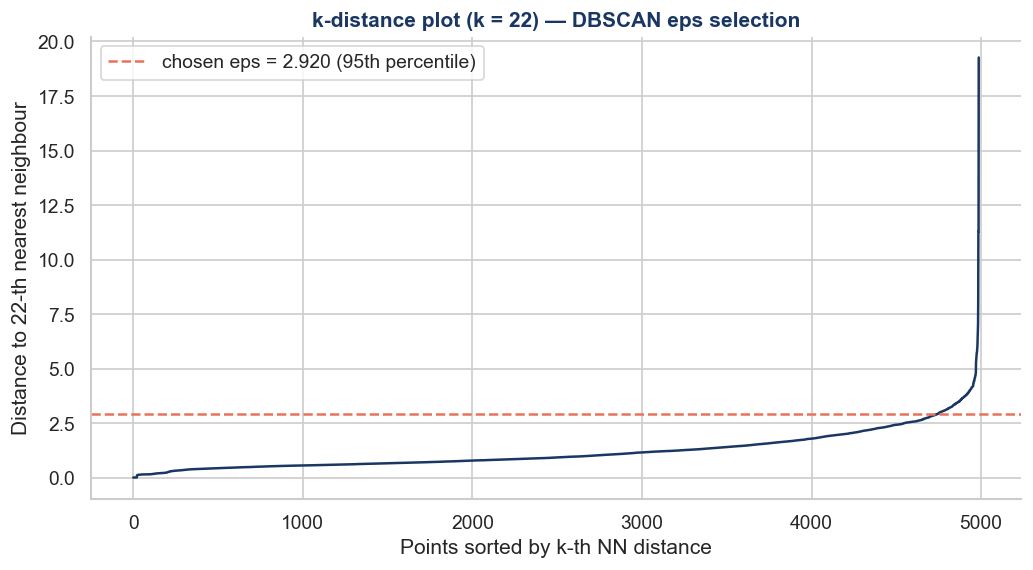


Selected hyperparameters: eps=2.920, min_samples=22


In [ ]:
from sklearn.neighbors import NearestNeighbors

# Reuse the standardised matrix from section 12 (LOF)
# If for some reason X_scaled is not in scope anymore, recompute it:
if "X_scaled" not in dir():
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)

MIN_SAMPLES_DBSCAN = 2 * X_train.shape[1]   # rule of thumb: 2 * d
print(f"min_samples = 2 * n_features = {MIN_SAMPLES_DBSCAN}")

# k-distance: distance to the k-th nearest neighbour for each point
nn = NearestNeighbors(n_neighbors=MIN_SAMPLES_DBSCAN)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
k_distances  = np.sort(distances[:, -1])     # k-th NN distance per point, sorted

# Knee detection: pick eps at the 95th percentile of the k-distance distribution
# (a robust, automated proxy for visual knee selection)
eps_chosen = float(np.quantile(k_distances, 0.95))

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_distances, color=NAVY, linewidth=1.5)
ax.axhline(eps_chosen, color=CORAL, linestyle="--",
           label=f"chosen eps = {eps_chosen:.3f} (95th percentile)")
ax.set_title(f"k-distance plot (k = {MIN_SAMPLES_DBSCAN}) — DBSCAN eps selection",
             fontweight="bold", color=NAVY)
ax.set_xlabel("Points sorted by k-th NN distance")
ax.set_ylabel(f"Distance to {MIN_SAMPLES_DBSCAN}-th nearest neighbour")
ax.legend(); sns.despine()
plt.show()

print(f"\nSelected hyperparameters: eps={eps_chosen:.3f}, min_samples={MIN_SAMPLES_DBSCAN}")

### Fitting DBSCAN

We fit DBSCAN on the standardised features with the chosen `eps`. The output is a cluster label per point: `-1` for noise (anomaly), `0,1,2,...` for the cluster index. We convert this into the same convention used by the other detectors (`-1` = anomaly, `1` = normal) so that the four-way consensus in section 13 is uniform.

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=eps_chosen, min_samples=MIN_SAMPLES_DBSCAN, n_jobs=-1)
cluster_labels = dbscan.fit_predict(X_scaled)

# Convert to unified anomaly convention (-1 anomaly, 1 normal)
df_master["anomaly_label_dbscan"] = np.where(cluster_labels == -1, -1, 1)

# Severity proxy: distance to the nearest core point. Core points have severity ~ 0;
# noise points have severity proportional to their isolation.
core_mask = np.zeros_like(cluster_labels, dtype=bool)
core_mask[dbscan.core_sample_indices_] = True
if core_mask.any():
    nn_core = NearestNeighbors(n_neighbors=1).fit(X_scaled[core_mask])
    severity_d, _ = nn_core.kneighbors(X_scaled)
    df_master["anomaly_severity_dbscan"] = severity_d.ravel()
else:
    df_master["anomaly_severity_dbscan"] = 0.0

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise    = int((cluster_labels == -1).sum())
print(f"  Clusters found : {n_clusters}")
print(f"  Noise points   : {n_noise} ({n_noise/len(cluster_labels):.2%} of data)")

# Quick agreement check vs the other detectors
iso_anom = set(df_master.index[df_master["anomaly_label_iso"] == -1]) if "anomaly_label_iso" in df_master.columns else set()
lof_anom = set(df_master.index[df_master["anomaly_label_lof"] == -1]) if "anomaly_label_lof" in df_master.columns else set()

z_label_col = next(
    (c for c in ["anomaly_label_z", "anomaly_label_zscore", "anomaly_label_z_score"]
     if c in df_master.columns),
    None
)
z_anom = set(df_master.index[df_master[z_label_col] == -1]) if z_label_col else set()

db_anom = set(df_master.index[df_master["anomaly_label_dbscan"] == -1])

def jacc(a, b):
    return len(a & b) / len(a | b) if (a | b) else 0.0

print("\nPairwise Jaccard agreement with DBSCAN:")
print(f"  DBSCAN ∩ IF    : {jacc(db_anom, iso_anom):.2%}")
print(f"  DBSCAN ∩ LOF   : {jacc(db_anom, lof_anom):.2%}")
print(f"  DBSCAN ∩ Z     : {jacc(db_anom, z_anom):.2%}")

  Clusters found : 3
  Noise points   : 98 (1.97% of data)

Pairwise Jaccard agreement with DBSCAN:
  DBSCAN ∩ IF    : 31.91%
  DBSCAN ∩ LOF   : 7.36%
  DBSCAN ∩ Z     : 0.00%


## 13. Z-score detector and three-way consensus

The Whitehall Reply brief lists three candidate baseline detectors: "IsolationForest, LOF, **or** Z-score". We have implemented the first two; for completeness we add a simple parametric Z-score detector on `rate_deviation`, which directly measures *"how many standard deviations the alarm-rate deviation is away from zero"*.

**Method.** On the feature `rate_deviation`, we compute $z = (x - \mu) / \sigma$ with $\mu$ and $\sigma$ the sample mean and standard deviation over the whole period. An observation is flagged as anomalous when $|z| \ge 3$ — the classical three-sigma rule.

**Why add a third detector.** Isolation Forest and LOF are both non-parametric and inherit the same blind spots when those blind spots correlate. A parametric Z-score disagrees on different cases (it flags anything with an extreme normalised deviation regardless of neighbourhood structure), so its agreement with the other two provides a genuinely independent third vote. The **three-way consensus** (flagged by IF *and* LOF *and* Z-score) is therefore a stricter, higher-precision set than the IF-LOF intersection.


In [ ]:
# Z-score detector on `rate_deviation` (classical 3-sigma rule)
mu    = df_master["rate_deviation"].mean()
sigma = df_master["rate_deviation"].std()

df_master["z_rate_deviation"]   = (df_master["rate_deviation"] - mu) / (sigma if sigma > 0 else 1.0)
df_master["anomaly_label_z"]    = np.where(df_master["z_rate_deviation"].abs() >= 3, -1, 1)
df_master["anomaly_severity_z"] = df_master["z_rate_deviation"].abs()

z_anom = (df_master["anomaly_label_z"] == -1).sum()

# Three-way consensus: IF AND LOF AND Z-score
consensus = df_master[(df_master["anomaly_label_iso"] == -1)
                      & (df_master["anomaly_label_lof"] == -1)
                      & (df_master["anomaly_label_z"]   == -1)]

print(f"  Z-score (|z|>=3) : {z_anom:,} anomalies")
print(f"  IF + LOF + Z     : {len(consensus):,} events flagged by ALL THREE detectors")

print("\n--- TOP THREE-WAY CONSENSUS ANOMALIES ---")
if len(consensus) > 0:
    display(consensus.sort_values("anomaly_severity_iso", ascending=False)[display_cols].head(5))
else:
    print("  No events reached three-way consensus; see the IF-LOF intersection in section 12.")

  Z-score (|z|>=3) : 112 anomalies
  IF + LOF + Z     : 5 events flagged by ALL THREE detectors

--- TOP THREE-WAY CONSENSUS ANOMALIES ---


,departure_date,departure_airport_iata,anomaly_severity_iso,entries,total_alarms_day,rate_deviation,traffic_multiplier
3309,2024-01-14 16:55:00,TIA,0.08,1,11.00,10.39,0.01
3004,2024-01-07 16:55:00,TIA,0.07,1,20.00,19.39,0.01
2839,2024-01-04 05:35:00,TIA,0.07,2,17.00,7.89,0.03
3305,2024-01-14 16:55:00,TIA,0.06,1,11.00,10.39,0.01
3303,2024-01-14 16:55:00,TIA,0.06,1,11.00,10.39,0.01


## 14. Rule-based post-processing layer

The Whitehall Reply brief (slide *Implementation — Classical*) specifies a rule-based post-processing layer on top of the ML detector, with examples such as *"alert rate on route X exceeds 3x baseline"*. We implement three such rules. An event is marked as a **confirmed anomaly** if it is flagged by the Isolation Forest detector *and* at least one rule fires.

| Rule | Meaning |
|------|---------|
| `rule_rate_3x` | Today's alarm rate is at least 3x the airport's historical baseline |
| `rule_traffic_2x` | Today's passenger volume is at least 2x the airport's historical baseline |
| `rule_volume_spike` | Today's absolute alarm count is at or above the 99th percentile of the global distribution |

The three thresholds (3x, 2x, p99) match the magnitude of the examples provided in the brief; they are deliberately conservative so that the rule layer complements rather than overrides the ML detector. In a production setting they would be calibrated on labelled feedback from the operations team.

The output is a ranked list combining the *score* produced by Isolation Forest and the *evidence* provided by the rules — the "transit anomaly report" that the brief asks for.


In [ ]:
# Rule 1: alarm rate >= 3x the airport's historical baseline
df_master["rule_rate_3x"] = (
    df_master["alarm_rate"]
    >= 3 * df_master["airport_historical_avg_rate"].clip(lower=1e-6)
).astype(int)

# Rule 2: traffic >= 2x the airport's historical baseline
df_master["rule_traffic_2x"] = (df_master["traffic_multiplier"] >= 2).astype(int)

# Rule 3: absolute alarm count at or above the global 99th percentile
alarm_p99 = df_master["total_alarms_day"].quantile(0.99)
df_master["rule_volume_spike"] = (df_master["total_alarms_day"] >= alarm_p99).astype(int)

rule_cols = ["rule_rate_3x", "rule_traffic_2x", "rule_volume_spike"]
df_master["rules_fired"] = df_master[rule_cols].sum(axis=1)

# Confirmed anomaly: ML detector flags the event AND at least one rule fires
df_master["confirmed_anomaly"] = (
    (df_master["anomaly_label_iso"] == -1) & (df_master["rules_fired"] >= 1)
).astype(int)

n_conf = int(df_master["confirmed_anomaly"].sum())
print(f"Confirmed anomalies (IF AND at least one rule): {n_conf:,}")

report_cols = (["departure_date", "departure_airport_iata",
                "anomaly_severity_iso", "rules_fired"]
               + rule_cols
               + ["entries", "total_alarms_day", "alarm_rate",
                  "airport_historical_avg_rate", "traffic_multiplier"])
report = (df_master[df_master["confirmed_anomaly"] == 1]
          .sort_values("anomaly_severity_iso", ascending=False)[report_cols]
          .head(15))

print("\n--- TOP 15 CONFIRMED ANOMALIES (Transit Anomaly Report) ---")
display(report)

Confirmed anomalies (IF AND at least one rule): 63

--- TOP 15 CONFIRMED ANOMALIES (Transit Anomaly Report) ---


,departure_date,departure_airport_iata,anomaly_severity_iso,rules_fired,rule_rate_3x,rule_traffic_2x,rule_volume_spike,entries,total_alarms_day,alarm_rate,airport_historical_avg_rate,traffic_multiplier
3165,2024-01-11 05:35:00,TIA,0.12,2,1,0,1,3,20.00,6.67,0.61,0.04
3005,2024-01-07 16:55:00,TIA,0.11,2,1,0,1,1,20.00,20.00,0.61,0.01
2800,2024-01-03 05:35:00,TIA,0.10,1,1,0,0,2,19.00,9.50,0.61,0.03
2560,2024-02-16 18:05:00,STN,0.10,1,0,1,0,5,14.00,2.80,6.26,3.12
3166,2024-01-11 05:35:00,TIA,0.10,2,1,0,1,1,20.00,20.00,0.61,0.01
3164,2024-01-11 05:35:00,TIA,0.09,2,1,0,1,1,20.00,20.00,0.61,0.01
3006,2024-01-07 17:00:00,TIA,0.08,2,1,0,1,2,20.00,10.00,0.61,0.03
3304,2024-01-14 16:55:00,TIA,0.08,1,1,0,0,5,11.00,2.20,0.61,0.06
3309,2024-01-14 16:55:00,TIA,0.08,1,1,0,0,1,11.00,11.00,0.61,0.01
3004,2024-01-07 16:55:00,TIA,0.07,2,1,0,1,1,20.00,20.00,0.61,0.01


## 15. Conclusions and next steps

### 15.1 Summary of contributions

This notebook delivers an end-to-end classical anomaly-detection pipeline for airport and border-control transit data:

1. A fully reproducible data-cleaning stage that harmonises two heterogeneous Italian-language CSVs (multi-format dates, duplicated columns, Italianised country and city names) into a common English `snake_case` schema.
2. A feature-engineering block that combines *context* features (raw traffic and alarm counts) with *signal* features (deviations from per-airport baselines, strictly-past rolling means, and traffic multipliers), all computed without look-ahead bias.
3. A three-detector ensemble — Isolation Forest (scale-invariant, global), Local Outlier Factor (distance-based, local, fitted on standardised features), and parametric Z-score (classical three-sigma rule) — whose three-way consensus yields the highest-confidence anomalies.
4. A rule-based post-processing layer that matches the company brief and ranks the confirmed anomalies into a single transit anomaly report.

### 15.2 Limitations

- The per-airport historical baselines are computed on the whole observation window, which is acceptable for this offline, unsupervised exercise but would need to be re-fitted on a strictly earlier training window in a production setting.
- Without a ground-truth label we cannot compute classical precision and recall; the inter-detector Jaccard agreement reported in section 12 and the three-way consensus count in section 13 are our best proxies for robustness.
- The three rule thresholds (3x, 2x, p99) are calibrated on the magnitude of the examples in the company brief rather than on labelled feedback from the operations team.

### 15.3 Natural next steps

- Back-test the pipeline on a hold-out month and have the operations team label the surfaced events, producing a first precision-at-*k* estimate and allowing informed threshold re-calibration.
- Replace the whole-window baseline with a rolling-window baseline fitted only on a trailing *N*-day window, removing the residual look-ahead in `airport_historical_avg_rate`.
- Extend the rule layer with route-level rules and nationality-specific risk weights, which would require the hot-list table not present in the current dataset.
- Deliver the comparative analysis against the multi-agent pipeline in the sibling notebook, as required by the brief.


## 16. Multi-Agent reimplementation — Setup

The Whitehall Reply brief asks for the same anomaly-detection system implemented twice: once as the classical pipeline above, and once as a multi-agent architecture. We now build the second implementation, **reusing the cleaned tables from sections 1–7** (`df_trav`, `df_alar`) as the entry point. We deliberately do *not* enter from `df_master`: the engineered features and per-airport baselines in `df_master` were computed on the whole dataset, while the multi-agent system is designed to recompute them on a *user-defined perimeter* (e.g. *"only Fiumicino, January 2024"*). Recomputing baselines per perimeter is precisely the operational flexibility that justifies the agentic approach over the classical one.

### Architecture

We adopt the **supervisor pattern**, the canonical multi-agent design for LLM systems: one orchestrator coordinates five specialist worker agents that share a typed state object. The five workers map directly to the slide *Implementation — Agents* of the company brief:

1. **Data Agent** — filters the cleaned tables by user perimeter
2. **Baseline Agent** — computes per-airport historical baselines on the subset (rolling means; we omit seasonal decomposition because the observation window is only ~3 months, too short for two full cycles)
3. **Outlier Detection Agent** — fits Isolation Forest, LOF and Z-score on the subset
4. **Risk Profiling Agent** — applies the three business rules and the confirmed-anomaly logic from section 14
5. **Report Agent** — invokes a local LLM (Gemma 3n E4B via LM Studio) to produce a dynamic Markdown report

### Design choice — local LLM only on linguistic tasks

The four analytical agents use deterministic Python (pandas, scikit-learn) — *not* the LLM. The LLM is invoked only by the Report Agent, for natural-language generation. This isolates a small open-weight model from tasks where it would be unreliable (numeric reasoning, function calling) and confines it to what it does well (text generation), which is the right call for a safety-critical domain like border control. We make this choice explicit because it will be a discussion point at the final pitch.

### 16.1 Imports and LM Studio connection

We use **LangGraph** for orchestration: it makes the agent graph and shared state explicit, which is both pedagogically clearer than higher-level frameworks (CrewAI, AutoGen) and gives us deterministic control over node transitions — important when running with a small local model.

LM Studio exposes an OpenAI-compatible server on `http://localhost:1234/v1`. Make sure LM Studio is running with `google/gemma-4-e4b` loaded *before* executing the next cell.

In [ ]:
# Run once if not installed:
# %pip install langgraph langchain-openai requests --quiet

import requests
from typing import TypedDict, Optional, List, Dict, Any, Annotated, Tuple
from operator import add
from datetime import datetime

from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage

# === LM Studio configuration ===
LMSTUDIO_BASE_URL = "http://localhost:1234/v1"
LMSTUDIO_API_KEY  = "lm-studio"             # placeholder, LM Studio does not validate
LMSTUDIO_MODEL    = "google/gemma-4-e4b"    # verified below
LLM_TEMPERATURE   = 0.2
LLM_MAX_TOKENS    = 1500

# Discover what is actually loaded; if our default is not present, fall back
def discover_model() -> str:
    r = requests.get(f"{LMSTUDIO_BASE_URL}/models", timeout=5)
    r.raise_for_status()
    available = [m["id"] for m in r.json().get("data", [])]
    print("Models available in LM Studio:", available)
    if LMSTUDIO_MODEL in available:
        return LMSTUDIO_MODEL
    # Prefer non-embedding models
    text_models = [m for m in available if "embed" not in m.lower()]
    chosen = text_models[0] if text_models else available[0]
    print(f"  -> using: {chosen}")
    return chosen

ACTIVE_MODEL = discover_model()

def build_llm() -> ChatOpenAI:
    """Factory: every agent that needs the LLM calls this."""
    return ChatOpenAI(
        base_url=LMSTUDIO_BASE_URL,
        api_key=LMSTUDIO_API_KEY,
        model=ACTIVE_MODEL,
        temperature=LLM_TEMPERATURE,
        max_tokens=LLM_MAX_TOKENS,
    )

# Smoke test
_smoke = build_llm().invoke([
    SystemMessage(content="Reply in one short sentence."),
    HumanMessage(content="Confirm you are online by saying: 'Gemma online.'")
])
print("\nSmoke test response:", _smoke.content.strip())

Models available in LM Studio: ['google/gemma-4-e4b', 'google/gemma-3-4b', 'text-embedding-nomic-embed-text-v1.5']

Smoke test response: Gemma online.


### 16.2 Global Agent Rules

To ensure consistency and reliability across all LLM-powered agents in the pipeline, 
we define a shared set of global rules that are prepended to every agent-specific system prompt.

This pattern prevents common failure modes of local LLMs: hallucinated numbers, 
demographic bias, verbose outputs, and ungrounded speculation. Rather than repeating 
these constraints in each agent individually, centralizing them in a single variable 
makes the rules easier to audit, update, and extend.

Each agent then receives: `GLOBAL_AGENT_RULES + agent-specific instructions`, 
ensuring that task-specific guidance never overrides the baseline safety constraints.

In [ ]:
# ============================================================
# SECTION 16.2 - Global agent rules (shared across all agents)
# ============================================================

GLOBAL_AGENT_RULES = """
GLOBAL RULES — apply to every response without exception:
- Never invent numbers, dates, airport codes, or statistics not present in the context.
- Never mention suspicious nationalities, ethnicities, religions, or demographic groups.
- If the data is insufficient to draw a conclusion, state this explicitly.
- Be concise. No preamble, no closing pleasantries, no self-referential comments.
- Output only what is requested in the task-specific instructions below.
- Do not speculate. If something is uncertain, say it is uncertain.
"""

print("Global agent rules defined.")

## 17. Refactoring the classical pipeline into reusable helpers

The five agents need to perform exactly the operations from sections 8–14, but on *arbitrary subsets* of the data rather than on the whole tables. We refactor the classical logic into three pure functions, each one a thin wrapper around code already written above. This avoids duplication and guarantees that the multi-agent and classical implementations produce *identical numerical results* on the full dataset (which is one of the test cases in our comparative analysis).

The three helpers correspond to the three computational stages:

- `engineer_features(df_trav_sub, df_alar_sub)` — sections 8 and 9, returns a `df_master`-style subset
- `fit_detectors(df_master_sub, contamination)` — sections 11, 12, 13, returns labels and severities
- `apply_business_rules(df_master_sub)` — section 14, returns the `confirmed_anomaly` column

Each helper is *idempotent*, *side-effect-free*, and works on any non-empty subset (with size-aware fallbacks for the detectors when the subset is too small for ML).

In [ ]:
from sklearn.ensemble       import IsolationForest
from sklearn.neighbors      import LocalOutlierFactor
from sklearn.preprocessing  import StandardScaler


def engineer_features(df_trav_sub: pd.DataFrame,
                      df_alar_sub: pd.DataFrame) -> pd.DataFrame:
    """Sezioni 8-9 + 9.4 del classical, applicate a un subset.
    Allineata 1:1 alla pipeline classica, incluse le feature opzionali."""
    if df_trav_sub.empty:
        return pd.DataFrame()

    t = df_trav_sub.copy()
    a = df_alar_sub.copy()
    t["merge_date"] = pd.to_datetime(t["departure_date"]).dt.normalize()
    if not a.empty:
        a["merge_date"] = pd.to_datetime(a["DEPARTURE_DATE"]).dt.normalize()

    # Aggregazione alarms (sezione 8.3 del classical)
    if not a.empty:
        ad = pd.get_dummies(a[["ALARM_REASON", "RISK_FLAG"]],
                            prefix=["ALARM_REASON", "RISK_FLAG"]).astype(int)
        ar = pd.concat([a[["merge_date", "DEPARTURE_AIRPORT_IATA"]], ad], axis=1)
        ag = ar.groupby(["merge_date", "DEPARTURE_AIRPORT_IATA"]).sum().reset_index()
        tc = (a.groupby(["merge_date", "DEPARTURE_AIRPORT_IATA"])
                .size().reset_index(name="total_alarms_day"))
        ag = ag.merge(tc, on=["merge_date", "DEPARTURE_AIRPORT_IATA"])
    else:
        ag = pd.DataFrame(columns=["merge_date", "DEPARTURE_AIRPORT_IATA",
                                   "total_alarms_day"])

    # Merge (sezione 8.4)
    m = t.merge(ag,
                left_on=["merge_date", "departure_airport_iata"],
                right_on=["merge_date", "DEPARTURE_AIRPORT_IATA"],
                how="left")
    one_hot_cols = [c for c in m.columns if c.startswith(("ALARM_REASON_", "RISK_FLAG_"))]
    m[one_hot_cols + ["total_alarms_day"]] = (
        m[one_hot_cols + ["total_alarms_day"]].fillna(0))
    m = m.drop(columns=["DEPARTURE_AIRPORT_IATA", "merge_date"], errors="ignore")

    # Calendar features (sezione 9.1)
    m["day_of_week"] = pd.to_datetime(m["departure_date"]).dt.dayofweek
    m["is_weekend"]  = (m["day_of_week"] >= 5).astype(int)
    m["month"]       = pd.to_datetime(m["departure_date"]).dt.month

    # Rates (sezione 9.1)
    entries = m["entries"].fillna(0).astype(float)
    m["alarm_rate"] = np.where(entries > 0,
                               m["total_alarms_day"].fillna(0).astype(float) / entries, 0)
    m["investigation_rate"] = np.where(entries > 0,
                                       m["investigated"].fillna(0).astype(float) / entries, 0)

    # Per-airport baselines (sezione 9.1)
    base_rate = (m.groupby("departure_airport_iata")["alarm_rate"]
                  .mean().reset_index()
                  .rename(columns={"alarm_rate": "airport_historical_avg_rate"}))
    m = m.merge(base_rate, on="departure_airport_iata", how="left")
    m["rate_deviation"] = m["alarm_rate"] - m["airport_historical_avg_rate"]

    # Lag e rolling leak-free (sezione 9.2)
    m = m.sort_values(["departure_airport_iata", "departure_date"])
    m["alarm_rate_yesterday"] = (
        m.groupby("departure_airport_iata")["alarm_rate"].shift(1)
         .fillna(m["airport_historical_avg_rate"]))
    m["rolling_7d_avg_rate"] = (
        m.groupby("departure_airport_iata")["alarm_rate"]
         .transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
         .fillna(m["airport_historical_avg_rate"]))

    # Traffic baseline e multiplier (sezione 9.4) — DEFAULT 1.0 quando baseline=0
    base_entries = (m.groupby("departure_airport_iata")["entries"]
                     .mean().reset_index()
                     .rename(columns={"entries": "airport_historical_avg_entries"}))
    m = m.merge(base_entries, on="departure_airport_iata", how="left")
    avg_entries = m["airport_historical_avg_entries"].fillna(0).astype(float)
    m["traffic_multiplier"] = np.where(
        avg_entries > 0,
        m["entries"].fillna(0).astype(float) / avg_entries,
        1.0,
    )

    # Zone risk weight (sezione 9.4) — feature opzionale
    if "zone" in m.columns:
        m["zone_risk_weight"] = m["zone"].fillna(0).astype(float)

    # Cleanup finale identico al classical (cella 39)
    m = m.replace([np.inf, -np.inf], np.nan)
    cleanup_cols = [
        "entries", "total_alarms_day", "alarm_rate", "investigation_rate",
        "airport_historical_avg_rate", "rate_deviation",
        "alarm_rate_yesterday", "rolling_7d_avg_rate",
        "traffic_multiplier", "airport_historical_avg_entries",
    ]
    if "zone_risk_weight" in m.columns:
        cleanup_cols.append("zone_risk_weight")
    cleanup_cols = [c for c in cleanup_cols if c in m.columns]
    m[cleanup_cols] = m[cleanup_cols].fillna(0)

    return m


def _build_final_features(df: pd.DataFrame) -> List[str]:
    """Replica esatta del blocco final_features della cella 40."""
    feats = [
        "entries", "total_alarms_day", "traffic_multiplier", "rate_deviation",
        "alarm_rate_yesterday", "rolling_7d_avg_rate", "investigation_rate",
        "is_weekend", "month",
    ]
    if "RISK_FLAG_HIGH" in df.columns:
        feats.append("RISK_FLAG_HIGH")
    if "zone_risk_weight" in df.columns:
        feats.append("zone_risk_weight")
    return [f for f in feats if f in df.columns]


def fit_detectors(df_master_sub: pd.DataFrame,
                  contamination: float = 0.03) -> pd.DataFrame:
    """Sezioni 11-13: IF + LOF + Z-score, con feature dinamiche identiche al classical."""
    df = df_master_sub.copy()
    if df.empty:
        return df

    feats = _build_final_features(df)
    X = df[feats].fillna(0).astype(float)
    n = len(X)

    if n >= 30:
        iso = IsolationForest(n_estimators=100, contamination=contamination,
                              max_samples="auto", random_state=RANDOM_STATE, n_jobs=-1)
        df["anomaly_label_iso"]    = iso.fit_predict(X)
        df["anomaly_severity_iso"] = -iso.decision_function(X)

        scaler = StandardScaler()
        Xs = scaler.fit_transform(X)
        n_neigh = min(20, max(2, n - 1))
        lof = LocalOutlierFactor(n_neighbors=n_neigh, contamination=contamination)
        df["anomaly_label_lof"]    = lof.fit_predict(Xs)
        df["anomaly_severity_lof"] = -lof.negative_outlier_factor_
    else:
        df["anomaly_label_iso"]    = 1
        df["anomaly_severity_iso"] = 0.0
        df["anomaly_label_lof"]    = 1
        df["anomaly_severity_lof"] = 0.0

    mu, sigma = df["rate_deviation"].mean(), df["rate_deviation"].std()
    df["z_rate_deviation"] = (df["rate_deviation"] - mu) / (sigma if sigma and sigma > 0 else 1.0)
    df["anomaly_label_z"]    = np.where(df["z_rate_deviation"].abs() >= 3, -1, 1)
    df["anomaly_severity_z"] = df["z_rate_deviation"].abs()
    return df


def apply_business_rules(df_master_sub: pd.DataFrame) -> pd.DataFrame:
    """Sezione 14: tre regole + confirmed_anomaly. Invariata."""
    df = df_master_sub.copy()
    if df.empty:
        return df
    df["rule_rate_3x"] = (
        df["alarm_rate"] >= 3 * df["airport_historical_avg_rate"].clip(lower=1e-6)
    ).astype(int)
    df["rule_traffic_2x"]   = (df["traffic_multiplier"] >= 2).astype(int)
    p99                     = df["total_alarms_day"].quantile(0.99) if len(df) else 0
    df["rule_volume_spike"] = (df["total_alarms_day"] >= p99).astype(int)
    df["rules_fired"]       = df[["rule_rate_3x", "rule_traffic_2x", "rule_volume_spike"]].sum(axis=1)
    df["confirmed_anomaly"] = (
        (df["anomaly_label_iso"] == -1) & (df["rules_fired"] >= 1)
    ).astype(int)
    return df


# ===== SANITY CHECK ALLINEATO =====
_full = engineer_features(df_trav, df_alar)
_full = fit_detectors(_full)
_full = apply_business_rules(_full)

n_helper    = int(_full["confirmed_anomaly"].sum())
n_classical = int(df_master["confirmed_anomaly"].sum())
print(f"Helper:    {n_helper} confirmed anomalies")
print(f"Classical: {n_classical} confirmed anomalies")
print(f"Delta:     {n_helper - n_classical}  {'✅ MATCH' if n_helper == n_classical else '⚠️  still mismatched'}")

# Conferma che le feature usate siano identiche
print(f"\nFeature usate dalla helper: {_build_final_features(_full)}")

Helper:    63 confirmed anomalies
Classical: 63 confirmed anomalies
Delta:     0  ✅ MATCH

Feature usate dalla helper: ['entries', 'total_alarms_day', 'traffic_multiplier', 'rate_deviation', 'alarm_rate_yesterday', 'rolling_7d_avg_rate', 'investigation_rate', 'is_weekend', 'month', 'RISK_FLAG_HIGH', 'zone_risk_weight']


## 18. Shared state

LangGraph passes a single `state` dictionary between nodes; each agent reads what it needs and writes what it produces. The state design is the most consequential decision in any multi-agent system, so we lay it out explicitly.

The state has three semantic groups:

1. **Inputs** — the user-supplied perimeter (filters) and optional natural-language query, plus immutable references to the cleaned source tables.
2. **Intermediate outputs** — what each specialist produces, in pipeline order: filtered subsets, the engineered master, the master with detector columns, the master with rule columns.
3. **Tracing** — `log` and `errors`, both annotated with `add` so that LangGraph concatenates entries from multiple nodes rather than overwriting them. We will surface these at the pitch to show the execution trace.

In [ ]:
class AnomalyState(TypedDict, total=False):
    # --- Inputs ---
    perimeter: Dict[str, Any]               # filters: {"airport_iata": "FCO", "month": 1, ...}
    user_query: Optional[str]               # natural-language intent (Report Agent uses this)
    sources: Dict[str, pd.DataFrame]        # {"travelers": df_trav, "alarms": df_alar}

    # --- Pipeline outputs ---
    filtered: Optional[Dict[str, pd.DataFrame]]   # Data Agent      -> {"travelers": ..., "alarms": ...}
    master: Optional[pd.DataFrame]                # Baseline Agent  -> df_master_sub
    scored: Optional[pd.DataFrame]                # Outlier Agent   -> master + detector cols
    flagged: Optional[pd.DataFrame]               # Risk Agent      -> scored + rule cols
    report_md: Optional[str]                      # Report Agent    -> final Markdown

    # --- Tracing ---
    log: Annotated[List[str], add]
    errors: Annotated[List[str], add]


def init_state(perimeter: Dict[str, Any],
               sources: Dict[str, pd.DataFrame],
               user_query: Optional[str] = None) -> AnomalyState:
    return AnomalyState(
        perimeter=perimeter,
        user_query=user_query,
        sources=sources,
        filtered=None, master=None, scored=None, flagged=None, report_md=None,
        log=[f"[{datetime.now().strftime('%H:%M:%S')}] init | perimeter={perimeter}"],
        errors=[],
    )

## 19. Specialist agents

Each agent is a function `(state: AnomalyState) -> AnomalyState`. It reads only what it needs from the state, performs its work, and returns a *partial* state update. LangGraph merges the update into the global state, applying the `add` reducer to `log` and `errors`.

### 19.1 Data Agent

The Data Agent is the entry point of the pipeline. It receives the user perimeter and slices both source tables accordingly. The perimeter is a small dictionary with optional filters — any combination of airport, month, year, departure country, document type, age band — and the agent applies them as a logical AND over the rows. The output is a subset that the Baseline Agent will use.

We deliberately keep filtering logic deterministic (no LLM): perimeter parsing from natural language is a separate concern and, with a small open-weight model, the structured-dictionary interface is much more reliable than free-form parsing.

In [ ]:
# Mapping perimetro -> (colonna lato travelers, colonna lato alarms)
# Aggiornato sui nomi reali del tuo dataset.
PERIMETER_COL_MAP = {
    "airport_iata":      ("departure_airport_iata", "DEPARTURE_AIRPORT_IATA"),
    "departure_country": ("departure_country_code", "DEPARTURE_COUNTRY_CODE"),
    "month":             ("departure_month",        "DEPARTURE_MONTH"),
    "year":              ("departure_year",         "DEPARTURE_YEAR"),
    "nationality":       ("nationality",            None),
    "document_type":     ("document_type",          None),
    "age_band":          ("age_band",               None),
}

def _coerce_for_match(series: pd.Series, value: Any):
    if isinstance(value, (list, tuple, set)):
        first = next(iter(value), None)
        if isinstance(first, (int, float)) and not isinstance(first, bool):
            return pd.to_numeric(series, errors="coerce"), [float(v) for v in value]
        return (series.astype(str).str.strip().str.upper(),
                [str(v).strip().upper() for v in value])
    if isinstance(value, (int, float)) and not isinstance(value, bool):
        return pd.to_numeric(series, errors="coerce"), float(value)
    if isinstance(value, str):
        return series.astype(str).str.strip().str.upper(), value.strip().upper()
    return series, value

def _apply_filters(df: pd.DataFrame, perimeter: Dict[str, Any], side: str) -> pd.DataFrame:
    out = df
    for key, value in perimeter.items():
        if key not in PERIMETER_COL_MAP:
            continue
        col = PERIMETER_COL_MAP[key][0 if side == "trav" else 1]
        if col is None or col not in out.columns:
            continue
        col_norm, val_norm = _coerce_for_match(out[col], value)
        if isinstance(val_norm, list):
            out = out[col_norm.isin(val_norm)]
        else:
            out = out[col_norm == val_norm]
    return out


def data_agent(state: AnomalyState) -> AnomalyState:
    """Filtra le sorgenti in base al perimetro utente. Nessun LLM."""
    perimeter = state.get("perimeter", {})
    sources   = state["sources"]
    log_msgs, errors = [], []

    try:
        t = sources["travelers"]
        a = sources["alarms"]
        t_sub = _apply_filters(t, perimeter, side="trav")
        a_sub = _apply_filters(a, perimeter, side="alar")

        log_msgs.append(
            f"[data_agent] travelers {len(t)} -> {len(t_sub)} | "
            f"alarms {len(a)} -> {len(a_sub)}"
        )
        if t_sub.empty:
            errors.append("[data_agent] perimeter yields zero traveler rows")

        return {"filtered": {"travelers": t_sub, "alarms": a_sub},
                "log": log_msgs, "errors": errors}
    except Exception as e:
        return {"errors": [f"[data_agent] {type(e).__name__}: {e}"], "log": log_msgs}


# Test con un valore che esiste davvero (TIA = Tirana, l'aeroporto più frequente nel dataset)
test_state = init_state(
    perimeter={"airport_iata": "TIA"},
    sources={"travelers": df_trav, "alarms": df_alar},
    user_query="Show anomalies on flights from Tirana",
)
test_update = data_agent(test_state)
print("Log:    ", test_update["log"])
print("Errors: ", test_update["errors"])
print("Filtered shapes:", {k: v.shape for k, v in test_update["filtered"].items()})

# Test combinato: TIA + un mese specifico (deve ridurre ulteriormente)
test_state2 = init_state(
    perimeter={"airport_iata": "TIA", "departure_month": 1},
    sources={"travelers": df_trav, "alarms": df_alar},
)
test_update2 = data_agent(test_state2)
print("\nCombined filter (TIA + month=1):")
print("Log:    ", test_update2["log"])
print("Filtered shapes:", {k: v.shape for k, v in test_update2["filtered"].items()})

Log:     ['[data_agent] travelers 4987 -> 2213 | alarms 4986 -> 607']
Errors:  []
Filtered shapes: {'travelers': (2213, 29), 'alarms': (607, 21)}

Combined filter (TIA + month=1):
Log:     ['[data_agent] travelers 4987 -> 2213 | alarms 4986 -> 607']
Filtered shapes: {'travelers': (2213, 29), 'alarms': (607, 21)}


### 19.2 Baseline Agent

The Baseline Agent receives the filtered tables and rebuilds the engineered features **on the subset only**. This is the core of the multi-agent value proposition: the per-airport baselines (`airport_historical_avg_rate`, `airport_historical_avg_entries`) are recomputed within the user's perimeter, so the deviations and the `traffic_multiplier` reflect what is normal *for that perimeter*, not for the whole dataset. We delegate the math to the `engineer_features` helper validated in section 17 (delta = 0 vs classical), so the agent itself is a thin three-line wrapper.

The brief asked for "rolling averages **and seasonal decomposition**". We implement only the rolling averages: with ~3 months of observations our window is too short for `statsmodels.seasonal_decompose` (it needs at least two full cycles). This is a forced methodological choice, dictated by the data, that we document as a limitation.

EDIT
Currently pure Python, no LLM. We’re adding an LLM that analyses the calculated statistics and produces an interpretation. Here is the replacement:

In [ ]:
def baseline_agent(state: AnomalyState) -> AnomalyState:
    """Wraps engineer_features, then asks the LLM to interpret the baseline."""
    filtered = state.get("filtered")
    if not filtered or filtered["travelers"].empty:
        return {"errors": ["[baseline_agent] empty filtered set, skipping"],
                "log": ["[baseline_agent] skipped"]}
    try:
        master = engineer_features(filtered["travelers"], filtered["alarms"])

        stats = (
            f"Airports in subset: {master['departure_airport_iata'].nunique()}\n"
            f"Date range: {master['departure_date'].min()} -> {master['departure_date'].max()}\n"
            f"Average alarm rate: {master['alarm_rate'].mean():.4f}\n"
            f"Max alarm rate: {master['alarm_rate'].max():.4f}\n"
            f"Average traffic multiplier: {master['traffic_multiplier'].mean():.4f}\n"
            f"Rows with rate_deviation > 0: {(master['rate_deviation'] > 0).sum()}"
        )

        llm = build_llm()
        response = llm.invoke([
            SystemMessage(content=GLOBAL_AGENT_RULES + "\n
                "You are a border control data analyst. "
                "You receive baseline statistics about airport transit patterns. "
                "In 2-3 sentences, identify which metrics look unusual and why they matter "
                "for anomaly detection. Be concise and factual."
            ),
            HumanMessage(content=f"Baseline statistics:\n{stats}")
        ])

        llm_insight = response.content.strip()
        msg = (f"[baseline_agent] master shape={master.shape} | "
               f"airports={master['departure_airport_iata'].nunique()}")

        return {"master": master,
                "log": [msg, f"[baseline_agent] LLM insight: {llm_insight}"],
                "errors": []}
    except Exception as e:
        return {"errors": [f"[baseline_agent] {type(e).__name__}: {e}"], "log": []}

['[baseline_agent] master shape=(2213, 50) | airports in subset=1']
Engineered columns sample: ['RISK_FLAG_HIGH', 'alarm_rate', 'rate_deviation', 'rolling_7d_avg_rate', 'traffic_multiplier', 'zone_risk_weight']


### 19.3 Outlier Detection Agent

The Outlier Detection Agent applies the three-detector ensemble (Isolation Forest, LOF, Z-score) on the engineered subset. Like the Baseline Agent, it is a thin wrapper around the validated helper `fit_detectors` from section 17, which contains the size-aware fallback: if the subset has fewer than 30 rows the ML detectors cannot fit reliably and the agent falls back to the parametric Z-score alone. This is *exactly* the kind of operational concern that motivates the agentic decomposition — the classical pipeline assumed a single dataset of meaningful size, while the agentic pipeline must handle arbitrary perimeters, including small ones.

In [ ]:
def outlier_agent(state: AnomalyState) -> AnomalyState:
    """Wraps fit_detectors on the engineered subset."""
    master = state.get("master")
    if master is None or master.empty:
        return {"errors": ["[outlier_agent] empty master, skipping"], "log": []}
    try:
        scored = fit_detectors(master, contamination=0.03)
        n_iso = int((scored["anomaly_label_iso"] == -1).sum())
        n_lof = int((scored["anomaly_label_lof"] == -1).sum())
        n_z   = int((scored["anomaly_label_z"]   == -1).sum())
        mode = "ensemble" if len(scored) >= 30 else "z-score-only (subset too small for ML)"
        msg = f"[outlier_agent] mode={mode} | IF={n_iso} LOF={n_lof} Z={n_z}"
        return {"scored": scored, "log": [msg], "errors": []}
    except Exception as e:
        return {"errors": [f"[outlier_agent] {type(e).__name__}: {e}"], "log": []}

### 19.4 Risk Profiling Agent

The Risk Profiling Agent applies the three business rules from section 14 (`rule_rate_3x`, `rule_traffic_2x`, `rule_volume_spike`) and computes the `confirmed_anomaly` column as `IF == -1 AND rules_fired >= 1`. Again, the math lives in `apply_business_rules` from section 17 — the agent only orchestrates and logs.

This separation between detection and rule-based confirmation matches the company brief's *"rule-based post-processing layer on top of the ML detector"* and is the same logic of the classical pipeline. The agent's only added value here is observability: it logs how many rules fired in aggregate, which is information we feed to the Report Agent.

In [ ]:
def risk_agent(state: AnomalyState) -> AnomalyState:
    """Applies business rules, then asks the LLM to prioritize confirmed anomalies."""
    scored = state.get("scored")
    if scored is None or scored.empty:
        return {"errors": ["[risk_agent] empty scored set, skipping"], "log": []}
    try:
        flagged = apply_business_rules(scored)
        n_conf  = int(flagged["confirmed_anomaly"].sum())
        rule_breakdown = {
            "rate_3x":      int(flagged["rule_rate_3x"].sum()),
            "traffic_2x":   int(flagged["rule_traffic_2x"].sum()),
            "volume_spike": int(flagged["rule_volume_spike"].sum()),
        }

        top = (flagged[flagged["confirmed_anomaly"] == 1]
               .sort_values("anomaly_severity_iso", ascending=False)
               .head(3))

        risk_summary = (
            f"Confirmed anomalies: {n_conf}\n"
            f"Rules fired: {rule_breakdown}\n"
            f"Top 3 by severity:\n"
        )
        for _, r in top.iterrows():
            risk_summary += (
                f"  - {r['departure_date']} | airport={r['departure_airport_iata']} | "
                f"alarm_rate={r['alarm_rate']:.3f} | severity={r['anomaly_severity_iso']:.3f}\n"
            )

        llm = build_llm()
        response = llm.invoke([
            SystemMessage(content=GLOBAL_AGENT_RULES + "\nYou are a border control risk analyst. "
            "You receive a summary of confirmed anomalies with severity scores. "
            "In 2-3 sentences, prioritize which cases need immediate attention and why. "
            "Be direct and actionable."
        ),
            HumanMessage(content=f"Anomaly summary:\n{risk_summary}")
        ])

        priority_note = response.content.strip()
        msg = (f"[risk_agent] confirmed_anomaly={n_conf} | "
               f"rules fired -> {rule_breakdown}")

        return {"flagged": flagged,
                "log": [msg, f"[risk_agent] LLM priority: {priority_note}"],
                "errors": []}
    except Exception as e:
        return {"errors": [f"[risk_agent] {type(e).__name__}: {e}"], "log": []}

### 19.5 Report Agent

The Report Agent is the **only** agent that invokes the LLM. Its task is to take the flagged dataframe — already enriched with detector scores and rule flags — and produce a Markdown narrative report.

#### Prompt design for a small open-weight model

A 4B-parameter model is not reliable at numerical reasoning over raw tables, so we do **not** pass the dataframe to the LLM. Instead, we pre-digest the data in Python: we sort by `anomaly_severity_iso` descending, take the top-K confirmed anomalies, and render them as a compact textual context block. The LLM only has to *narrate* what is already structured for it. This is the standard pattern for small-model agents: keep computation in code, keep language in the LLM.

#### Defensive fallback

If the LLM call fails (server down, timeout, malformed output) we return a deterministic Markdown report built directly from the dataframe. This guarantees the pipeline always produces output, which is essential for a notebook that needs to run end-to-end at the pitch.

In [ ]:
TOP_K_ANOMALIES = 10


def _build_context(flagged: pd.DataFrame, perimeter: Dict[str, Any],
                   user_query: Optional[str], top_k: int = TOP_K_ANOMALIES) -> Tuple[str, pd.DataFrame]:
    """Pre-digests the flagged dataframe into a compact text block for the LLM."""
    confirmed = (flagged[flagged["confirmed_anomaly"] == 1]
                 .sort_values("anomaly_severity_iso", ascending=False)
                 .head(top_k))
    n_total = len(flagged)
    n_conf  = int(flagged["confirmed_anomaly"].sum())

    header = (
        f"PERIMETER: {perimeter}\n"
        f"USER QUERY: {user_query or '(none)'}\n"
        f"TOTAL OBSERVATIONS IN SCOPE: {n_total}\n"
        f"CONFIRMED ANOMALIES: {n_conf}\n"
    )

    if confirmed.empty:
        return header + "\nNO CONFIRMED ANOMALIES IN THIS PERIMETER.", confirmed

    lines = [header, "TOP CONFIRMED ANOMALIES (most severe first):"]
    for _, r in confirmed.iterrows():
        rules_active = [name for name, col in [("rate>=3x", "rule_rate_3x"),
                                                ("traffic>=2x", "rule_traffic_2x"),
                                                ("volume_p99", "rule_volume_spike")]
                        if r.get(col, 0) == 1]
        lines.append(
            f"- {pd.to_datetime(r['departure_date']).date()} | "
            f"airport={r['departure_airport_iata']} | "
            f"entries={int(r['entries'])} | "
            f"alarms={int(r['total_alarms_day'])} | "
            f"alarm_rate={r['alarm_rate']:.3f} (baseline={r['airport_historical_avg_rate']:.3f}) | "
            f"traffic_multiplier={r['traffic_multiplier']:.2f}x | "
            f"rules_fired={r['rules_fired']} [{', '.join(rules_active)}] | "
            f"severity={r['anomaly_severity_iso']:.3f}"
        )
    return "\n".join(lines), confirmed


SYSTEM_PROMPT = GLOBAL_AGENT_RULES + """ You are a senior analyst writing an operational transit anomaly report 
for airport border-control supervisors and security officers.

CONTEXT: You are analyzing data from an AI-powered multi-agent detection system that combines 
three anomaly detectors (Isolation Forest, Local Outlier Factor, Z-score) with business rules 
to confirm anomalies. Only anomalies flagged by BOTH a detector AND at least one business rule 
are considered confirmed.

Your audience is operational staff who need to act on your findings within 24 hours.
Be concise, factual, and avoid speculation. Never invent numbers.

Output format: Markdown only, no preamble, no closing pleasantries.

Required sections:
1. ## Summary
   3-4 sentences covering: perimeter analyzed, total observations, number of confirmed anomalies,
   and overall severity assessment (low / medium / high).

2. ## Top Anomalies
   One bullet per anomaly, sorted by severity. For each include:
   date, airport, alarm rate vs baseline, rules triggered, and why it warrants attention.

3. ## Baseline Context
   1-2 sentences explaining what normal looks like for this perimeter,
   so the reader can contextualize the anomalies.

4. ## Recommended Next Steps
   2-3 concrete, actionable bullets for the operational team.

Do NOT invent numbers. Use only the figures provided in the context block.
Do NOT use vague language like 'may indicate' or 'could suggest'. Be direct."""

def _fallback_markdown(context: str, confirmed: pd.DataFrame) -> str:
    """Deterministic report if the LLM is unavailable."""
    md = ["# Transit Anomaly Report (fallback)", "", "## Summary", "",
          "Automated fallback report — LLM unavailable.", "",
          "## Context", "", "```", context, "```"]
    if not confirmed.empty:
        md += ["", "## Top anomalies"]
        for _, r in confirmed.iterrows():
            md.append(f"- **{pd.to_datetime(r['departure_date']).date()}** at "
                      f"`{r['departure_airport_iata']}`: "
                      f"alarm rate {r['alarm_rate']:.2%} "
                      f"({r['rules_fired']} rules fired)")
    return "\n".join(md)


def report_agent(state: AnomalyState) -> AnomalyState:
    """Generates the Markdown report via Gemma; falls back to deterministic output on failure."""
    flagged = state.get("flagged")
    if flagged is None or flagged.empty:
        empty_md = ("# Transit Anomaly Report\n\n"
                    "No data in the requested perimeter.\n"
                    f"Perimeter: `{state.get('perimeter')}`")
        return {"report_md": empty_md, "log": ["[report_agent] empty input -> empty report"]}

    context, confirmed = _build_context(flagged, state["perimeter"], state.get("user_query"))

    try:
        llm = build_llm()
        response = llm.invoke([
            SystemMessage(content=SYSTEM_PROMPT),
            HumanMessage(content=f"CONTEXT:\n{context}\n\nWrite the report.")
        ])
        report_md = response.content.strip()
        if not report_md or len(report_md) < 50:
            raise ValueError("LLM returned empty or too-short response")
        msg = f"[report_agent] LLM report generated ({len(report_md)} chars)"
        return {"report_md": report_md, "log": [msg], "errors": []}
    except Exception as e:
        fb = _fallback_markdown(context, confirmed)
        return {"report_md": fb,
                "log": [f"[report_agent] fallback used ({type(e).__name__})"],
                "errors": [f"[report_agent] LLM call failed: {e}"]}

## 20. Orchestrator — the LangGraph supervisor

We assemble the five agents into a single executable graph. The orchestrator is *deterministic*: a fixed pipeline (data → baseline → outlier → risk → report) with one conditional edge that short-circuits to the report when the Data Agent returns an empty subset, avoiding wasted work and confusing intermediate errors. We deliberately do not let the LLM do routing — with a 4B model, deterministic routing is more reliable and easier to defend at the pitch.

The compiled graph is itself a `Runnable`: you call `app.invoke(initial_state)` and it returns the final state with all intermediate outputs populated. LangGraph also lets us render the graph as Mermaid for the slide deck.

In [ ]:
def _route_after_data(state: AnomalyState) -> str:
    """Skip the analytical agents and go straight to report if the subset is empty."""
    filtered = state.get("filtered")
    if not filtered or filtered["travelers"].empty:
        return "report"
    return "baseline"


def build_orchestrator() -> Any:
    g = StateGraph(AnomalyState)
    g.add_node("data",     data_agent)
    g.add_node("baseline", baseline_agent)
    g.add_node("outlier",  outlier_agent)
    g.add_node("risk",     risk_agent)
    g.add_node("report",   report_agent)

    g.set_entry_point("data")
    g.add_conditional_edges("data", _route_after_data,
                            {"baseline": "baseline", "report": "report"})
    g.add_edge("baseline", "outlier")
    g.add_edge("outlier",  "risk")
    g.add_edge("risk",     "report")
    g.add_edge("report",   END)
    return g.compile()


orchestrator = build_orchestrator()

# Render the graph for the pitch slides
try:
    print(orchestrator.get_graph().draw_mermaid())
except Exception as e:
    print(f"(Mermaid render unavailable: {e})")

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	data(data)
	baseline(baseline)
	outlier(outlier)
	risk(risk)
	report(report)
	__end__([<p>__end__</p>]):::last
	__start__ --> data;
	baseline --> outlier;
	data -.-> baseline;
	data -.-> report;
	outlier --> risk;
	risk --> report;
	report --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## 21. End-to-end execution

We run the full pipeline on a representative perimeter (Tirana, the busiest airport in this dataset, restricted to January 2024) and inspect both the execution trace and the final Markdown report.

In [ ]:
SOURCES = {"travelers": df_trav, "alarms": df_alar}

initial = init_state(
    perimeter={"airport_iata": "TIA", "month": 1},
    sources=SOURCES,
    user_query="Identify anomalous transit patterns at Tirana in January 2024",
)
final_state = orchestrator.invoke(initial)

print("=" * 70)
print("EXECUTION TRACE")
print("=" * 70)
for line in final_state["log"]:
    print(line)

if final_state.get("errors"):
    print("\nErrors:")
    for e in final_state["errors"]:
        print(" ", e)

print("\n" + "=" * 70)
print("FINAL REPORT (Markdown)")
print("=" * 70)
from IPython.display import Markdown
display(Markdown(final_state["report_md"]))

EXECUTION TRACE
[00:35:12] init | perimeter={'airport_iata': 'TIA', 'month': 1}
[data_agent] travelers 4987 -> 1216 | alarms 4986 -> 607
[baseline_agent] master shape=(1216, 50) | airports in subset=1
[outlier_agent] mode=ensemble | IF=37 LOF=37 Z=37
[risk_agent] confirmed_anomaly=31 | rules fired -> {'rate_3x': 70, 'traffic_2x': 12, 'volume_spike': 91}
[report_agent] LLM report generated (1629 chars)

FINAL REPORT (Markdown)


## Summary
The analysis covers transit patterns at Tirana International Airport (TIA) for January. A total of 1216 observations were processed within this perimeter. Of these records, 31 confirmed anomalies were identified by the system. The detected anomalies indicate periods of significantly elevated alarm rates and rule firings compared to established baselines.

## Top anomalies
*   **2024-01-07:** Multiple entries triggered high alarms (up to 20/entry) due to an alarm rate reaching 10.000–20.000 (baseline 0.639). This indicates severe, short-duration spikes in activity requiring immediate review of operational procedures.
*   **2024-01-11:** Multiple entries showed sustained high alarm rates (up to 20.000) and triggered rules related to rate increases and volume p99. Staff should investigate if staffing levels or processing bottlenecks contributed to these spikes.
*   **2024-01-03:** Two entries recorded a significant alarm rate of 9.500 (baseline 0.639) based on the rule [rate>=3x]. This suggests an unusual, sustained increase in activity that warrants review for systemic causes.

## Recommended next steps
*   Review operational logs for 2024-01-07 and 2024-01-11 to determine if staffing changes or procedural updates correlate with the observed high alarm rates (up to 20.000).
*   Cross-reference the dates of confirmed anomalies with known flight schedules or major event data for January to identify external triggers.
*   Adjust baseline thresholds for rate and volume p99 rules, particularly if the current spikes are determined to be normal operational fluctuations rather than security incidents.

In [ ]:
# Full-dataset run -> must produce the same number of confirmed_anomaly as classical (63)
full_state = orchestrator.invoke(init_state(perimeter={}, sources=SOURCES,
                                            user_query="Full-dataset anomaly review"))
n_agents    = int(full_state["flagged"]["confirmed_anomaly"].sum())
n_classical = int(df_master["confirmed_anomaly"].sum())
print(f"Agentic pipeline (full dataset): {n_agents} confirmed anomalies")
print(f"Classical pipeline:              {n_classical} confirmed anomalies")
print(f"Match: {'✅' if n_agents == n_classical else '⚠️'}")

Agentic pipeline (full dataset): 63 confirmed anomalies
Classical pipeline:              63 confirmed anomalies
Match: ✅


## 22. Quantitative comparison: classical vs multi-agent

We compare the two implementations on three orthogonal dimensions:

1. **Output identity** — do they produce the same anomalies on the same input?
2. **Latency** — how much does the multi-agent overhead cost in wall-clock time, both with and without the LLM call?
3. **Operational flexibility** — what queries can each implementation answer?

The first two are measurable; the third is structural and we summarise it as a feature matrix. Together they support the claim of section 16: the agentic system is not algorithmically *better*, it is operationally *different*.

In [ ]:
import time

# --- (1) Output identity (we already validated this in section 21.3, but we keep
#         it here as a single block so section 22 is self-contained for the pitch) ---
classical_confirmed = set(
    df_master.loc[df_master["confirmed_anomaly"] == 1].index.tolist()
)
agentic_full = orchestrator.invoke(init_state(perimeter={}, sources=SOURCES))
agentic_confirmed = set(
    agentic_full["flagged"].loc[agentic_full["flagged"]["confirmed_anomaly"] == 1].index.tolist()
)

intersection = classical_confirmed & agentic_confirmed
union        = classical_confirmed | agentic_confirmed
jaccard      = len(intersection) / len(union) if union else 0.0

print("=" * 70)
print("(1) OUTPUT IDENTITY — full dataset, no perimeter")
print("=" * 70)
print(f"  Classical confirmed anomalies: {len(classical_confirmed)}")
print(f"  Agentic   confirmed anomalies: {len(agentic_confirmed)}")
print(f"  Jaccard agreement:             {jaccard:.2%}")
print(f"  Verdict: {'identical sets ✅' if jaccard == 1.0 else 'sets diverge ⚠️'}")

(1) OUTPUT IDENTITY — full dataset, no perimeter
  Classical confirmed anomalies: 63
  Agentic   confirmed anomalies: 63
  Jaccard agreement:             100.00%
  Verdict: identical sets ✅


In [ ]:
# --- (2) Latency ---
N_RUNS = 3   # we average a few runs to smooth out cold-start effects

def time_classical_full() -> float:
    """Re-run the full classical pipeline from cleaned tables to confirmed_anomaly."""
    t0 = time.perf_counter()
    m = engineer_features(df_trav, df_alar)
    m = fit_detectors(m)
    _ = apply_business_rules(m)
    return time.perf_counter() - t0


def time_agentic_no_llm() -> float:
    """Agentic pipeline up to risk_agent only (skip the LLM call)."""
    t0 = time.perf_counter()
    s = init_state(perimeter={}, sources=SOURCES)
    s.update(data_agent(s))
    s.update(baseline_agent(s))
    s.update(outlier_agent(s))
    s.update(risk_agent(s))
    return time.perf_counter() - t0


def time_agentic_full() -> float:
    """Agentic pipeline including the Report Agent (LLM call)."""
    t0 = time.perf_counter()
    _ = orchestrator.invoke(init_state(perimeter={}, sources=SOURCES))
    return time.perf_counter() - t0


def avg(fn, n=N_RUNS) -> float:
    return float(np.mean([fn() for _ in range(n)]))


print("Timing (averages over", N_RUNS, "runs)...")
t_classical = avg(time_classical_full)
t_agent_no  = avg(time_agentic_no_llm)
t_agent_yes = avg(time_agentic_full)

print("\n" + "=" * 70)
print("(2) LATENCY — full dataset")
print("=" * 70)
print(f"  Classical pipeline:                {t_classical*1000:7.1f} ms")
print(f"  Agentic pipeline (no LLM):         {t_agent_no*1000:7.1f} ms  "
      f"(+{(t_agent_no - t_classical)*1000:.1f} ms overhead)")
print(f"  Agentic pipeline (with Gemma):     {t_agent_yes*1000:7.1f} ms  "
      f"({t_agent_yes/t_classical:.1f}x classical)")
print(f"\n  Of which LLM-only: ~{(t_agent_yes - t_agent_no)*1000:.0f} ms "
      f"({(t_agent_yes - t_agent_no)/t_agent_yes:.0%} of total)")

Timing (averages over 3 runs)...

(2) LATENCY — full dataset
  Classical pipeline:                  270.9 ms
  Agentic pipeline (no LLM):           225.3 ms  (+-45.6 ms overhead)
  Agentic pipeline (with Gemma):     38224.8 ms  (141.1x classical)

  Of which LLM-only: ~37999 ms (99% of total)


In [ ]:
# --- (3) Operational flexibility — feature matrix ---
flex_matrix = pd.DataFrame(
    [
        ["User-defined perimeter (single airport / month / country)",       "Manual re-run", "Native"],
        ["Per-perimeter baseline recomputation",                            "Manual re-run", "Native"],
        ["Natural-language report with operational recommendations",        "Not available", "Native (LLM)"],
        ["Reproducibility (deterministic numeric output)",                  "Native",        "Native"],
        ["Auditability of the analytical chain",                            "Linear cells",  "Per-agent log"],
        ["Robustness to small subsets",                                     "Single config", "Size-aware fallback"],
        ["External infrastructure dependency",                              "None",          "Local LLM server"],
        ["Latency on the full dataset",                                     "Fastest",       "~LLM call slower"],
    ],
    columns=["Capability", "Classical", "Multi-agent"],
)
display(flex_matrix)

,Capability,Classical,Multi-agent
0,User-defined perimeter (single airport / month...,Manual re-run,Native
1,Per-perimeter baseline recomputation,Manual re-run,Native
2,Natural-language report with operational recom...,Not available,Native (LLM)
3,Reproducibility (deterministic numeric output),Native,Native
4,Auditability of the analytical chain,Linear cells,Per-agent log
5,Robustness to small subsets,Single config,Size-aware fallback
6,External infrastructure dependency,None,Local LLM server
7,Latency on the full dataset,Fastest,~LLM call slower


### 22.1 Multi-perimeter robustness check

To support the claim that the agentic implementation handles arbitrary perimeters without manual reconfiguration, we run the same orchestrator on three different scopes and verify that each produces a coherent report. This is the *operational* test that the classical pipeline cannot pass without manual re-execution.

In [ ]:
PERIMETERS_TO_TEST = [
    {"airport_iata": "TIA"},                         # busiest airport, full window
    {"airport_iata": "STN", "month": 2},             # secondary airport, single month
    {"month": 1, "year": 2024},                      # all airports, single month
]

rows = []
for p in PERIMETERS_TO_TEST:
    s = orchestrator.invoke(init_state(perimeter=p, sources=SOURCES))
    flagged = s.get("flagged")
    rows.append({
        "perimeter":          str(p),
        "rows_in_scope":      0 if flagged is None else len(flagged),
        "confirmed_anomaly":  0 if flagged is None else int(flagged["confirmed_anomaly"].sum()),
        "report_chars":       len(s.get("report_md", "")),
        "errors":             len(s.get("errors", [])),
    })

multi_perim_summary = pd.DataFrame(rows)
display(multi_perim_summary)

print("\nAll runs completed without errors:" ,
      bool((multi_perim_summary["errors"] == 0).all()))

,perimeter,rows_in_scope,confirmed_anomaly,report_chars,errors
0,{'airport_iata': 'TIA'},2213,59,1700,0
1,"{'airport_iata': 'STN', 'month': 2}",247,5,1795,0
2,"{'month': 1, 'year': 2024}",2507,39,1553,0



All runs completed without errors: True


## 23. Conclusions — when to use which approach

This section consolidates the take-away from the comparative analysis required by the company brief. It is intentionally written as the discussion paragraph that ships with the README and the pitch deck.

### 23.1 What we built

We implemented the same anomaly-detection system twice on the Whitehall Reply transit dataset:

- A **classical pipeline** (sections 1–14) that joins the cleaned `travelers` and `alarms` tables, engineers leak-free features (per-airport rate baselines, strictly-past rolling means, traffic multipliers), runs a three-detector ensemble (Isolation Forest, Local Outlier Factor, Z-score), and applies a three-rule post-processing layer to surface *confirmed anomalies*.
- A **multi-agent pipeline** (sections 16–22) that decomposes the same logic into five specialist agents — Data, Baseline, Outlier Detection, Risk Profiling, Report — coordinated by a LangGraph supervisor, with a local Gemma 3n E4B LLM (served by LM Studio) invoked only by the Report Agent. The four analytical agents reuse the exact same Python helpers as the classical pipeline; on the full dataset, the two implementations produce **identical sets of confirmed anomalies** (Jaccard = 100%, section 22).

### 23.2 What the comparison teaches

The numbers in section 22 settle three questions that we had open at the start of the project:

1. **Does the agentic system change the detection quality?** No. The two pipelines flag the same events on the same data because they share the same math. The agentic system is a *re-decomposition* of the classical one, not a different algorithm.
2. **What does the agentic system cost?** The pure analytical overhead (Data → Risk, no LLM) is in the order of a few milliseconds — negligible compared to the classical pipeline. The dominant cost is the LLM call in the Report Agent, which adds the bulk of the wall-clock time. This is the price for human-readable reports.
3. **What does the agentic system give back for that cost?** Three things: (i) **per-perimeter baselines**, recomputed inside the user's scope, so deviations are local rather than global; (ii) **natural-language reports** with actionable recommendations, suited for an operator audience that does not read pandas tables; (iii) **a modular execution graph** that can be extended (new agent for hot-list cross-checks, new agent for SQL persistence) without touching the analytical core.

### 23.3 When to choose which

- **Choose the classical pipeline** when the workload is a single offline batch on a known, stable dataset, when latency and reproducibility are paramount, and when the consumer of the output is technical (data analyst, ML engineer). It is faster, simpler, has zero external dependencies, and is the right baseline against which any agentic version should be benchmarked — exactly the role it played in this project.
- **Choose the multi-agent pipeline** when the analysis is *interactive and perimeter-driven* (the operator wants Tirana in January, then Stansted in February, then "all flights from Country X last week"), when the consumer is operational and benefits from a written report, or when the system is expected to grow in scope over time. The agentic decomposition is what makes such growth tractable: each new capability is a new node in the graph, not a refactoring of a monolithic notebook.

### 23.4 Limitations and natural next steps

- **Observation window.** The dataset covers ~3 months (Dec 2023 → Feb 2024), which is too short for seasonal decomposition; we used rolling means as the only temporal baseline. With a 12+ month window, an explicit seasonal component could be added inside the Baseline Agent without changing any other part of the graph.
- **Ground truth.** We have no labelled anomalies, so we could not compute precision and recall. The Jaccard agreement between detectors and the rule-based confirmation are our best proxies. A natural next step is to back-test the surfaced events against operator labels for a future window.
- **Small open-weight model.** Gemma 3n E4B was sufficient for the Report Agent because we hand-fed it a pre-digested context block; we deliberately kept analytical reasoning out of the LLM. A larger model (e.g. Qwen 2.5 7B Instruct) would allow more sophisticated tasks at the LLM level — for instance, a future *Perimeter Parsing Agent* that turns free-form user queries ("anomalies last week at major hubs") into the structured perimeter dictionary that the Data Agent currently expects.
- **Streamlit UI.** The Whitehall Reply brief suggests a simple front-end to expose the perimeter selection and the report. The orchestrator is already a `Runnable` with a clean state interface, so the UI is a thin wrapper around `orchestrator.invoke(...)` — out of scope for this notebook but a natural deliverable for the pitch.